connectivity measruements across patients
DI, probabilities etc

In [1]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt
import matplotlib.colors
import matplotlib 
import matplotlib.cm as cm

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns
import pandas as pd

import sys

sys.path.append('T:\EL_experiment\Codes\CCEP_human\Python_Analysis/py_functions')

from scipy.stats import norm
from tkinter import *
import scipy
from scipy import signal

import platform
from glob import glob
from scipy.spatial import distance
import basic_func as bf
from scipy.integrate import simps
from numpy import trapz
import tqdm
from matplotlib.patches import Rectangle
from pathlib import Path
import statsmodels.api as sm
import statsmodels.formula.api as smf

#
from scipy.signal import hilbert, butter, filtfilt
import scipy.stats as stats
from tqdm.notebook import trange, tqdm
import load_summary as ls
cwd             = os.getcwd()

##all 
cond_vals   = np.arange(4)
cond_labels = ['BM', 'BL', 'Fuma', 'Benzo']
cond_colors = ['#494159','#594157', "#F1BF98","#8FB996"]
dist_groups = np.array([[0,15],[15,30],[30,5000]])
dist_labels = ['local (<15 mm)', 'short (<30mm)', 'long']
sub_path  ='X:\\4 e-Lab\\' # y:\\eLab

sys.path.append('T:\\EL_experiment\Codes\CCEP_human\Python_Analysis\py_functions')
sys.path.append('X:\\4 e-Lab\e-Lab shared code\Softwares\Connectogram')
sys.path.append('T:\\EL_experiment\Codes\\UBELIX_EvM\\NMF\\functions')
path_connectogram = 'X:\\4 e-Lab\e-Lab shared code\Softwares\Connectogram'
from main_script import ConnectogramPlotter
cwp = os.getcwd()

In [3]:
CIRC_AREAS_FILEPATH = 'X:\\4 e-Lab\e-Lab shared code\Softwares\Connectogram\circ_areas.xlsx'
tab_region = pd.read_excel(CIRC_AREAS_FILEPATH, sheet_name='plot')
tab_region = tab_region.sort_values('Order').reset_index(drop=True)
regions_all = tab_region.Area.values
region_col = tab_region.color.values

CIRC_AREAS_FILEPATH = 'X:\\4 e-Lab\e-Lab shared code\Softwares\Connectogram\circ_areas.xlsx'
all_region = pd.read_excel(CIRC_AREAS_FILEPATH, sheet_name='atlas')

In [4]:
plt.rcParams.update({
            'font.family': 'arial',
            'font.size': 12,
            'xtick.labelsize': 8,
            'ytick.labelsize': 8,
            'legend.fontsize': 9,
            'svg.fonttype': 'none',
            'font.size': 10,
            'axes.titlesize': 10,
            'axes.labelsize': 8,
            'xtick.labelsize': 8,
            'ytick.labelsize': 8,
            'legend.fontsize': 9,
            'figure.titlesize': 10
        })

In [5]:
color_elab = np.zeros((3, 3))
color_elab[0, :] = np.array([31, 78, 121]) / 255
color_elab[1, :] = np.array([189, 215, 238]) / 255
color_elab[2, :] = np.array([0.256, 0.574, 0.431])
DI_color = 'PRGn'

In [6]:
 color_d, color_dist, color_group, color_elab = ls.get_color()

In [7]:

#import BM_across_plots as plotting

cwd = os.getcwd()

##all
cond_vals = np.arange(4)
cond_labels = ['BM', 'BL', 'Fuma', 'Benzo']
cond_colors = ['#494159', '#594157', "#F1BF98", "#8FB996"]
dist_groups = np.array([[0, 15], [15, 30], [30, 5000]])
dist_labels = ['local (<15 mm)', 'short (<30mm)', 'long']
sub_path = 'X:\\4 e-Lab\\'  # y:\\eLab

##
subjs = ["EL010", "EL011", "EL012", "EL013", "EL014", "EL015", "EL016", "EL019", "EL020", "EL021",
         "EL022", "EL024", "EL026", "EL027", "EL028"]


In [8]:
subjs = ["EL010", "EL011", "EL012", "EL013", "EL014", "EL015", "EL016", "EL019", "EL020", "EL021",
         "EL022", "EL024", "EL026", "EL027", "EL028"]
df_nodes =  ls.get_nodes(subjs, sub_path, metric ='unweighted')
df_plot = df_nodes[df_nodes.SleepState=='Wake'].reset_index(drop=True)
df_plot = df_plot.drop(columns=['StimA', 'SleepState']).reset_index(drop=True)

In [9]:
for subj in subjs:
    n_chan = len(np.unique(df_plot.loc[(df_plot.Subj == subj),'Chan']))
    # normlize by number of channels
    df_plot.loc[(df_plot.Subj == subj), 'Dout_norm'] = df_plot.loc[(df_plot.Subj == subj), 'Dout'] / n_chan
    df_plot.loc[(df_plot.Subj == subj), 'Din_norm'] = df_plot.loc[(df_plot.Subj == subj), 'Din'] / n_chan
    # normalize z-score 
    df_plot.loc[(df_plot.Subj == subj), 'Cb_zscore'] = (df_plot.loc[(df_plot.Subj == subj), 'Cb'] -np.mean(df_plot.loc[(df_plot.Subj == subj), 'Cb']))/ np.std(df_plot.loc[(df_plot.Subj == subj), 'Cb'])
    df_plot.loc[(df_plot.Subj == subj), 'Cc_zscore'] = (df_plot.loc[(df_plot.Subj == subj), 'Cc'] -np.mean(df_plot.loc[(df_plot.Subj == subj), 'Cc']))/ np.std(df_plot.loc[(df_plot.Subj == subj), 'Cc'])
                                                    


In [10]:
df_plot.loc[df_plot.Din<df_plot.Dout, 'D_R'] = 1-(df_plot['Din']/df_plot['Dout'])
df_plot.loc[df_plot.Din>df_plot.Dout, 'D_R'] = (df_plot['Dout']/df_plot['Din'])-1

In [14]:
con_all_sel

,Stim,Chan,LL,LL_sig,d,Sig,t_WOI,DI,delay,peak_latency,...,StimA,H,StimR,ChanR,StimSR,ChanSR,Stim_Epilepsy,Chan_Epilepsy,Hemi,Subj
0,0,6,2.728378,0.784442,21.00,0.228070,0.000,-0.726316,0.020,0.074,...,HIPP,0.0,Hippocampus,Laterotemporal,Hipp,IST,SOZ,uninvolved,L,EL010
1,0,7,2.647567,1.870038,24.50,0.689655,0.012,-0.065134,0.026,0.060,...,HIPP,0.0,Hippocampus,Laterotemporal,Hipp,IST,SOZ,uninvolved,L,EL010
2,0,18,2.999065,0.754899,70.34,0.206897,0.000,-0.257606,0.000,0.156,...,HIPP,0.0,Hippocampus,Orbitofrontal,Hipp,RostrS,SOZ,uninvolved,L,EL010
3,0,26,2.770336,0.000000,74.71,0.000000,0.038,-1.000000,NaN,NaN,...,HIPP,0.0,Hippocampus,Dorsofrontal,Hipp,LatS,SOZ,Propagation,L,EL010
4,0,27,2.476812,0.000000,75.97,0.000000,0.162,-1.000000,NaN,NaN,...,HIPP,0.0,Hippocampus,Dorsofrontal,Hipp,IFGtri,SOZ,Propagation,L,EL010
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46349,89,84,3.313151,0.639256,48.52,0.159864,0.054,-0.676987,0.050,0.072,...,Amy,0.0,Amygdala,Dorsofrontal,Amy,MFS,uninvolved,uninvolved,R,EL028
46350,89,85,3.542106,0.000000,51.89,0.000000,0.140,-1.000000,NaN,NaN,...,Amy,0.0,Amygdala,Dorsofrontal,Amy,MFS,uninvolved,uninvolved,R,EL028
46351,89,86,3.474512,0.455717,55.28,0.119048,0.000,-0.813197,0.000,0.036,...,Amy,0.0,Amygdala,Dorsofrontal,Amy,MFS,uninvolved,uninvolved,R,EL028
46352,89,87,3.157909,0.722581,58.68,0.217687,0.000,-0.655231,0.000,0.042,...,Amy,0.0,Amygdala,Dorsofrontal,Amy,MFG,uninvolved,uninvolved,R,EL028


In [13]:
con_all_sel = con_all[~np.isnan(con_all.DI)& (con_all.d>20)].reset_index(drop=True)
data_sel = con_all_ss.merge(con_all_sel[['Subj', 'Stim', 'Chan', 'Con_ID', 'Group']], on=['Subj', 'Stim', 'Chan'])
data_DI = data_sel.groupby(['Subj', 'Chan'], as_index=False)['DI'].mean().reset_index(drop=True)

KeyError: "['Con_ID', 'Group'] not in index"

In [314]:
df_plot = df_plot.merge(data_DI, on =['Chan', 'Subj'])
df_plot['DI'] = -df_plot['DI']

# NODE - LEVEL

In [56]:
results = []  # To store the summary for each metric and group

for metric, label in zip(metrics, metric_labels):
    for group in regions_all:
        group_data = df_plot[df_plot['ChanR'] == group][metric]
        median = group_data.median()
        count = group_data.count()
        results.append({'Metric': label, 'ChanR': group, 'Median': median, 'IQR_low': group_data.quantile(0.25),'IQR_up': group_data.quantile(0.75), 'Count': count})

# Convert the results into a DataFrame for easy manipulation and export
results_df = pd.DataFrame(results)

# Step 2: Format the Table (if necessary, depends on your specific formatting needs)

# Step 3: Export to LaTeX
table_latex = results_df.to_latex(index=False, caption="Summary of Metrics by Group", label="tab:metrics_summary", 
                                  column_format="lcccc", float_format="{:0.2f}".format)

# Save the LaTeX code to a file
data_con_file = sub_path+'\EvM\\Projects\EL_experiment\Analysis\Patients\Across\BrainMapping\General\data\\Node_characteristics.tex' 

with open(data_con_file, 'w') as f:
    f.write(table_latex)

In [67]:
data_con_file = sub_path+'EvM\Projects\EL_experiment\Analysis\Patients\Across\BrainMapping\General\data\\Node_anova.tex' 
with open(data_con_file, 'w') as file:
    for metric, label in zip(metrics, metric_labels):
        # Fit the model for each metric
        model = ols(f'{metric} ~ C(ChanR)', data=df_plot).fit()

        # Perform ANOVA
        anova_results = sm.stats.anova_lm(model, typ=2)

        # Optionally, select specific columns to include in the LaTeX table
        # anova_results = anova_results[['F', 'PR(>F)']]  # For example, keep only the F and p-value columns

        # Convert the ANOVA table to LaTeX
        anova_latex = anova_results.to_latex()

        # Write a section title for each metric to the LaTeX file for clarity
        file.write(f"\n\\section*{{{label}}}\n")
        file.write(anova_latex)
        file.write("\n")  # Add some space after each table for better readability


In [65]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols

data_con_file = sub_path+'EvM\Projects\EL_experiment\Analysis\Patients\Across\BrainMapping\General\data\node_anova.tex' 

# Assuming 'df' is your DataFrame and it contains columns 'DI' and 'ChanR'
with open(data_con_file, 'w') as file:
    # Fit the model for different metric
    for metric, label in zip(metrics, metric_labels):
        model = ols(metric+' ~ C(ChanR)', data=df_plot).fit()

        # Perform ANOVA
        anova_results = sm.stats.anova_lm(model, typ=2)

        # Convert the ANOVA table to LaTeX
        anova_latex = anova_results.to_latex()

        file.write(anova_latex)

OSError: [Errno 22] Invalid argument: 'X:\\4 e-Lab\\EvM\\Projects\\EL_experiment\\Analysis\\Patients\\Across\\BrainMapping\\General\\data\node_anova.tex'

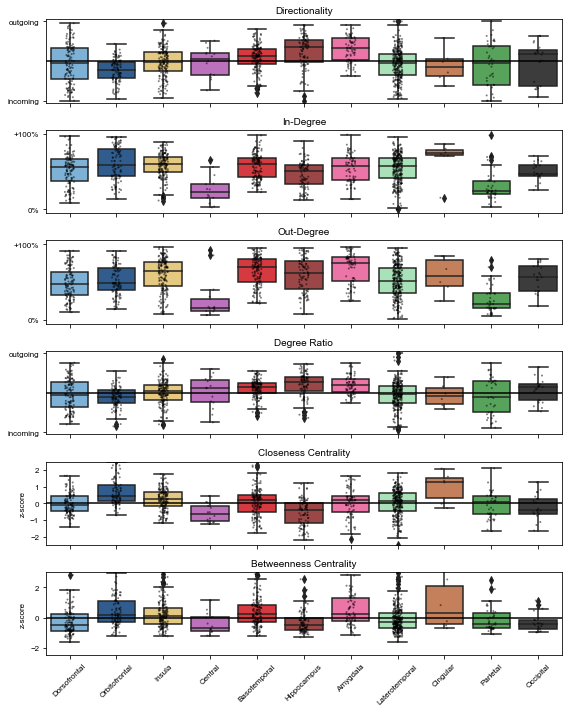

In [315]:
# Combine all metrics and labels into a single list for easier management
metrics = ['DI', 'Din_norm', 'Dout_norm', 'D_R', 'Cc_zscore', 'Cb_zscore']
metric_labels = ['Directionality', 'In-Degree', 'Out-Degree', 'Degree Ratio','Closeness Centrality', 'Betweenness Centrality']
ylim_values = [(-1.05, 1.05),(-0.05, 1.05), (-0.05, 1.05),(-1.05, 1.05),  (-2.5, 2.5), (-2.5, 3)]
ytick_values = [([-1, 1], ['incoming', 'outgoing']), ([0, 1], ['0%', '+100%']), 
                ([0, 1], ['0%', '+100%']), ([-1, 1], ['incoming', 'outgoing']), (None, None), (None, None)]
y_labels = [ None,None, None, None,'z-score', 'z-score']
# Create subplots
fig, axes = plt.subplots(len(metrics), 1, figsize=(8, 10), sharex=True)
fig.patch.set_facecolor('xkcd:white')
# Loop over each metric and plot in the respective subplot
for idx, (metric, label, ylim, yticks, yl) in enumerate(zip(metrics, metric_labels, ylim_values, ytick_values,y_labels)):
    ax = axes[idx]
    sns.boxplot(x='ChanR', y=metric, data=df_plot, order=regions_all, palette=region_col, ax=ax)
    sns.stripplot(x='ChanR', y=metric, data=df_plot, order=regions_all, alpha=0.5, color='k', s=2, ax=ax)
    ax.set_ylim(ylim)
    ax.set_title(label)
    
   
    if ylim[0]<-0.5:
        ax.axhline(0, color='k')
    if yticks[0] is not None:
        ax.set_yticks(yticks[0])
        ax.set_yticklabels(yticks[1])
    
    # Only set xticks and labels on the last subplot
    if idx == len(metrics) - 1:
        ax.set_xticklabels(regions_all, rotation=45)
    else:
        ax.set_xticklabels([])

    ax.set_ylabel(yl)
    ax.set_xlabel('')

# Show the figure
plt.tight_layout()
file = os.path.join(sub_path,'EvM\Projects\EL_experiment\Analysis\Supp_figures', 'Nodes', 'graph_metrics_regions.svg')
#plt.savefig(file)

In [305]:
epi_color = ['#5b388d', '#cdb0e8', '#cdb0e8', '#ffc8b9']
epi_color = ['#5b388d',  '#ffc8b9']

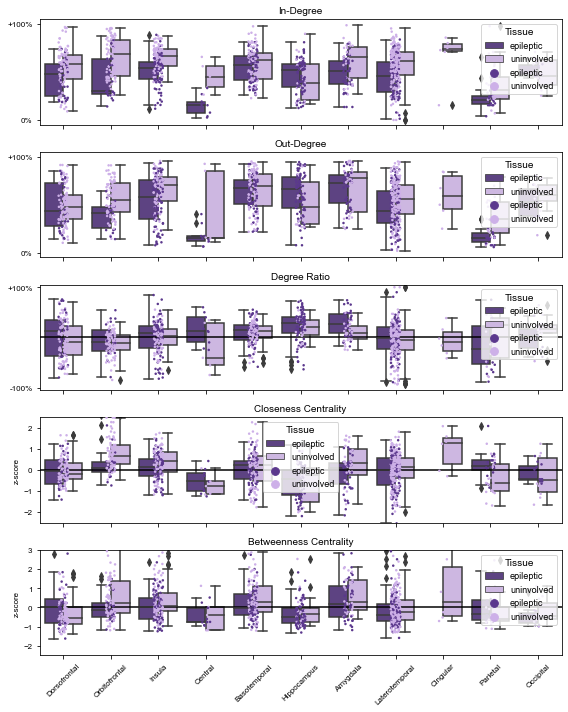

In [316]:
# Combine all metrics and labels into a single list for easier management
metrics = ['Din_norm', 'Dout_norm', 'D_R', 'Cc_zscore', 'Cb_zscore']
metric_labels = [ 'In-Degree', 'Out-Degree', 'Degree Ratio','Closeness Centrality', 'Betweenness Centrality']
ylim_values = [(-0.05, 1.05), (-0.05, 1.05),(-1.05, 1.05),  (-2.5, 2.5), (-2.5, 3)]
ytick_values = [([0, 1], ['0%', '+100%']), 
                ([0, 1], ['0%', '+100%']), ([-1, 1], ['-100%', '+100%']), (None, None), (None, None)]
y_labels = [ None, None, None,'z-score', 'z-score']
# Create subplots
fig, axes = plt.subplots(len(metrics), 1, figsize=(8, 10), sharex=True)
fig.patch.set_facecolor('xkcd:white')
hue ='Tissue'
# Loop over each metric and plot in the respective subplot
for idx, (metric, label, ylim, yticks, yl) in enumerate(zip(metrics, metric_labels, ylim_values, ytick_values,y_labels)):
    ax = axes[idx]
    sns.boxplot(x='ChanR', y=metric, data=df_plot, order=regions_all,hue = hue,hue_order = ['epileptic','uninvolved'], palette = epi_color, ax=ax)
    sns.stripplot(x='ChanR', y=metric, data=df_plot, order=regions_all,hue = hue,hue_order = ['epileptic', 'uninvolved'], palette = epi_color, ax=ax, s = 2.5)
    
    #sns.stripplot(x='ChanR', y=metric, data=df_plot, order=regions_all, alpha=0.5, color='k', s=2, ax=ax)
    ax.set_ylim(ylim)
    ax.set_title(label)
    
   
    if ylim[0]<-0.5:
        ax.axhline(0, color='k')
    if yticks[0] is not None:
        ax.set_yticks(yticks[0])
        ax.set_yticklabels(yticks[1])
    
    # Only set xticks and labels on the last subplot
    if idx == len(metrics) - 1:
        ax.set_xticklabels(regions_all, rotation=45)
    else:
        ax.set_xticklabels([])

    ax.set_ylabel(yl)
    ax.set_xlabel('')

# Show the figure
plt.tight_layout()
file = os.path.join(sub_path,'EvM\Projects\EL_experiment\Analysis\Supp_figures', 'Nodes', 'graph_metrics_regions_'+hue+'.svg')
#plt.savefig(file)

In [320]:
epi_color = ['#5b388d', '#cdb0e8', '#e85a4f','#ffc8b9']

In [322]:
regions_e = ['Hippocampus', 'Amygdala']

In [348]:
df_plot_group = df_plot.groupby(['ChanR', 'Epilepsy'], as_index=False)['Chan'].count()

In [353]:
regions_e = np.unique(df_plot_group.loc[(df_plot_group.Chan >5)&(df_plot_group.Epilepsy =='SOZ'), 'ChanR'])

In [ ]:
data_epi = df_plot[np.isin(df_plot.ChanR, regions_e)].reset_index(drop=True)


In [364]:
count_csv = sub_path+'EvM\Projects\EL_experiment\Analysis\Patients\Across\BrainMapping\General\data\\Node_anova_epi_counts.csv' 

# Create the cross-tabulation table
epilepsy_counts = pd.crosstab(df_plot['ChanR'], df_plot['Epilepsy'])
epilepsy_counts = epilepsy_counts.reindex(['SOZ', 'IED', 'Propagation', 'uninvolved'], axis="columns")
epilepsy_counts = epilepsy_counts.reindex(regions_all, axis="rows")
epilepsy_counts.to_csv(count_csv)

In [365]:
count_csv = sub_path+'EvM\Projects\EL_experiment\Analysis\Patients\Across\BrainMapping\General\data\\Node_anova_epi_counts.tex' 

# Convert to LaTeX table format
latex_table = epilepsy_counts.to_latex()

# Define the LaTeX table filepath
latex_table_filepath = '/mnt/data/epilepsy_counts.tex'

# Save the LaTeX table to a file
with open(count_csv, 'w') as file:
    file.write("\\section*{Epilepsy Counts}\n")
    file.write("\\begin{tabular}{lrrrr}\n")
    file.write("\\toprule\n")
    file.write(latex_table)
    file.write("\\bottomrule\n")
    file.write("\\end{tabular}\n")

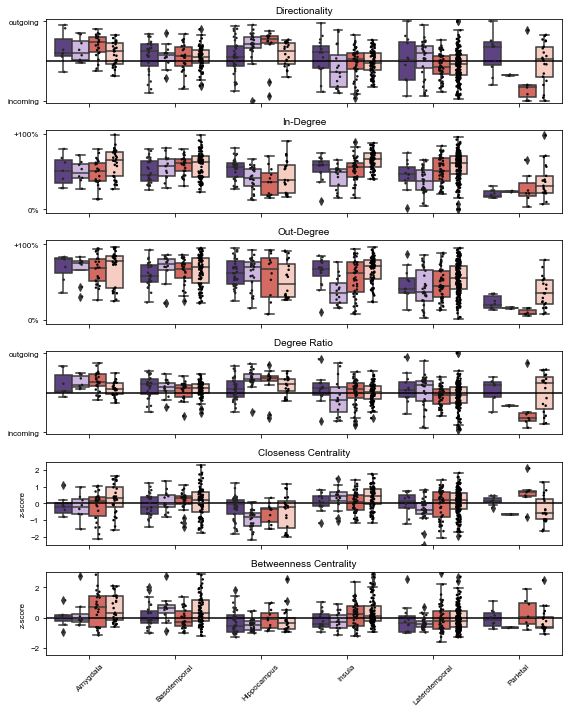

In [366]:
# Combine all metrics and labels into a single list for easier management
metrics = ['DI', 'Din_norm', 'Dout_norm', 'D_R', 'Cc_zscore', 'Cb_zscore']
metric_labels = ['Directionality', 'In-Degree', 'Out-Degree', 'Degree Ratio','Closeness Centrality', 'Betweenness Centrality']
ylim_values = [(-1.05, 1.05),(-0.05, 1.05), (-0.05, 1.05),(-1.05, 1.05),  (-2.5, 2.5), (-2.5, 3)]
ytick_values = [([-1, 1], ['incoming', 'outgoing']), ([0, 1], ['0%', '+100%']), 
                ([0, 1], ['0%', '+100%']), ([-1, 1], ['incoming', 'outgoing']), (None, None), (None, None)]
y_labels = [ None,None, None, None,'z-score', 'z-score']
# Create subplots
fig, axes = plt.subplots(len(metrics), 1, figsize=(8, 10), sharex=True)
fig.patch.set_facecolor('xkcd:white')
hue ='Epilepsy'
for idx, (metric, label, ylim, yticks, yl) in enumerate(zip(metrics, metric_labels, ylim_values, ytick_values, y_labels)):
    ax = axes[idx]
    box = sns.boxplot(x='ChanR', y=metric, data=df_plot, order=regions_e, hue=hue, hue_order=['SOZ', 'IED', 'Propagation', 'uninvolved'], palette=epi_color, ax=ax)
    sns.stripplot(x='ChanR', y=metric, data=df_plot, order=regions_e, hue=hue, color='k',hue_order=['SOZ', 'IED', 'Propagation', 'uninvolved'], dodge=True, ax=ax, s=2.5)
    
    ax.set_ylim(ylim)
    ax.set_title(label)
    
    if ylim[0] < -0.5:
        ax.axhline(0, color='k')
    if yticks[0] is not None:
        ax.set_yticks(yticks[0])
        ax.set_yticklabels(yticks[1])

    if idx == len(metrics) - 1:
        ax.set_xticklabels(regions_e, rotation=45)
    else:
        ax.set_xticklabels([])
    
    ax.set_ylabel(yl)
    ax.set_xlabel('')
    ax.legend([], [], frameon=False)

    # Calculate the number of trials for each group and add text annotations
    for patch in box.artists:
        x = patch.get_x() + patch.get_width() / 2
        y = patch.get_height()
        num_trials = len(df_plot[(df_plot['ChanR'] == regions_e[int(x)]) & (df_plot[metric] <= y)])
        ax.text(x, y + (y * 0.05), str(num_trials), ha='center')

plt.tight_layout()
file = os.path.join(sub_path,'EvM\Projects\EL_experiment\Analysis\Supp_figures', 'Nodes', 'graph_metrics_regions_'+hue+'.svg')
plt.savefig(file)
plt.show()

In [357]:
data_epi = df_plot[np.isin(df_plot.ChanR, regions_e)].reset_index(drop=True)
data_con_file = sub_path+'EvM\Projects\EL_experiment\Analysis\Patients\Across\BrainMapping\General\data\\Node_anova_epi.tex' 

# Assuming 'data_epi' is your DataFrame, and it's already been defined
# Also assuming 'metrics', 'metric_labels', and 'data_con_file' are defined

with open(data_con_file, 'w') as file:
    for metric, label in zip(metrics, metric_labels):
        # Fit the model for each metric with an interaction term between ChanR and Epilepsy
        model = ols(f'{metric} ~ C(ChanR) * C(Epilepsy)', data=data_epi).fit()

        # Perform ANOVA
        anova_results = sm.stats.anova_lm(model, typ=2)

        # Convert the ANOVA table to LaTeX
        anova_latex = anova_results.to_latex(index=True)

        # Write a section title for each metric to the LaTeX file for clarity
        file.write(f"\n\\section*{{{label}}}\n")
        file.write(anova_latex)
        file.write("\n")  # Add some space after each table for better readability


In [12]:
con_all = ls.get_connections(subjs, sub_path)
con_all_ss = ls.get_connections_sleep(subjs, sub_path, ['Wake'])

In [11]:
con_all['Con_ID'] = con_all.groupby(['Subj', 'Stim', 'Chan']).ngroup()
con_all.insert(6, 'Group', 'indirect')
con_all.loc[(con_all.d < 20) & (con_all.delay < 0.02), 'Group'] = 'local direct'
con_all.loc[(con_all.d > 20) & (con_all.delay < 0.02), 'Group'] = 'long direct'

In [12]:
con_all_DI = con_all[~np.isnan(con_all.DI)].reset_index(drop=True)

In [13]:
con_all_sel = con_all[(con_all.Num_sig_trial >10)&(con_all.True_peak == 1)].reset_index(drop=True)

In [14]:
con_all_sel = con_all[(con_all.Zscore>3)&(con_all.Num_sig_trial >10)&(con_all.True_peak == 1)].reset_index(drop=True)
data_sel = con_all_ss.merge(con_all_sel[['Subj', 'Stim', 'Chan', 'Con_ID', 'Group']], on=['Subj', 'Stim', 'Chan'])

## Across patient variability

In [223]:
con_all_sel = con_all[(con_all.Sig >0.1)&(con_all.Num_sig_trial >10)&(con_all.True_peak == 1)&(con_all.H == 0)].reset_index(drop=True)

In [239]:
# Group by 'ID', 'SR', 'CR' and calculate the mean of 'P' and count the number of rows (trials)
df_grouped = con_all_sel.groupby(['Subj', 'StimR', 'ChanR']).agg(
    P=('Sig', 'mean'),
    count=('Sig', 'size')).reset_index()


In [240]:
from itertools import combinations
# Create a DataFrame to store the pair results
pairs_df = pd.DataFrame(columns=['Subj', 'Pair', 'P', 'count', 'dir'])

# Get unique categories in SR and CR assuming they are the same
categories = df_grouped['StimR'].unique()

# Generate all pairs of categories
from itertools import permutations
pairs = list(combinations(regions_all, 2))  # If SR and CR can be the same, use product(categories, repeat=2)

# For each pair, find the corresponding P values in result_df
for sr, cr in pairs:
    for subj in subjs:
        # Create the pair string
        pair = f"{sr}-{cr}"

        # Find P value where SR is the first in the pair
        p_sr = df_grouped.loc[(df_grouped['Subj'] == subj) &(df_grouped['StimR'] == sr) & (df_grouped['ChanR'] == cr), 'P'].mean()
        count = df_grouped.loc[(df_grouped['Subj'] == subj)&(df_grouped['StimR'] == sr) & (df_grouped['ChanR'] == cr), 'count'].mean()
        print
        # Append to the pairs_df
        pairs_df = pairs_df.append({'Subj':subj, 'Pair': pair, 'P': p_sr, 'count': count, 'dir': 'AB'}, ignore_index=True)
        
        # Find P value where CR is the first in the pair (SR is the second)
        p_cr = df_grouped.loc[(df_grouped['Subj'] == subj)&(df_grouped['StimR'] == cr) & (df_grouped['ChanR'] == sr), 'P'].mean()
        count = df_grouped.loc[(df_grouped['Subj'] == subj)&(df_grouped['StimR'] == cr) & (df_grouped['ChanR'] == sr), 'count'].mean()
        pairs_df = pairs_df.append({'Subj':subj, 'Pair': pair, 'P': p_cr, 'count': count, 'dir': 'BA'}, ignore_index=True)
        
        # Append to the pairs_df
        # pairs_df = pairs_df.append({'Subj':subj, 'Pair': pair, 'P_SR': p_sr, 'P_CR': p_cr, 'count': count}, ignore_index=True)
for sr in regions_all:
    for subj in subjs:
        # Find P value where SR is the first in the pair
        p_sr = df_grouped.loc[(df_grouped['Subj'] == subj) &(df_grouped['StimR'] == sr) & (df_grouped['ChanR'] == sr), 'P'].mean()
        count = df_grouped.loc[(df_grouped['Subj'] == subj)&(df_grouped['StimR'] == sr) & (df_grouped['ChanR'] == sr), 'count'].mean()
        print
        # Append to the pairs_df
        pairs_df = pairs_df.append({'Subj':subj, 'Pair': sr, 'P': p_sr, 'count': count, 'dir': 'AB'}, ignore_index=True)
        
        
# Clean NaN values if any pair was not found in result_df
pairs_df.dropna(inplace=True)


In [241]:
pairs_grouped =pairs_df.groupby(['Pair']).agg(
    count=('Subj', 'size')).reset_index()

label_high = np.unique(pairs_grouped.loc[pairs_grouped['count']>15, 'Pair'])
label_high

array(['Amygdala-Laterotemporal', 'Basotemporal-Amygdala',
       'Basotemporal-Hippocampus', 'Basotemporal-Laterotemporal',
       'Dorsofrontal-Amygdala', 'Dorsofrontal-Basotemporal',
       'Dorsofrontal-Hippocampus', 'Dorsofrontal-Insula',
       'Dorsofrontal-Laterotemporal', 'Dorsofrontal-Orbitofrontal',
       'Hippocampus-Amygdala', 'Hippocampus-Laterotemporal',
       'Insula-Amygdala', 'Insula-Basotemporal', 'Insula-Hippocampus',
       'Insula-Laterotemporal', 'Orbitofrontal-Amygdala',
       'Orbitofrontal-Basotemporal', 'Orbitofrontal-Hippocampus',
       'Orbitofrontal-Insula', 'Orbitofrontal-Laterotemporal'],
      dtype=object)

In [242]:

PROPS = {
    'boxprops':{'facecolor':'none', 'edgecolor':'k'},
    'medianprops':{'color':'k'},
    'whiskerprops':{'color':'k'},
    'capprops':{'color':'k'}
}

TypeError: unsupported operand type(s) for ** or pow(): 'str' and 'int'

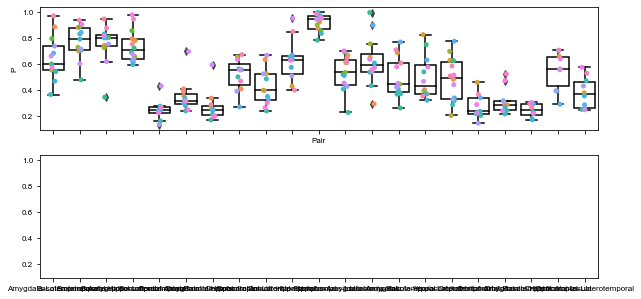

In [244]:


# Assuming pairs_df, label_high, etc. are defined

fig, axs = plt.subplots(2, 1, figsize=(10, 5), sharey=True, sharex=True)

ax_AB = axs[0]
ax_BA = axs[1]

# Plotting for ax_AB
df_pair_plot = pairs_df[np.isin(pairs_df['Pair'], label_high) & (pairs_df['dir'] == 'AB')].reset_index(drop=True)

sns.stripplot(x='Pair', y='P', data=df_pair_plot, ax=ax_AB, hue='Subj', hue_order=subjs, order=label_high)
sns.boxplot(x='Pair', y='P', data=df_pair_plot, ax=ax_AB, order=label_high, **PROPS)
ax_AB.legend([],[], frameon=False)  # Remove legend by setting an empty legend
#ax_AB.set_xticks([])

# Plotting for ax_BA
df_pair_plot = pairs_df[np.isin(pairs_df['Pair'], label_high) & (pairs_df['dir'] == 'BA')].reset_index(drop=True)
stripplot_BA = sns.stripplot(x='Pair', y='P', data=df_pair_plot, ax=ax_BA, hue='Subj', s='count',hue_order=subjs, order=label_high)
boxplot_BA = sns.boxplot(x='Pair', y='P', data=df_pair_plot, ax=ax_BA, order=label_high, **PROPS)

# Only show legend for ax_AB and place it outside
handles, labels = ax_AB.get_legend_handles_labels()
ax_BA.legend(handles=handles, labels=labels, loc='upper left', bbox_to_anchor=(1, 1))

# Rotate x-axis tick labels for ax_BA
labels = ax_BA.get_xticklabels()  # Get x labels
ax_BA.set_xticklabels(labels, rotation=45, ha='right')  # Set x labels with rotation
plt.ylim([0,1.1])
plt.tight_layout()  # Adjust layout to not overlap
file = 'X:\\4 e-Lab\EvM\Projects\EL_experiment\Analysis\Supp_figures\Flow\\P_inter_patients.svg'
plt.savefig(file)
plt.show()


## CCEP Probability & DI by distance

In [15]:
con_all_sel = con_all[(con_all.Zscore>3)&(con_all.Num_sig_trial >10)&(con_all.True_peak == 1)].reset_index(drop=True)
data_sel = con_all_ss.merge(con_all_sel[['Subj', 'Stim', 'Chan', 'Con_ID', 'Group']], on=['Subj', 'Stim', 'Chan'])
data_sel['DI_abs'] = abs(data_sel.DI)

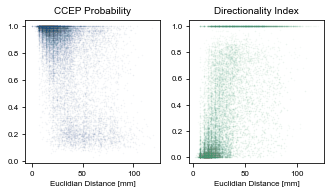

In [16]:
data_sel['DI_abs'] = abs(data_sel.DI)
y_metric_all = ['Sig', 'DI_abs', 'Mean_LL', 'Mean_P2P']
y_metric_all = ['CCEP Probability', 'Directionality Index', 'LL of mean signal', 'P2P of mean signal']
fig, axs = plt.subplots(1, 2, figsize=(4.7, 2.8))  # Creates a 2x2 grid of subplots
axs = axs.flatten()  # Flattens the 2D array of axes for easy iteration

for i, (y_value, y_title) in enumerate(zip(['Sig', 'DI_abs'], ['CCEP Probability', 'Directionality Index'])):
    sns.scatterplot(x='d', y=y_value, data=data_sel, alpha=0.05, s=2, ax=axs[i], color= color_elab[i*2])
    axs[i].set_title(y_title, fontsize = 10)
    
    if y_value == 'Mean_LL':
        axs[i].set_ylabel('$\\mu V/ms$', fontsize = 8)  # Using LaTeX formatting for mu
    elif y_value == 'Mean_P2P':
        axs[i].set_ylabel('$\\Delta V$', fontsize = 8)  # Using LaTeX formatting for delta
    else:
        axs[i].set_ylabel('')

    axs[i].set_xlabel('Euclidian Distance [mm]', fontsize = 8)
# plt.suptitle('Connection Quanticification across Euclidian Distance', fontsize = 12)
plt.tight_layout()
filename = 'X:\\4 e-Lab\EvM\Projects\EL_experiment\Analysis\Supp_figures\Flow\\P_DI_distance'
file = filename+'.png'
fig.savefig(file,dpi = 600, format='png')
plt.show()

# CONNECTION - LEVEL

## DI, P scatter

In [370]:
df = con_all_ss.copy()
all_pairs = pd.concat([df[['Subj', 'Stim', 'Chan', 'Sig','d']],
                       df.rename(columns={'Stim': 'Chan', 'Chan': 'Stim'})[['Subj', 'Chan', 'Stim', 'Sig','d']]]).reset_index(
    drop=True)
grouped = all_pairs.groupby(['Subj','Stim', 'Chan','d'], as_index=False)['Sig'].agg(['max', 'min', 'sum']).reset_index()
all_pairs = all_pairs.merge(grouped, on=['Subj','Stim', 'Chan'])
all_pairs['is_min'] = (all_pairs['Sig'] == all_pairs['min']) & (all_pairs['Sig'] != all_pairs['max'])
all_pairs['DI'] = np.where((all_pairs['min'] == 0) & (all_pairs['max'] == 0), np.nan,
                                   np.where(all_pairs['min'] == all_pairs['max'], 0,
                                            (1 - all_pairs['min'] / all_pairs['max'])))
all_pairs = all_pairs[(all_pairs['sum'] > all_pairs.Sig)]
all_pairs = all_pairs[~np.isnan(all_pairs.DI)].reset_index(drop=True)
all_pairs['Sig_2'] = np.where((all_pairs['min'] == all_pairs['Sig'] ), all_pairs['max'],all_pairs['min'])
all_pairs.loc[all_pairs.Sig<=0, 'Sig'] = -0.1 +np.random.random(len(all_pairs.loc[all_pairs.Sig<=0, 'Sig'] ))/20

In [26]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [371]:
data_con_file = sub_path+'EvM\Projects\EL_experiment\Analysis\Patients\Across\BrainMapping\General\data\DI_OLS_results.tex' 
formula = 'DI ~ C(StimR):C(ChanR) + d + delay'
model = sm.OLS.from_formula(formula, data=data_stats, groups=data_stats['Subj']).fit()
# Convert the summary to LaTeX format
model_summary_latex = model.summary().as_latex()

# Save the LaTeX code to a file
with open(data_con_file, 'w') as f:
    f.write(model_summary_latex)

NameError: name 'data_stats' is not defined

In [ ]:
'X:\\4 e-Lab\EvM\Projects\EL_experiment\Analysis\Supp_figures\Flow\\P_DI_group'

In [376]:
data_con_file = 'X:\\4 e-Lab\EvM\Projects\EL_experiment\Analysis\Supp_figures\Flow\\Connection_anova.tex' 
metrics = ['Sig', 'DI']
metric_labels = ['CCEP Probability', 'Connection Directionality']
# Assuming 'data_epi' is your DataFrame, and it's already been defined
# Also assuming 'metrics', 'metric_labels', and 'data_con_file' are defined

with open(data_con_file, 'w') as file:
    for metric, label in zip(metrics, metric_labels):
        # Fit the model for each metric with an interaction term between ChanR and Epilepsy
        model = ols(f'{metric} ~ C(StimR)*C(ChanR) ', data=data_stats).fit()


        # Perform ANOVA
        anova_results = sm.stats.anova_lm(model, typ=2)

        # Convert the ANOVA table to LaTeX
        anova_latex = anova_results.to_latex(index=True)

        # Write a section title for each metric to the LaTeX file for clarity
        file.write(f"\n\\section*{{{label}}}\n")
        file.write(anova_latex)
        file.write("\n")  # Add some space after each table for better readability

C:\Users\i0328442\AppData\Local\Programs\Python\Python37\lib\site-packages\statsmodels\base\model.py:1873: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 10, but rank is 1
  'rank is %d' % (J, J_), ValueWarning)
C:\Users\i0328442\AppData\Local\Programs\Python\Python37\lib\site-packages\statsmodels\base\model.py:1873: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 10, but rank is 1
  'rank is %d' % (J, J_), ValueWarning)
C:\Users\i0328442\AppData\Local\Programs\Python\Python37\lib\site-packages\statsmodels\base\model.py:1873: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 100, but rank is 91
  'rank is %d' % (J, J_), ValueWarning)
C:\Users\i0328442\AppData\Local\Programs\Python\Python37\lib\site-packages\statsmodels\base\model.py:1873: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 10, but rank is 1
  

NameError: name 'aaaa' is not defined

In [132]:
data_con_file = sub_path+'EvM\Projects\EL_experiment\Analysis\Patients\Across\BrainMapping\General\data\P_OLS_results.tex' 
formula = 'Sig ~ C(StimR):C(ChanR) + d + delay'
model = sm.OLS.from_formula(formula, data=data_stats, groups=data_stats['Subj']).fit()
# Convert the summary to LaTeX format
model_summary_latex = model.summary().as_latex()

# Save the LaTeX code to a file
with open(data_con_file, 'w') as f:
    f.write(model_summary_latex)

C:\Users\i0328442\AppData\Local\Programs\Python\Python37\lib\site-packages\statsmodels\base\model.py:127: ValueWarning: unknown kwargs ['groups']
  warnings.warn(msg, ValueWarning)


In [372]:
data_stats = data_sel[np.isin(data_sel.StimR, regions_all)&np.isin(data_sel.ChanR, regions_all)&(data_sel.DI>=-1)&(data_sel.Sig>0)]
formula = 'Sig ~ C(StimR):C(ChanR) + d + delay'
model = sm.OLS.from_formula(formula, data=data_stats, groups=data_stats['Subj']).fit()
# print(model.summary())

C:\Users\i0328442\AppData\Local\Programs\Python\Python37\lib\site-packages\statsmodels\base\model.py:127: ValueWarning: unknown kwargs ['groups']
  warnings.warn(msg, ValueWarning)


In [49]:
c_P = color_elab[0]
c_DI = color_elab[2]

In [203]:
import matplotlib.cm as cm

In [82]:
for group in ['local direct', 'long direct', 'indirect']:
    val  = data_sel.loc[~np.isnan(data_sel.DI)&(data_sel.Group==group), 'DI_abs'].values
    print(f"{np.quantile(val, 0.5):.2f} [{np.quantile(val, 0.25):.2f},{np.quantile(val, 0.75):.2f}]")
    print(len(val))

0.04 [0.00,0.20]
9844
0.51 [0.20,1.00]
19893
0.74 [0.40,1.00]
12423


In [84]:
for group in ['local direct', 'long direct', 'indirect']:
    val  = data_sel.loc[(data_sel.Group==group), 'Sig'].values
    print(f"{np.quantile(val, 0.5):.2f} [{np.quantile(val, 0.25):.2f},{np.quantile(val, 0.75):.2f}]")
    print(len(val))

0.99 [0.91,1.00]
10342
0.57 [0.28,0.90]
21010
0.29 [0.20,0.46]
12978


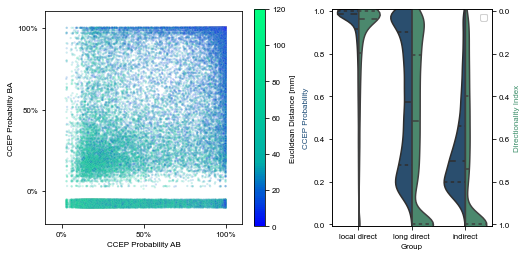

In [52]:
filename = 'X:\\4 e-Lab\EvM\Projects\EL_experiment\Analysis\Supp_figures\Flow\\P_DI_group'
fig, axes = plt.subplots(1, 2, figsize=(8, 4), gridspec_kw={'width_ratios': [2, 1.3]})

axes[0].set_ylabel("CCEP Probability BA")
axes[0].set_xlabel("CCEP Probability AB")

# Set y-ticks using the correct methods
# Set aspect, limits, and ticks
axes[0].set_box_aspect(1.08)
axes[0].set_xlim([-0.1, 1.1])
axes[0].set_ylim([-0.2, 1.1])

axes[0].set_yticks([0, 0.5, 1])
axes[0].set_yticklabels(['0%', '50%', '100%'])
axes[0].set_xticks([0, 0.5, 1])
axes[0].set_xticklabels(['0%', '50%', '100%'])

norm = plt.Normalize(vmin=0, vmax=120)
sm = cm.ScalarMappable(cmap=ListedColormap(color_d), norm=norm)
sm.set_array([])
# Add the colorbar to the figure, not to the non-existent axes[1]
cbar = plt.colorbar(sm, ax=axes[0], orientation='vertical')
cbar.set_label('Euclidean Distance [mm]')
# axes[0].set_position([0, 0, 0.6, 1])
# 
# # Manually adjust the position of the colorbar to bring it closer to the scatter plot
# axes[1].set_position([0.45,0,0.05, 1])

## VIOLIN PLOt
ax1 = axes[-1]
ax2 = ax1.twinx()
sns.violinplot(x='Group', y = 'Sig', data = data_sel, hue=True,
    hue_order=[True, False], split=True, ax=ax1, inner="quart", palette=[c_P, 'white'], legend=False)
sns.violinplot(x='Group', y = 'DI_abs', data = data_sel, hue=True,
    hue_order=[False, True], split=True, ax=ax2, inner="quart", color=c_DI, legend=False)
ax2.invert_yaxis()
ax1.legend([])
ax1.set_ylim([-0.01,1.01])
ax2.legend([])
ax2.set_ylim([1.01,-0.01])
# Set y-axis labels and titles
ax1.set_ylabel("CCEP Probability", color=c_P)
ax2.set_ylabel("Directionality Index", color=c_DI)
# ax1.set_position([0.6, 0, 0.4,axes[1].get_position().height])

# # Save the figure without scatster points as SVG
# plt.tight_layout()
file = filename+'.svg'
fig.savefig(file, format='svg')
# 
# Now add the scatter points and save as PNG
sns.scatterplot(x='Sig_2', y='Sig', data=all_pairs, hue='d_x', alpha=0.1, ax=axes[0], s=5, palette=ListedColormap(color_d), legend=False)

file = filename+'.png'
fig.savefig(file,dpi = 300, format='png')
# 
# # Show the plot if desired
plt.show()

### Brain regions

In [17]:
con_all_sel

,Stim,Chan,LL,LL_sig,d,Sig,Group,t_WOI,DI,delay,...,StimR,ChanR,StimSR,ChanSR,Stim_Epilepsy,Chan_Epilepsy,tract_num,tract_dist,Subj,Con_ID
0,0,2,8.664564,8.664564,7.00,1.000000,local direct,0.0,0.000000,0.016,...,Hippocampus,Basotemporal,Hipp,OTS,SOZ,SOZ,NaN,NaN,EL010,0
1,0,52,5.736702,5.449689,16.58,0.949153,local direct,0.0,-0.050847,0.000,...,Hippocampus,Basotemporal,Hipp,OTS,SOZ,SOZ,NaN,NaN,EL010,30
2,0,53,5.176799,4.891201,17.92,0.965517,local direct,0.0,-0.034483,0.000,...,Hippocampus,Hippocampus,Hipp,Hipp,SOZ,SOZ,NaN,NaN,EL010,31
3,0,54,3.943533,3.943533,19.79,1.000000,local direct,0.0,0.000000,0.000,...,Hippocampus,Hippocampus,Hipp,Hipp,SOZ,SOZ,NaN,NaN,EL010,32
4,0,62,6.486982,5.585509,17.92,0.819672,local direct,0.0,NaN,0.000,...,Hippocampus,Basotemporal,Hipp,OTS,SOZ,SOZ,NaN,NaN,EL010,38
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19350,89,65,4.182297,4.068396,14.39,0.973422,local direct,0.0,0.205103,0.000,...,Amygdala,Basotemporal,Amy,CollatS,uninvolved,uninvolved,NaN,NaN,EL028,83563
19351,89,66,4.472910,4.376337,16.26,0.983333,local direct,0.0,0.169769,0.000,...,Amygdala,Basotemporal,Amy,CollatS,uninvolved,uninvolved,NaN,NaN,EL028,83564
19352,89,67,3.616344,3.464993,18.61,0.956954,local direct,0.0,0.040953,0.000,...,Amygdala,Laterotemporal,Amy,STS,uninvolved,uninvolved,NaN,NaN,EL028,83565
19353,89,70,5.814767,5.805137,27.18,0.996700,long direct,0.0,0.155106,0.000,...,Amygdala,Laterotemporal,Amy,MTG,uninvolved,Propagation,NaN,NaN,EL028,83568


In [81]:
#con_all_sel = con_all[(con_all.Zscore>3)&(con_all.Num_sig_trial >10)&(con_all.True_peak == 1)].reset_index(drop=True)
#con_all_sel = con_all[(con_all.d>20)].reset_index(drop=True)
data_sel = con_all_ss.merge(con_all_sel[['Subj', 'Stim', 'Chan', 'Con_ID', 'Group']], on=['Subj', 'Stim', 'Chan'])

In [82]:
# 1. Group data and calculate median and IQR
grouped_data = data_Con_prob.groupby(['StimR', 'ChanR'])[metric].agg(['median', lambda x: np.percentile(x, 25),lambda x: np.percentile(x, 75)])
grouped_data.columns = ['median', 'IQR25', 'IQR75']

# 2. Create a Data Matrix
data_matrix = pd.DataFrame(index=regions_all, columns=regions_all)
for (stim, chan), values in grouped_data.iterrows():
    if stim in regions_all and chan in regions_all:
        data_matrix.at[stim, chan] = f"{values['median']:.2f} \n [{values['IQR25']:.1f}, \n{values['IQR75']:.1f}]"

# Reorder data matrix and annotation matrix
reordered_data = grouped_data['median'].unstack().reindex(index=regions_all, columns=regions_all)
annot_matrix = data_matrix.reindex(index=regions_all, columns=regions_all)

# 3. Plot the Heatmap with ordered x-ticks and colorbar limit
fig = plt.figure(figsize=(8,5))
fig.patch.set_facecolor('xkcd:white')
ax = sns.heatmap(reordered_data, annot=annot_matrix, annot_kws={"fontsize": 8}, fmt='', cmap=cmap_metric, cbar=True, vmin=vmin, vmax=1)

# Ensuring the heatmap is square
ax.set_aspect('equal', 'box')

KeyError: 'Column not found: Cb_zscore'

In [88]:
con_all_sel = con_all[~np.isnan(con_all.DI)& (con_all.d>20)].reset_index(drop=True)
data_sel = con_all_ss.merge(con_all_sel[['Subj', 'Stim', 'Chan', 'Con_ID', 'Group']], on=['Subj', 'Stim', 'Chan'])

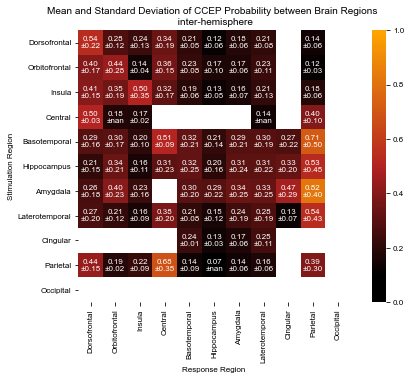

In [86]:
h = 1
metric = 'Sig'

cal = 'mean'
if metric == 'DI':
    metric_label = 'Directionality Index'
    cmap_metric = 'PRGn'
    vmin = -1
    con_all_sel = con_all[~np.isnan(con_all.DI)& (con_all.d>20)].reset_index(drop=True)
    data_sel = con_all_ss.merge(con_all_sel[['Subj', 'Stim', 'Chan', 'Con_ID', 'Group']], on=['Subj', 'Stim', 'Chan'])

else:
    # metric = 'Sig'
    metric_label = 'CCEP Probability'
    cmap_metric = 'RdGy_r'
    vmin = 0
    # Define color values and corresponding colors
    cvals  = [0, 0.1, 0.5, 1]
    colors = ["black","black", "firebrick", "orange"]

    # Normalize the color values to be between 0 and 1
    norm = matplotlib.colors.Normalize(min(cvals), max(cvals))
    norm_cvals = [norm(val) for val in cvals]

    # Create tuples of normalized values and colors
    tuples = list(zip(norm_cvals, colors))

    # Create the colormap
    cmap_metric = matplotlib.colors.LinearSegmentedColormap.from_list("", tuples)


    con_all_sel = con_all[(con_all.Sig>0.005)&(con_all.d>20)].reset_index(drop=True)
    data_sel = con_all_ss.merge(con_all_sel[['Subj', 'Stim', 'Chan', 'Con_ID', 'Group']], on=['Subj', 'Stim', 'Chan'])


data_Con_prob = data_sel[['Subj','Con_ID', 'StimR', 'ChanR', 'DI', 'Sig', 'd', 'H']].reset_index(drop=True)
data_Con_prob = data_Con_prob[ (data_Con_prob.H == h) & (np.isin(data_Con_prob.StimR, regions_all)) & (np.isin(data_Con_prob.ChanR, regions_all))].reset_index(drop=True)
data_Con_prob = data_Con_prob[~np.isnan(data_Con_prob[metric])]
grouped_data = data_Con_prob.groupby(['StimR', 'ChanR'])[metric].agg([cal, 'std'])

# 2. Create a Data Matrix
data_matrix = pd.DataFrame(index=regions_all, columns=regions_all)
for (stim, chan), values in grouped_data.iterrows():
    if stim in regions_all and chan in regions_all:
        data_matrix.at[stim, chan] = f"{values[cal]:.2f}\n±{values['std']:.2f}"

# Reorder data matrix and annotation matrix
reordered_data = grouped_data[cal].unstack().reindex(index=regions_all, columns=regions_all)
annot_matrix = data_matrix.reindex(index=regions_all, columns=regions_all)

# 3. Plot the Heatmap with ordered x-ticks and colorbar limit
fig = plt.figure(figsize=(8, 5))
fig.patch.set_facecolor('xkcd:white')
ax = sns.heatmap(reordered_data, annot=annot_matrix,annot_kws={"fontsize":8}, fmt='', cmap=cmap_metric, cbar=True, vmin =vmin, vmax=1)

# Ensuring the heatmap is square
ax.set_aspect('equal', 'box')
# 4. Add titles and labels
if h:
    plt.title('Mean and Standard Deviation of ' +metric_label +' between Brain Regions \n inter-hemisphere')
    file = 'X:\\4 e-Lab\EvM\Projects\EL_experiment\Analysis\Supp_figures\Flow\\'+metric+'_regions_interH.svg'
else:
    plt.title('Mean and Standard Deviation of ' +metric_label +' between Brain Regions \n intra-hemisphere')
    file = 'X:\\4 e-Lab\EvM\Projects\EL_experiment\Analysis\Supp_figures\Flow\\'+metric+'_regions_intraH.svg'
plt.xlabel('Response Region')
plt.ylabel('Stimulation Region')
plt.savefig(file)

Text(54.640625, 0.5, 'Stimulation Region')

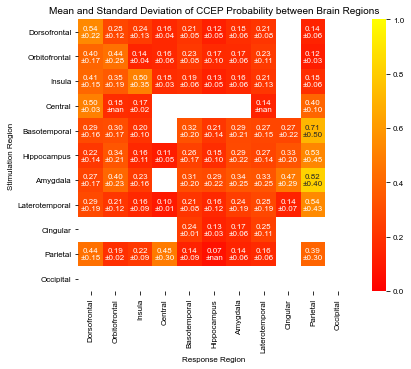

In [27]:
h = 1
metric = 'Sig'
metric_label = 'CCEP Probability'
cmap_metric = 'autumn'
data_Con_prob = data_sel[['Con_ID', 'StimR', 'ChanR', metric, 'd', 'H']].reset_index(drop=True)
data_Con_prob = data_Con_prob[(data_Con_prob.Sig>0) & (data_Con_prob.H == h) & (np.isin(data_Con_prob.StimR, regions_all)) & (np.isin(data_Con_prob.ChanR, regions_all))].reset_index(drop=True)

grouped_data = data_Con_prob.groupby(['StimR', 'ChanR'])[metric].agg(['mean', 'std'])

# 2. Create a Data Matrix
data_matrix = pd.DataFrame(index=regions_all, columns=regions_all)
for (stim, chan), values in grouped_data.iterrows():
    if stim in regions_all and chan in regions_all:
        data_matrix.at[stim, chan] = f"{values['mean']:.2f}\n±{values['std']:.2f}"

# Reorder data matrix and annotation matrix
reordered_data = grouped_data['mean'].unstack().reindex(index=regions_all, columns=regions_all)
annot_matrix = data_matrix.reindex(index=regions_all, columns=regions_all)

# 3. Plot the Heatmap with ordered x-ticks and colorbar limit
fig = plt.figure(figsize=(8, 5))
fig.patch.set_facecolor('xkcd:white')
ax = sns.heatmap(reordered_data, annot=annot_matrix,annot_kws={"fontsize":8}, fmt='', cmap=cmap_metric, cbar=True, vmin = 0, vmax=1)

# Ensuring the heatmap is square
ax.set_aspect('equal', 'box')
# 4. Add titles and labels
plt.title('Mean and Standard Deviation of ' +metric_label +' between Brain Regions')
plt.xlabel('Response Region')
plt.ylabel('Stimulation Region')

In [ ]:
np.random.seed(0)

# Generate an example time series of 10 signals, each 3600 seconds long
# Base signal: random noise
time_series = np.random.rand(10, 3600)

# Introduce high similarities between some channels over specific intervals
# Channels 0 and 1 will be similar for the first 600 seconds
time_series[1, :600] = time_series[0, :600] * 0.9 + np.random.rand(600) * 0.1

# Channels 2 and 3 will be similar between 1000 and 1600 seconds
time_series[3, 1000:1600] = time_series[2, 1000:1600] * 0.8 + np.random.rand(600) * 0.2

# Channels 4 and 5 will have a strong similarity in the last 600 seconds
time_series[5, -600:] = time_series[4, -600:] * 0.95 + np.random.rand(600) * 0.05


In [ ]:
from scipy.stats import pearsonr
corr_matrix_3d = compute_3d_correlation_matrix(time_series, win=3, Fs=1, overlap =0.5)


In [ ]:
plot_vectorized_correlation(corr_matrix_3d)


In [ ]:
def compute_3d_correlation_matrix(signal, win, Fs, overlap):
    """
    Compute the 3D correlation matrix for each pair of signals within each overlapping window.
    
    Parameters:
    - signal: Input time series data as a 2D array (n_signals x time_points).
    - win: Window size in seconds.
    - Fs: Sampling frequency in Hz.
    - overlap: overlap percentage basde on window size. 1 = full step, 0.5 =  50% overlap 
    Returns:
    - 3D correlation matrix (n_signals x n_signals x n_windows).
    """
    n_signals, n_time_points = signal.shape
    step_size = int(overlap * win * Fs)  # Convert step size to number of data points
    n_windows = int(np.floor((n_time_points - win * Fs) / step_size) + 1)

    correlation_matrix = np.zeros((n_signals, n_signals, n_windows))
    
    for window_start in range(0, n_time_points - win * Fs + 1, step_size):
        window_end = window_start + win * Fs
        for i in range(n_signals):
            for j in range(i, n_signals):
                corr, _ = pearsonr(signal[i, window_start:window_end], signal[j, window_start:window_end])
                correlation_matrix[i, j, window_start // step_size] = corr
                if i != j:
                    correlation_matrix[j, i, window_start // step_size] = corr  # Symmetric matrix
                
    return correlation_matrix

def plot_vectorized_correlation(correlation_matrix):
    """
    Vectorize the 3D correlation matrix and plot the 2D correlation across time.
    
    Parameters:
    - correlation_matrix: 3D array (n_signals x n_signals x n_windows) from compute_3d_correlation_matrix.
    """
    n_signals, _, n_windows = correlation_matrix.shape
    vectorized_matrix = correlation_matrix.reshape(n_signals**2, n_windows)
    
    plt.figure(figsize=(10, 6))
    plt.imshow(vectorized_matrix, aspect='auto', origin='lower', extent=[0, n_windows, 0, n_signals**2])
    plt.colorbar(label='Pearson Correlation')
    plt.xlabel('Time (window index)')
    plt.ylabel('Signal Pair Index')
    plt.title('Vectorized Correlation Across Time')
    plt.show()

In [ ]:
def correlation_timeseries(signal, win = 1, Fs = 500):

# Out- / In-Degree Ratio

In [ ]:
def plot_degree(df, con_type = 'all'):
    import matplotlib as mpl
    #get Region information from original table
    df = df.merge(data_con.groupby(['ChanC', 'Subj', 'ChanSR', 'ChanR'], as_index=False)['d'].mean(), on = 'ChanC', how = 'left')
    df = df.drop(columns = 'd')
    print('plotting colorbar')
    data_plot = df.groupby(['Subj', 'ChanR', 'ChanSR'], as_index=False)['DR'].mean()
    cmap = mpl.cm.seismic
    for area in np.unique(data_plot.ChanR):
        values_plot = data_plot.loc[data_plot.ChanR == area, 'DR'].values
        fig=plt.figure(figsize=(0.5,3))
        plt.title('Dout / Din Ratio Across Nodes in '+area)
        ax=fig.add_subplot(111)
        ax.axis([0,1,-0.5,0.5])
        norm = plt.Normalize(-0.5, 0.5)
        norm = mpl.colors.Normalize(vmin=-0.5, vmax=0.5)
        cb1 = mpl.colorbar.ColorbarBase(ax, cmap=cmap,
                                        orientation='vertical',
                                        ticks=[-0.5,0,0.5], norm=norm,
                                        )
        ax.axhline(np.percentile(values_plot, 25), color = 'k', ls = '--')
        ax.axhline(np.percentile(values_plot, 75), color = 'k', ls = '--')
        ax.axhline(np.nanmedian(values_plot), color = 'k', ls = '-')
        ax.axhspan(np.percentile(values_plot, 25), np.percentile(values_plot, 75), facecolor='papayawhip', alpha = 0.5)
        path_save ='X:\\4 e-Lab\\EvM\\Projects\\EL_experiment\\Analysis\\Patients\\Across\\BrainMapping\\General\\Nodes\\D_ratio_bar_'+area+'_'+con_type+'.svg'
        plt.savefig(path_save)
        plt.close()
    print('plotting boxplot overview')
    fig = plt.figure(figsize=(5,3))
    plt.subplots_adjust(bottom = 0.4, left= 0.1)
    ax = sns.boxplot(x='ChanR', y= 'DR', data = data_plot, order = regions_all, palette = region_col)
    plt.setp(ax.get_xticklabels(), rotation=90)
    path_save ='X:\\4 e-Lab\\EvM\\Projects\\EL_experiment\\Analysis\\Patients\\Across\\BrainMapping\\General\\Nodes\\D_ratio_box_'+con_type+'.svg'
    plt.title('Dout / Din Ratio Across Nodes ('+con_type+')')
    plt.ylim([-1,1])
    plt.yticks([-1,-0.5, 0,0.5, 1], ['receiving', '+100%', '0','+100%', 'sending'])
    plt.axhline(0, color='k', alpha = 0.7)
    plt.xlabel('')
    plt.ylabel('Degree Ratio')
    plt.savefig(path_save)
    plt.show()

In [ ]:
# add unique node numbers
data_con['StimC'] = data_con.groupby(['Subj', 'Stim']).ngroup()
for c_unique in np.unique(data_con['StimC']):
    c = data_con.loc[data_con.StimC == c_unique, 'Stim'].values[0]
    subj = data_con.loc[data_con.StimC == c_unique, 'Subj'].values[0]
    data_con.loc[(data_con.Subj == subj)&(data_con.Chan == c), 'ChanC'] = int(c_unique)
data_con['ChanC'] =data_con['ChanC'].astype('int') 

In [ ]:
# calculate in - / out degree for each node
nodes = []
Dout = []
Din = []
for c_unique in np.unique(data_con['StimC']):
    nodes.append(c_unique)
    Dout.append(len(data_con[(data_con.StimC==c_unique)&(data_con.Sig>0)]))
    Din.append(len(data_con[(data_con.ChanC==c_unique)&(data_con.Sig>0)]))
    
df = pd.DataFrame({
        'ChanC': nodes,
        'Dout': Dout,
        'Din': Din
    })
df['DR'] = ((1 - df['Din'] / df['Dout'])).where(df['Din'] < df['Dout'], (-1*(1 - df['Dout'] / df['Din'])))#df['DR']= df['Dout']/df['Din']  
plot_degree(df, con_type = 'all')

In [ ]:
con_P = con_P.groupby(['StimSR', 'ChanSR'], as_index = False)[['Sig', 'd']].mean()
data_mean = data_mean.rename(columns={"ChanSR": "ChanA", "StimSR": "StimA"}, errors="raise")
# Create a single mapping for both "StimR" and "ChanR" columns
mapping = {region: i for i, region in enumerate(pd.concat([data_mean['ChanA'], con_P['StimA']]).unique())}
# Map the region labels to integers in new columns
con_P['Stim'] = con_P['StimA'].map(mapping)
con_P['Chan'] = con_P['ChanA'].map(mapping)

## Connection Probability

In [68]:
import load_summary as ls
con_all = ls.get_connections(subjs, sub_path)
# con_all = con_all[(con_all.Num_sig_trial >10)&(con_all.True_peak == 1)].reset_index(drop=True)
con_all['Con_ID'] = con_all.groupby(['Subj', 'Stim', 'Chan']).ngroup()

In [69]:
con_all['Sig_Con'] = 0
con_all.loc[(con_all.Sig>0)&(con_all.True_peak==1), 'Sig_Con'] = 1

In [70]:
data_Con_prob = con_all[['Con_ID', 'StimR', 'ChanR', 'Sig_Con', 'd']].reset_index(drop=True)
data_Con_prob = data_Con_prob[(np.isin(data_Con_prob.StimR, regions_all))&(np.isin(data_Con_prob.ChanR, regions_all))].reset_index(drop=True)

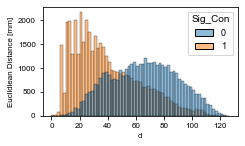

In [71]:
plt.figure(figsize=(3.5,2))
sns.histplot(x='d', hue='Sig_Con', data= data_Con_prob, multiple='layer')
plt.ylabel('Number of possible Connection')
plt.ylabel('Euclidiean Distance [mm]')
file = 'X:\\4 e-Lab\EvM\Projects\EL_experiment\Analysis\Supp_figures\CCEP\\Connection_probability_counts.svg'
# plt.savefig(file)

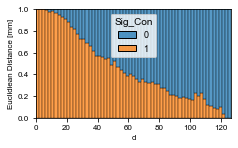

In [273]:
plt.figure(figsize=(3.5,2))
sns.histplot(x='d', hue='Sig_Con', data= data_Con_prob, multiple='fill')
plt.ylabel('Connection Probability')
plt.ylabel('Euclidiean Distance [mm]')
file = 'X:\\4 e-Lab\EvM\Projects\EL_experiment\Analysis\Supp_figures\CCEP\\Connection_probability_ratio.svg'
plt.savefig(file)

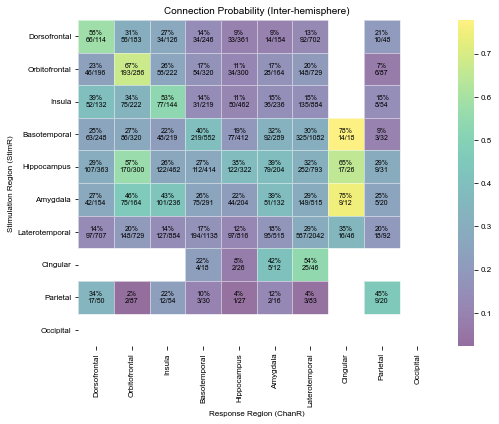

In [275]:
h = 1
data_Con_prob = con_all[['Con_ID', 'StimR', 'ChanR', 'Sig_Con', 'd', 'H']].reset_index(drop=True)
data_Con_prob = data_Con_prob[(data_Con_prob.H == h) & (np.isin(data_Con_prob.StimR, regions_all)) & (np.isin(data_Con_prob.ChanR, regions_all))].reset_index(drop=True)

# Calculate the ratio of Sig_Con == 1 to the total number of connections for each pair of regions
heatmap_data = data_Con_prob.groupby(['StimR', 'ChanR'])['Sig_Con'].mean().unstack(fill_value=np.nan)

# Create a DataFrame with NaN values for missing labels
missing_labels = list(set(regions_all) - set(heatmap_data.index))
for lab in missing_labels:
    empty_array = pd.DataFrame([[np.max(data_Con_prob.Con_ID)+1, lab, lab, np.nan, np.nan, h]], columns=['Con_ID', 'StimR', 'ChanR', 'Sig_Con', 'd', 'H'])
    data_Con_prob = pd.concat([data_Con_prob, empty_array], 0)
data_Con_prob = data_Con_prob.reset_index(drop=True)

heatmap_data = data_Con_prob.groupby(['StimR', 'ChanR'])['Sig_Con'].mean().unstack(fill_value=np.nan)
heatmap_data = heatmap_data.loc[regions_all, regions_all]  # Reorder rows and columns

# Create the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(heatmap_data, annot=False, cmap='viridis', alpha=0.57, fmt='.2f', linewidths=0.5, xticklabels=regions_all, yticklabels=regions_all)

plt.xlabel('Response Region (ChanR)')
plt.ylabel('Stimulation Region (StimR)')

# Annotate the heatmap with count values (percentage and actual ratio)
for i in range(len(regions_all)):
    for j in range(len(regions_all)):
        count_all = len(data_Con_prob[(data_Con_prob.Sig_Con>=0)&(data_Con_prob.StimR==regions_all[i])&(data_Con_prob.ChanR==regions_all[j])])
        if count_all>0:
            count = len(data_Con_prob[(data_Con_prob.Sig_Con==1)&(data_Con_prob.StimR==regions_all[i])&(data_Con_prob.ChanR==regions_all[j])])

            ratio = count/count_all
            plt.text(j + 0.5, i + 0.5, f'{ratio*100:.0f}%\n{count}/{count_all}', ha='center', va='center', fontsize=7)
if h==0:
    file = 'X:\\4 e-Lab\EvM\Projects\EL_experiment\Analysis\Supp_figures\CCEP\\Connection_probability_intraH.svg'
    plt.title('Connection Probability (Intra-hemisphere)')
else:
    file = 'X:\\4 e-Lab\EvM\Projects\EL_experiment\Analysis\Supp_figures\CCEP\\Connection_probability_interH.svg'
    plt.title('Connection Probability (Inter-hemisphere)')
#plt.savefig(file)

In [262]:
# con_all_sel = con_all[(con_all.Zscore>3)&(con_all.Num_sig_trial >10)&(con_all.True_peak == 1)].reset_index(drop=True)
con_all_sel = con_all[(con_all.d>20)].reset_index(drop=True)
data_sel = con_all_ss.merge(con_all_sel[['Subj', 'Stim', 'Chan', 'Con_ID', 'Group']], on=['Subj', 'Stim', 'Chan'])
data_sel.loc[data_sel.Sig>0.05, 'Sig'] = 1

KeyError: "['Group'] not in index"

In [ ]:
sklearn.metrics.confusion_matrix

Text(54.640625, 0.5, 'Stimulation Region')

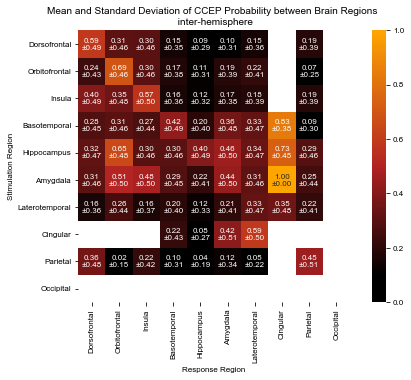

In [243]:
h = 1
metric = 'Sig'

cal = 'mean'

data_Con_prob = data_sel[['Subj','Con_ID', 'StimR', 'ChanR', 'DI', 'Sig', 'd', 'H']].reset_index(drop=True)
data_Con_prob = data_Con_prob[(data_Con_prob.H == h) & (np.isin(data_Con_prob.StimR, regions_all)) & (np.isin(data_Con_prob.ChanR, regions_all))].reset_index(drop=True)
data_Con_prob = data_Con_prob[~np.isnan(data_Con_prob[metric])]
grouped_data = data_Con_prob.groupby(['StimR', 'ChanR'])[metric].agg([cal, 'std'])

# 2. Create a Data Matrix
data_matrix = pd.DataFrame(index=regions_all, columns=regions_all)
for (stim, chan), values in grouped_data.iterrows():
    if stim in regions_all and chan in regions_all:
        data_matrix.at[stim, chan] = f"{values[cal]:.2f}\n±{values['std']:.2f}"

# Reorder data matrix and annotation matrix
reordered_data = grouped_data[cal].unstack().reindex(index=regions_all, columns=regions_all)
annot_matrix = data_matrix.reindex(index=regions_all, columns=regions_all)

# 3. Plot the Heatmap with ordered x-ticks and colorbar limit
fig = plt.figure(figsize=(8, 5))
fig.patch.set_facecolor('xkcd:white')
ax = sns.heatmap(reordered_data, annot=annot_matrix,annot_kws={"fontsize":8}, fmt='', cmap=cmap_metric, cbar=True, vmin =vmin, vmax=1)

# Ensuring the heatmap is square
ax.set_aspect('equal', 'box')
# 4. Add titles and labels
if h:
    plt.title('Mean and Standard Deviation of ' +metric_label +' between Brain Regions \n inter-hemisphere')
    file = 'X:\\4 e-Lab\EvM\Projects\EL_experiment\Analysis\Supp_figures\Flow\\'+metric+'_regions_interH.svg'
else:
    plt.title('Mean and Standard Deviation of ' +metric_label +' between Brain Regions \n intra-hemisphere')
    file = 'X:\\4 e-Lab\EvM\Projects\EL_experiment\Analysis\Supp_figures\Flow\\'+metric+'_regions_intraH.svg'
plt.xlabel('Response Region')
plt.ylabel('Stimulation Region')
#plt.savefig(file)

In [ ]:
# Region
con_P = data_con.copy()
con_P.loc[con_P.Sig>0, 'Sig'] = 1
con_P = con_P.groupby(['Subj', 'StimR', 'ChanR'], as_index = False)[['Sig', 'd']].mean()
con_P = con_P.groupby(['StimR', 'ChanR'], as_index = False)[['Sig', 'd']].mean()
# Create a single mapping for both "StimR" and "ChanR" columns
mapping = {region: i for i, region in enumerate(pd.concat([con_P['StimR'], con_P['ChanR']]).unique())}
mapping_A = {region: all_region.loc[all_region.Region == region, 'Subregion'].values[0] for i, region in enumerate(pd.concat([con_P['StimR'], con_P['ChanR']]).unique())}
# Map the region labels to integers in new columns
con_P['Stim'] = con_P['StimR'].map(mapping)
con_P['Chan'] = con_P['ChanR'].map(mapping)

con_P['StimA'] = con_P['StimR'].map(mapping_A)
con_P['ChanA'] = con_P['ChanR'].map(mapping_A)

In [ ]:
df = con_P.copy()
df.insert(0, 'Subj', 'EL010')
df['show'] = np.ones((len(df,)))
df['lw'] = df['Sig']
df['show'] = np.ones((len(df,)))

path_save ='X:\\4 e-Lab\\EvM\\Projects\\EL_experiment\\Analysis\\Patients\\Across\\BrainMapping\\General\\connection\\Connect_P_Region.svg'
plotter = ConnectogramPlotter()
os.chdir(path_connectogram)
plotter.load_data(df, path_save)
plotter.show_plot(' Connection Probability (Region)', 'area', 'r')
plt.close()
os.chdir(cwp)

In [ ]:
# Subegion
con_P = data_con.copy()
con_P.loc[con_P.Sig>0, 'Sig'] = 1
con_P = con_P.groupby(['Subj', 'StimSR', 'ChanSR'], as_index = False)[['Sig', 'd']].mean()
con_P = con_P.groupby(['StimSR', 'ChanSR'], as_index = False)[['Sig', 'd']].mean()
con_P = con_P.rename(columns={"ChanSR": "ChanA", "StimSR": "StimA"}, errors="raise")
# Create a single mapping for both "StimR" and "ChanR" columns
mapping = {region: i for i, region in enumerate(pd.concat([con_P['ChanA'], con_P['StimA']]).unique())}
# Map the region labels to integers in new columns
con_P['Stim'] = con_P['StimA'].map(mapping)
con_P['Chan'] = con_P['ChanA'].map(mapping)

In [ ]:
df = con_P.copy()
df.insert(0, 'Subj', 'EL010')
df['show'] = np.ones((len(df,)))
df['lw'] = df['Sig']
df['show'] = np.ones((len(df,)))

path_save ='X:\\4 e-Lab\\EvM\\Projects\\EL_experiment\\Analysis\\Patients\\Across\\BrainMapping\\General\\connection\\Connect_P_SubRegion.svg'
plotter = ConnectogramPlotter()
os.chdir(path_connectogram)
plotter.load_data(df, path_save)
plotter.show_plot(' Connection Probability (Subregion)', 'area', 'r')
plt.close()
os.chdir(cwp)

In [ ]:
data_con.insert(6, 'Group', 'indirect')
data_con.loc[(data_con.d < 20) & (data_con.onset < 0.02), 'Group'] = 'local direct'
data_con.loc[(data_con.d > 20) & (data_con.onset < 0.02), 'Group'] = 'long direct'

# DI & Probability CCEP

In [ ]:
df = con_all_ss[con_all_ss.SleepState=='Wake'].reset_index(drop=True)

In [ ]:
df['DI_abs'] = abs(df.DI)

In [ ]:
np.min(df.DI)

In [ ]:
def get_connections_sleep(subjs, sub_path, sss, metric):
    start = 1
    for subj in subjs:
        for ss in sss:
            path_patient_analysis = os.path.join(sub_path, 'EvM', 'Projects', 'EL_experiment', 'Analysis', 'Patients',
                                                 subj)
            summary_gen_path = path_patient_analysis + '\\BrainMapping\\CR\\data\\summ_' + ss + '_'+metric+'.csv'  # summary_general

            con_summary_all = pd.read_csv(summary_gen_path)
            con_summary_all = con_summary_all.drop_duplicates()
            con_summary_all['Subj'] = subj
            if start:
                con_sleep = con_summary_all
                start = 0
            else:
                con_sleep = pd.concat([con_sleep, con_summary_all]).reset_index(drop=True)
    return con_sleep

In [ ]:
subjs = ["EL010", "EL011","EL012","EL013", "EL014", "EL015", "EL016", "EL019", "EL020", "EL021",
         "EL022", "EL024", "EL026", "EL027", "EL028"]

In [ ]:
con_sleep_combined = get_connections_sleep(subjs, sub_path, ['Wake'], 'combined')
con_sleep_ratio = get_connections_sleep(subjs, sub_path, ['Wake'], 'ratio')
con_sleep_diff = get_connections_sleep(subjs, sub_path, ['Wake'], 'diff')

In [ ]:
con_sleep_combined = con_sleep_combined.merge(con_all[['Subj', 'Stim', 'Chan', 'Con_ID', 'Group']], on=['Subj', 'Stim', 'Chan'])
con_sleep_ratio = con_sleep_ratio.merge(con_all[['Subj', 'Stim', 'Chan', 'Con_ID', 'Group']], on=['Subj', 'Stim', 'Chan'])
con_sleep_diff = con_sleep_diff.merge(con_all[['Subj', 'Stim', 'Chan', 'Con_ID', 'Group']], on=['Subj', 'Stim', 'Chan'])

In [ ]:
con_sleep_ratio['DI_abs'] = abs(con_sleep_ratio.DI)
con_sleep_combined['DI_abs'] = abs(con_sleep_combined.DI)
con_sleep_diff['DI_abs'] = abs(con_sleep_diff.DI)

In [ ]:

sns.set_style('white')

In [ ]:
df = con_sleep_ratio[con_sleep_ratio.Sig>0.05].reset_index(drop=True)
# Create a figure with two y-axes
fig, ax1 = plt.subplots(figsize=(8, 6))
ax2 = ax1.twinx()
c_P = color_elab[0]
c_DI = color_elab[2]

sns.violinplot(x='Group', y = 'Sig', data = df, hue=True,
    hue_order=[True, False], split=True, ax=ax1, inner="quart", palette=[c_P, 'white'], legend=False)
sns.violinplot(x='Group', y = 'DI_abs', data = df, hue=True,
    hue_order=[False, True], split=True, ax=ax2, inner="quart", color=c_DI, legend=False)
ax2.invert_yaxis()
ax1.legend([])
ax2.legend([])
# Set y-axis labels and titles
ax1.set_ylabel("Sig", color=c_P)
ax2.set_ylabel("DI", color=c_DI)
plt.title('Ratio')
# path_save ='X:\\4 e-Lab\\EvM\\Projects\\EL_experiment\\Analysis\\Patients\\Across\\BrainMapping\\General\\DI\\DI_P_violin.svg'
#plt.savefig(path_save)

In [ ]:
data_stats = data_con_clean[(data_con_clean.DI>=-1)&(data_con_clean.Sig>0)]
formula = 'Sig ~ C(StimR) + C(ChanR) + d + delay'
model = sm.OLS.from_formula(formula, data=data_stats, groups=data_stats['Subj']).fit()
print(model.summary())

In [ ]:
data_stats = data_con_clean[(data_con_clean.DI>=-1)]
formula = 'DI ~ C(StimR) +d'
model = sm.OLS.from_formula(formula, data=data_stats, groups=data_stats['Subj']).fit()
print(model.summary())

In [ ]:
data_stats = data_con_clean[(data_con_clean.Sig>0)]
formula = 'DI_abs ~ C(StimR) +d +delay'
model = sm.OLS.from_formula(formula, data=data_stats, groups=data_stats['Subj']).fit()
print(model.summary())

## DI Brain-area

In [ ]:
def plot_DI(df, con_type = 'all'):
    import matplotlib as mpl
    cmap = mpl.cm.seismic
    for area in regions_all:
        values_plot = df.loc[df.StimR == area, 'DI'].values
        fig=plt.figure(figsize=(0.5,3))
        plt.title('Dout / Din Ratio Across Nodes in '+area)
        ax=fig.add_subplot(111)
        ax.axis([0,1,-1,1])
        norm = mpl.colors.Normalize(vmin=-1, vmax=1)
        cb1 = mpl.colorbar.ColorbarBase(ax, cmap=cmap,
                                        orientation='vertical',
                                        ticks=[-1,0,1], norm=norm,
                                        )
        ax.axhline(np.percentile(values_plot, 25), color = 'k', ls = '--')
        ax.axhline(np.percentile(values_plot, 75), color = 'k', ls = '--')
        ax.axhline(np.nanmedian(values_plot), color = 'k', ls = '-')
        ax.axhspan(np.percentile(values_plot, 25), np.percentile(values_plot, 75), facecolor='papayawhip', alpha = 0.5)
        path_save ='X:\\4 e-Lab\\EvM\\Projects\\EL_experiment\\Analysis\\Patients\\Across\\BrainMapping\\General\\connection\\DI_bar_'+area+'.svg'
        plt.savefig(path_save)
        plt.close()
        
        fig = plt.figure(figsize=(5,3))
        plt.title('Stim in '+area)
        plt.subplots_adjust(bottom = 0.5, left= 0.2)
        ax = sns.boxplot(x='ChanR', y = 'DI', data = df[df.StimR == area], order = regions_all, palette = region_col)
        plt.setp(ax.get_xticklabels(), rotation=90)
        path_save ='X:\\4 e-Lab\\EvM\\Projects\\EL_experiment\\Analysis\\Patients\\Across\\BrainMapping\\General\\connection\\DI_Box_'+area+'.svg'
        plt.ylim([-1,1])
        plt.xlabel('')
        plt.savefig(path_save)
        plt.close()
    
    print('plotting boxplot overview')
    fig = plt.figure(figsize=(5,3))
    plt.subplots_adjust(bottom = 0.5, left= 0.2)
    ax = sns.violinplot(x='StimR', y = 'DI', data = df, order = regions_all, palette = region_col)
    plt.setp(ax.get_xticklabels(), rotation=90)
    path_save ='X:\\4 e-Lab\\EvM\\Projects\\EL_experiment\\Analysis\\Patients\\Across\\BrainMapping\\General\\connection\\DI_violin_all.svg'
    plt.ylim([-1.5,1.5])
    plt.yticks([-1,0,1])
    plt.axhline(0, color='k', alpha = 0.7)
    plt.title('Mean DI')
    plt.xlabel('')
    plt.savefig(path_save)
    plt.show()

In [ ]:
data_plot = data_con_clean[np.isin(data_con_clean.StimR,regions_all)&(data_con_clean.d>20)].reset_index(drop=True)
# data_plot = data_mean[np.isin(data_mean.StimR,regions_all)&(data_mean.d>20)].reset_index(drop=True)
plot_DI(data_plot, con_type = 'all')

## DI Connectogram

In [18]:
data_con_clean

NameError: name 'data_con_clean' is not defined

In [ ]:
#area = 'Insula'
for subj in np.unique(data_mean.Subj):
    data_plot_all = data_con_clean[(data_con_clean.Subj == subj)&(data_con_clean.Sig > 0)].reset_index(drop=True)
    data_plot_all = data_plot_all.drop(columns = ['ChanA' , 'StimA'])
    data_plot_all = data_plot_all.rename(columns={"ChanSR": "ChanA", "StimSR": "StimA"}, errors="raise")
    data_plot_all['show'] = np.ones((len(data_plot_all,)))
    data_plot_all['lw'] = data_plot_all['Sig']
    data_plot_all['show'] = np.zeros((len(data_plot_all,)))
    data_plot_all.loc[np.isin(data_plot_all.Subj, subj), 'show'] =1
    if np.sum(data_plot_all.show)>0:
        path_save ='X:\\4 e-Lab\\EvM\\Projects\\EL_experiment\\Analysis\\Patients\\Across\\BrainMapping\\General\\connection\\All_'+subj+'.svg'
        plotter = ConnectogramPlotter()
        os.chdir(path_connectogram)
        plotter.load_data(data_plot_all, path_save)
        plotter.show_plot(subj +' -- All Connections', 'area')
        plt.close()
        os.chdir(cwp)

In [ ]:
data_plot_all = data_mean[(data_mean.d > 20)].reset_index(drop=True)
data_plot_all = data_plot_all.rename(columns={"ChanSR": "ChanA", "StimSR": "StimA"}, errors="raise")
data_plot_all['show'] = np.ones((len(data_plot_all,)))
data_plot_all['lw'] = data_plot_all['DI']
if len(data_plot_all)>0:
    path_save ='X:\\4 e-Lab\\EvM\\Projects\\EL_experiment\\Analysis\\Patients\\Across\\BrainMapping\\General\\connection\\Mean_DI_unidirectional_all.svg'
    plotter = ConnectogramPlotter()
    os.chdir(path_connectogram)
    plotter.load_data(data_plot_all, path_save)
    plotter.show_plot('All -- Unidirectional Connections (B-R)', 'area')
    plt.close()
    os.chdir(cwp)

In [ ]:
data_plot_all = data_mean[(data_mean.DI > 0.3)& (data_mean.d > 0.02)].reset_index(drop=True)
data_plot_all = data_plot_all.rename(columns={"ChanSR": "ChanA", "StimSR": "StimA"}, errors="raise")
data_plot_all['show'] = np.ones((len(data_plot_all,)))
data_plot_all['lw'] = data_plot_all['DI']
if len(data_plot_all)>0:
    path_save ='X:\\4 e-Lab\\EvM\\Projects\\EL_experiment\\Analysis\\Patients\\Across\\BrainMapping\\General\\connection\\Mean_DI_unidirectional_all.svg'
    plotter = ConnectogramPlotter()
    os.chdir(path_connectogram)
    plotter.load_data(data_plot_all, path_save)
    plotter.show_plot('All -- Unidirectional Connections (B-R)', 'area')
    plt.close()
    os.chdir(cwp)

In [ ]:
data_plot_all = data_mean[(data_mean.DI >=0.2) & (data_mean.d > 20)].reset_index(drop=True)
data_plot_all = data_plot_all.rename(columns={"ChanSR": "ChanA", "StimSR": "StimA"}, errors="raise")
data_plot_all['show'] = np.ones((len(data_plot_all,)))
data_plot_all['lw'] = data_plot_all['Sig']

In [ ]:
for area in np.unique(data_mean.StimR):
    for h in ['l', 'r']:
        data_plot_all['show'] = np.zeros((len(data_plot_all,)))
        if h == 'l':
            data_plot_all.loc[(data_plot_all.delay<0.02)&((np.isin(data_plot_all.StimR, area))|(np.isin(data_plot_all.ChanR, area))), 'show'] =1
            label = 'direct'
        else:
            data_plot_all.loc[(data_plot_all.delay>=0.02)&((np.isin(data_plot_all.StimR, area))|(np.isin(data_plot_all.ChanR, area))), 'show'] =1
            label = 'indirect'
        data_plot_all['sort'] = 0
        data_plot_all.loc[(np.isin(data_plot_all.ChanR, area)), 'sort'] =1
        data_plot_all = data_plot_all.sort_values(by=['sort']).reset_index(drop=True)
        if np.sum(data_plot_all.show)>0:
            path_save ='X:\\4 e-Lab\\EvM\\Projects\\EL_experiment\\Analysis\\Patients\\Across\\BrainMapping\\General\\connection\\Mean_DI_'+area+'_'+label+'.svg'
            plotter = ConnectogramPlotter()
            os.chdir(path_connectogram)
            plotter.load_data(data_plot_all, path_save)
            plotter.show_plot(area +' -- '+label+' Connections (B-R)', 'area')
            plt.close()
            os.chdir(cwp)

In [ ]:
subj = 'EL011'
data_plot_all = data_con_clean[(data_con_clean.Subj == subj)&(data_con_clean.Sig > 0)].reset_index(drop=True)
data_plot_all = data_plot_all.drop(columns = ['ChanA' , 'StimA'])
data_plot_all = data_plot_all.rename(columns={"ChanSR": "ChanA", "StimSR": "StimA"}, errors="raise")

chans_selected = [6,9, 40,16,44, 65] 
data_plot_all = data_con_clean[(data_con_clean.Subj == subj)&(data_con_clean.Sig > 0)].reset_index(drop=True)
data_plot_all = data_plot_all.drop(columns = ['ChanA' , 'StimA'])
data_plot_all = data_plot_all.rename(columns={"ChanSR": "ChanA", "StimSR": "StimA"}, errors="raise")
data_plot_all['show'] = np.ones((len(data_plot_all,)))
data_plot_all['lw'] = data_plot_all['Sig']
data_plot_all['show'] = np.zeros((len(data_plot_all,)))
data_plot_all.loc[(data_plot_all.Stim == 19)&np.isin(data_plot_all.Chan,chans_selected), 'show'] = 1

path_save ='X:\\4 e-Lab\\EvM\\Projects\\EL_experiment\\Analysis\\Patients\\Across\\BrainMapping\\General\\connection\\selected_'+subj+'.svg'
plotter = ConnectogramPlotter()
os.chdir(path_connectogram)
plotter.load_data(data_plot_all, path_save)
plotter.show_plot(subj +' -- Connections', 'area')
plt.close()
os.chdir(cwp)

In [ ]:
#area = 'Insula'
for subj in np.unique(data_mean.Subj):
    data_plot_all = data_con_clean[(data_con_clean.Subj == subj)&(data_con_clean.Sig > 0)].reset_index(drop=True)
    data_plot_all = data_plot_all.drop(columns = ['ChanA' , 'StimA'])
    data_plot_all = data_plot_all.rename(columns={"ChanSR": "ChanA", "StimSR": "StimA"}, errors="raise")
    data_plot_all['show'] = np.ones((len(data_plot_all,)))
    data_plot_all['lw'] = data_plot_all['Sig']
    data_plot_all['show'] = np.zeros((len(data_plot_all,)))
    data_plot_all.loc[np.isin(data_plot_all.Subj, subj), 'show'] =1
    if np.sum(data_plot_all.show)>0:
        path_save ='X:\\4 e-Lab\\EvM\\Projects\\EL_experiment\\Analysis\\Patients\\Across\\BrainMapping\\General\\connection\\All_'+subj+'.svg'
        plotter = ConnectogramPlotter()
        os.chdir(path_connectogram)
        plotter.load_data(data_plot_all, path_save)
        plotter.show_plot(subj +' -- Unidirectional Connections', 'area')
        plt.close()
        os.chdir(cwp)

In [ ]:
#area = 'Insula'
for subj in np.unique(data_mean.Subj):
    data_plot_all['show'] = np.zeros((len(data_plot_all,)))
    data_plot_all.loc[np.isin(data_plot_all.Subj, subj), 'show'] =1
    if np.sum(data_plot_all.show)>0:
        path_save ='X:\\4 e-Lab\\EvM\\Projects\\EL_experiment\\Analysis\\Patients\\Across\\BrainMapping\\General\\connection\\Mean_DI_unidirectional_'+subj+'.svg'
        plotter = ConnectogramPlotter()
        os.chdir(path_connectogram)
        plotter.load_data(data_plot_all, path_save)
        plotter.show_plot(subj +' -- Unidirectional Connections', 'area')
        plt.close()
        os.chdir(cwp)

In [ ]:
for area in np.unique(data_mean.StimR):
    data_plot_all['show'] = np.zeros((len(data_plot_all,)))
    data_plot_all.loc[(np.isin(data_plot_all.StimR, area))|(np.isin(data_plot_all.ChanR, area)), 'show'] =1
    data_plot_all['sort'] = 0
    data_plot_all.loc[(np.isin(data_plot_all.ChanR, area)), 'sort'] =1
    data_plot_all = data_plot_all.sort_values(by=['sort']).reset_index(drop=True)
    if np.sum(data_plot_all.show)>0:
        path_save ='X:\\4 e-Lab\\EvM\\Projects\\EL_experiment\\Analysis\\Patients\\Across\\BrainMapping\\General\\connection\\Mean_DI_unidirectional_'+area+'.svg'
        plotter = ConnectogramPlotter()
        os.chdir(path_connectogram)
        plotter.load_data(data_plot_all, path_save)
        plotter.show_plot(area +' -- Unidirectional Connections (B-R)', 'area')
        plt.close()
        os.chdir(cwp)

In [ ]:
data_plot = data_plot_all[(data_plot_all.Subj == subj)&(data_plot_all.DI == 1)] #data_mean[(data_mean.Subj == subj)&(data_mean.DI >0.5)]
    if len(data_plot)>0:
        path_save ='X:\\4 e-Lab\\EvM\\Projects\\EL_experiment\\Analysis\\Patients\\Across\\BrainMapping\\General\\connection\\'+subj+'_DI_unidirectional.svg'
        plotter = ConnectogramPlotter()
        os.chdir(path_connectogram)
        plotter.load_data(data_plot, path_save)
        plotter.show_plot(subj+' -- Unidirectional Connections (B-R)', 'Area')
        plt.close()
        os.chdir(cwp)

In [ ]:
## single conenctions that are uni-directional
for subj in subjs:
    data_plot = data_plot_all[(data_plot_all.Subj == subj)&(data_plot_all.DI == 1)] #data_mean[(data_mean.Subj == subj)&(data_mean.DI >0.5)]
    if len(data_plot)>0:
        path_save ='X:\\4 e-Lab\\EvM\\Projects\\EL_experiment\\Analysis\\Patients\\Across\\BrainMapping\\General\\connection\\'+subj+'_DI_unidirectional.svg'
        plotter = ConnectogramPlotter()
        os.chdir(path_connectogram)
        plotter.load_data(data_plot, path_save)
        plotter.show_plot(subj+' -- Unidirectional Connections (B-R)', 'Area')
        plt.close()
        os.chdir(cwp)

#### Information Data

In [ ]:
m = 'DI'
data_clean = data_DI.loc[(~np.isnan(data_DI.P_BA)) & (~np.isnan(data_DI.P_AB)) & (~np.isnan(data_DI[m]))]
data_clean  = data_clean.reset_index(drop=True)

In [ ]:
 color_d, color_dist, color_group, color_elab = ls.get_color(

In [ ]:
sns.scatterplot(x='P_AB', y = 'P_BA', data = data_clean, hue = 'd', palette = ListedColormap(color_d))

In [ ]:
data_con_sig = data_con[data_con.Sig>0]
data_con_sig = data_con_sig.reset_index(drop=True)
data_con_sig.groupby(['Dist'])['Sig'].count()

In [ ]:
data_con_sig

In [ ]:
xx = 'Dist'
yy = 'Sig'
ylabel = "Probability"
if yy == 'DI':
    ylabel = 'Directionality Index'
data_plot = data_con_sig[data_con_sig.Sig>0]
data_plot[yy] = abs(data_plot[yy])

sns.set_style('white')
palette = color_dist
f, ax = plt.subplots(figsize=(15,10))
ax = sns.violinplot(x=xx, y=yy, hue =xx, data=data_plot, dodge=False,
                    palette=palette,
                    scale="width", inner=None, alpha=.2)
xlim = ax.get_xlim()
ylim = ax.get_ylim()
for violin in ax.collections:
    bbox = violin.get_paths()[0].get_extents()
    x0, y0, width, height = bbox.bounds
    violin.set_clip_path(plt.Rectangle((x0, y0), width / 2, height, transform=ax.transData))
    violin.set_alpha(0.8)

sns.boxplot(x=xx, y=yy, data=data_plot, saturation=1, showfliers=False,
            width=0.3, boxprops={'zorder': 3, 'facecolor': 'none'}, ax=ax, linewidth = 3)
old_len_collections = len(ax.collections)
sns.stripplot(x=xx, y=yy, hue =xx, data=data_plot, palette=palette, dodge=False, ax=ax, alpha=0.1)
for dots in ax.collections[old_len_collections:]:
    dots.set_offsets(dots.get_offsets() + np.array([0.12, 0]))
ax.set_xlim(xlim)
ax.set_ylim(ylim)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.ylabel(ylabel, fontsize=24)
plt.xlabel("", fontsize=24)
# ax.legend_.remove()
plt.show()

#### GET patient stim information

In [ ]:
xx = 'Dist'
yy = 'DI'
ylabel = "Probability"
if yy == 'DI':
    ylabel = 'Directionality Index'
data_plot = data_con_sig# [data_con_all.Sig>0]
data_plot[yy] = abs(data_plot[yy])

sns.set_style('white')
palette = 'hot'
f, ax = plt.subplots(figsize=(15,10))
ax = sns.violinplot(x=xx, y=yy, hue =xx, data=data_plot, dodge=False,
                    palette=palette,
                    scale="width", inner=None, alpha=.2)
xlim = ax.get_xlim()
ylim = ax.get_ylim()
for violin in ax.collections:
    bbox = violin.get_paths()[0].get_extents()
    x0, y0, width, height = bbox.bounds
    violin.set_clip_path(plt.Rectangle((x0, y0), width / 2, height, transform=ax.transData))
    violin.set_alpha(0.8)

sns.boxplot(x=xx, y=yy, data=data_plot, saturation=1, showfliers=False,
            width=0.3, boxprops={'zorder': 3, 'facecolor': 'none'}, ax=ax, linewidth = 3)
old_len_collections = len(ax.collections)
sns.stripplot(x=xx, y=yy, hue =xx, data=data_plot, palette=palette, dodge=False, ax=ax, alpha=0.1)
for dots in ax.collections[old_len_collections:]:
    dots.set_offsets(dots.get_offsets() + np.array([0.12, 0]))
ax.set_xlim(xlim)
ax.set_ylim(ylim)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.ylabel(ylabel, fontsize=24)
plt.xlabel("", fontsize=24)
# ax.legend_.remove()
plt.show()

In [ ]:
Fs             = 500
dur            = np.zeros((1,2), dtype=np.int32)
t0 = 1
dur[0,0] =  -t0
dur[0,1] =  3


#dur[0,:]       = np.int32(np.sum(abs(dur)))
x_ax           = np.arange(dur[0,0],dur[0,1],(1/Fs))
color_elab      = np.zeros((4,3))
color_elab[0,:] = np.array([31, 78, 121])/255
color_elab[1,:] = np.array([189, 215, 28])/255
color_elab[2,:] = np.array([0.256, 0.574, 0.431])
color_elab[3,:] = np.array([1, 0.574, 0])

labels_region[labels_region=='HIPP'] = 'Mesiotemporal'
labels_region[labels_region=='HIPP '] = 'Mesiotemporal'
labels_region[labels_region=='ENT'] = 'Basotemporal'

## LL and Significant responses 

In [ ]:
subjs = ['EL003', 'EL004', 'EL005', 'EL008','EL009', 'EL010', 'EL011']
# only Ph
subjs = ['EL004', 'EL005', 'EL008', 'EL010', 'EL012']
# only CR
subjs = ['EL010', 'EL011', 'EL012', 'EL013', 'EL014', 'EL015', 'EL016', 'EL017', 'EL019', 'EL020', 'EL021']

In [ ]:
subjs = ['EL010', 'EL011', 'EL012', 'EL013', 'EL014', 'EL015', 'EL016', 'EL017', 'EL019', 'EL020', 'EL021', 'EL022', 'EL024', 'EL025', 'EL026']

In [ ]:
folder       = 'BrainMapping'
cond_folder = 'CR'

In [ ]:
sub_path  ='X:\\4 e-Lab\\' # y:\\eLab

### Connections AB

In [ ]:
data_con

In [ ]:
data_con_sig = data_con[~np.isnan(data_con.DI)]
data_con_sig = data_con_sig.reset_index(drop=True)
data_con_sig.groupby(['Dist'])['Sig'].count()

In [ ]:
m = 'DI'
data_plot = data_DI.loc[(~np.isnan(data_DI.P_BA)) & (~np.isnan(data_DI.P_AB)) & (~np.isnan(data_DI[m]))]
data_plot  = data_plot.reset_index(drop=True)

In [ ]:
m = 'DI'
data_plot = data_DI.loc[(~np.isnan(data_DI.P_BA)) & (~np.isnan(data_DI.P_AB)) & (~np.isnan(data_DI[m]))]
data_plot  = data_plot.reset_index(drop=True)
### DI by distance
data_plot.insert(3, 'Dist', 'local (<15 mm)')
data_plot = data_plot.reset_index(drop=True)
data_plot.loc[data_plot.d > 15, 'Dist'] = 'short (<30mm)'
data_plot.loc[data_plot.d > 30, 'Dist'] = 'long'
data_con.insert(6, 'Group', 'indirect')
data_con.loc[(data_con.d < 20) & (data_con.onset < 0.02), 'Group'] = 'local direct'
data_con.loc[(data_con.d > 20) & (data_con.onset < 0.02), 'Group'] = 'long direct'

In [ ]:
grid = sns.JointGrid(x='P_AB', y='P_BA', data=data_plot,height=15, ratio=4)

g = grid.plot_joint(sns.scatterplot, c=data_plot[c], s=50, data=data_plot, cmap=colormap_d)
# plt.pcolor(np.linspace(0, 1, 101), np.linspace(0, 1, 101),abs(M), cmap='binary', vmin=0.1, vmax=0.8, alpha=1)
g.ax_joint.set_xticks([0,0.5,1])
g.ax_joint.set_xticklabels([0,50,100],fontsize=20)
g.ax_joint.set_yticks([0,0.5,1])
g.ax_joint.set_yticklabels([0,50,100],fontsize=20)
g.ax_joint.set_ylabel('Probability BA [%]',fontsize=20)
g.ax_joint.set_xlabel('Probability AB [%]',fontsize=20)

sns.kdeplot(x='P_AB', data=data_plot[data_plot.P_BA==0], hue='Dist', hue_order=dist_labels, ax=g.ax_marg_x, legend=False, linewidth= 10, palette=color_dist)
sns.kdeplot(x='P_BA', data=data_plot[data_plot.P_AB==0], hue='Dist', hue_order=dist_labels,ax=g.ax_marg_y,  vertical=True,legend=True, linewidth= 10, palette=color_dist)
#plt.savefig(
#        sub_path + 'EvM\Projects\EL_experiment\Analysis\Patients\Across\BrainMapping\General\DI\P_scatter_'+c+'_kde.svg')

plt.show()

In [ ]:
c= 'd'
if c =='d':
    colormap_d = 'hot' #ListedColormap(color_d)
else:
    colormap_d = 'hot'
# data_plot = data_DI.loc[(~np.isnan(data_DI.P_BA)) & (~np.isnan(data_DI.P_AB)) & (~np.isnan(data_DI[m]))]
norm = plt.Normalize(data_plot[c].min(), 100)
# sm = plt.cm.ScalarMappable(cmap="RdBu", norm=norm)


data_plot.loc[data_plot.P_AB == 0, 'P_AB'] = np.random.random(len(data_plot.loc[data_plot.P_AB == 0]))/20 - 0.05
data_plot.loc[data_plot.P_BA == 0, 'P_BA'] = np.random.random(len(data_plot.loc[data_plot.P_BA == 0])) / 20 - 0.05


fig = plt.figure(figsize=(14, 10))
g = sns.scatterplot(x='P_AB', y='P_BA', c=data_plot[c], s=50, data=data_plot, cmap=colormap_d)

scalarmappaple = cm.ScalarMappable(norm=norm, cmap=colormap_d)
fig.colorbar(scalarmappaple)
plt.title('Directionality Index (' + m + ')', fontsize=25)
plt.xticks([0, 0.5, 1], ['0', '50', '100'], fontsize=20)
plt.yticks([0, 0.5, 1], ['0', '50', '100'], fontsize=20)
plt.xlabel('Probability AB [%]', fontsize=25)
plt.ylabel('Probability BA [%]', fontsize=25)

In [ ]:
m ='DI'

data_plot = data_con[(~np.isnan(data_con.P_BA))&(~np.isnan(data_con.P_AB))&(~np.isnan(data_con[m]))]
grid = sns.JointGrid(x='P_AB', y='P_BA', data=data_plot,height=15, ratio=4)
hue = 'Dist'

g = grid.plot_joint(sns.scatterplot, c=data_plot[m], data=data_plot, cmap =colormap)

g.fig.suptitle('Directionality Index ('+m+')', fontsize=25)
g.ax_joint.set_xticks([0,0.5,1])
g.ax_joint.set_xticklabels([0,50,100],fontsize=20)
g.ax_joint.set_yticks([0,0.5,1])
g.ax_joint.set_yticklabels([0,50,100],fontsize=20)
g.ax_joint.set_ylabel('Probability BA [%]',fontsize=20)
g.ax_joint.set_xlabel('Probability AB [%]',fontsize=20)

scalarmappaple = cm.ScalarMappable(norm=norm, cmap=colormap)
sns.kdeplot(data_plot.P_AB, data=data_plot, hue=hue, ax=g.ax_marg_x, legend=False, linewidth= 10)
sns.kdeplot(data_plot.P_BA, data=data_plot, hue=hue, ax=g.ax_marg_y,  vertical=True,legend=True, linewidth= 10)
#sns.kdeplot(tips.loc[tips['smoker']=='No', 'total_bill'], ax=g.ax_marg_x, legend=False)
#sns.kdeplot(tips.loc[tips['smoker']=='Yes', 'tip'], ax=g.ax_marg_y, vertical=True, legend=False)
#sns.kdeplot(tips.loc[tips['smoker']=='No', 'tip'], ax=g.ax_marg_y, vertical=True, legend=False)
#plt.savefig(sub_path+'EvM\Projects\EL_experiment\Analysis\Patients\Across\BrainMapping\General\DI\P_scatter_'+m+'_kde_Dist.svg')
#plt.savefig(sub_path+'EvM\Projects\EL_experiment\Analysis\Patients\Across\BrainMapping\General\DI\P_scatter_'+m+'_kde_Dist.jpg')
   

In [ ]:
x_order = ['local (<15 mm)', 'short (<30mm)', 'long']

In [ ]:
data_DI = data_con.drop(columns=['Dist', 'A_Area', 'A_Region', 'B_Area', 'B_Region', 'DI_r', 'DI_d'])

## Create colorcode for euclidean distance

In [ ]:
%matplotlibe inline

In [ ]:
hue_order = ['long', 'short (<30mm)', 'local (<15 mm)']

In [ ]:
A = np.arange(0,1.01,0.01)
B = np.arange(0,1.01,0.01)
M = np.zeros((101,101))
for i in range(len(A)):
    for j in range(len(A)):
        M[i,j] = (B[j]-A[i])*(1-np.min([A[i],B[j]])/np.max([A[i],B[j]]))
    

In [ ]:
colormap ='seismic'
norm = plt.Normalize(0, 1)

In [ ]:
M[0:2,:] =1
M[:,0:2] =-1


In [ ]:
plt.figure(figsize=(20,20))
plt.pcolor(abs(M), cmap='binary', vmin=0.1, vmax=0.8)
plt.axis('off')
plt.savefig(sub_path+'EvM\Projects\EL_experiment\Analysis\Patients\Across\BrainMapping\General\DI\P_binary.jpg')

plt.figure(figsize=(20,20))
plt.pcolor(M, cmap='seismic')
plt.axis('off')
plt.savefig(sub_path+'EvM\Projects\EL_experiment\Analysis\Patients\Across\BrainMapping\General\DI\P_seismic.jpg')



In [ ]:
m ='DI'

data_plot = data_con[(~np.isnan(data_con.P_BA))&(~np.isnan(data_con.P_AB))&(~np.isnan(data_con[m]))]
grid = sns.JointGrid(x='P_AB', y='P_BA', data=data_plot,height=15, ratio=4)
hue = 'Dist'

g = grid.plot_joint(sns.scatterplot, c=data_plot[m], data=data_plot, cmap =colormap)

g.fig.suptitle('Directionality Index ('+m+')', fontsize=25)
g.ax_joint.set_xticks([0,0.5,1])
g.ax_joint.set_xticklabels([0,50,100],fontsize=20)
g.ax_joint.set_yticks([0,0.5,1])
g.ax_joint.set_yticklabels([0,50,100],fontsize=20)
g.ax_joint.set_ylabel('Probability BA [%]',fontsize=20)
g.ax_joint.set_xlabel('Probability AB [%]',fontsize=20)

scalarmappaple = cm.ScalarMappable(norm=norm, cmap=colormap)
sns.kdeplot(data_plot.P_AB, data=data_plot, hue=hue, ax=g.ax_marg_x, legend=False, linewidth= 10)
sns.kdeplot(data_plot.P_BA, data=data_plot, hue=hue, ax=g.ax_marg_y,  vertical=True,legend=True, linewidth= 10)
#sns.kdeplot(tips.loc[tips['smoker']=='No', 'total_bill'], ax=g.ax_marg_x, legend=False)
#sns.kdeplot(tips.loc[tips['smoker']=='Yes', 'tip'], ax=g.ax_marg_y, vertical=True, legend=False)
#sns.kdeplot(tips.loc[tips['smoker']=='No', 'tip'], ax=g.ax_marg_y, vertical=True, legend=False)
plt.savefig(sub_path+'EvM\Projects\EL_experiment\Analysis\Patients\Across\BrainMapping\General\DI\P_scatter_'+m+'_kde_Dist.svg')
plt.savefig(sub_path+'EvM\Projects\EL_experiment\Analysis\Patients\Across\BrainMapping\General\DI\P_scatter_'+m+'_kde_Dist.jpg')
    

In [ ]:
m ='DI'
for m in ['DI', 'DI_r', 'DI_d']:
    fig = plt.figure(figsize=(14,10))
    g = sns.scatterplot(x='P_AB', y='P_BA', c=data_con.loc[(~np.isnan(data_con.P_BA))&(~np.isnan(data_con.P_AB))&(~np.isnan(data_con[m])),m], data= data_plot, cmap =colormap)
    
    scalarmappaple = cm.ScalarMappable(norm=normalize, cmap=colormap)
    fig.colorbar(scalarmappaple)
    plt.title('Directionality Index ('+m+')', fontsize=25)
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)
    plt.xlabel('Probability AB', fontsize=25)
    plt.ylabel('Probability BA', fontsize=25)

    plt.savefig(sub_path+'EvM\Projects\EL_experiment\Analysis\Patients\Across\BrainMapping\General\DI\P_scatter_'+m+'.svg')
    plt.savefig(sub_path+'EvM\Projects\EL_experiment\Analysis\Patients\Across\BrainMapping\General\DI\P_scatter_'+m+'.jpg')
    plt.show()

In [ ]:
xx = 'Dist'
for yy in ['DI', 'DI_r', 'DI_d']:
    x_order = ['local (<15 mm)', 'short (<30mm)', 'long']
    df = data_con[(~np.isnan(data_con.P_BA))&(~np.isnan(data_con.P_AB))&(~np.isnan(data_con[yy]))]
    #df = data_con[(data_con.Sig>0)]
    df = df.reset_index(drop=True)
    df[yy] = abs(df[yy])
    plt.figure(figsize=(15,8))

    ax = sns.violinplot(y=yy, x=xx, data=df, order= x_order )
    medians = df.groupby([xx])[yy].median().values
    nobs = df[xx].value_counts()
    nobs = nobs[x_order].values
    nobs = [str(x) for x in nobs.tolist()]
    nobs = ["n: " + i for i in nobs] 
    pos = range(len(nobs))
    for tick,label in zip(pos,ax.get_yticklabels()):
        ax.text(tick-0.2,1.3,nobs[tick],color='black', verticalalignment = "bottom",fontsize=20)
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)
    plt.ylabel('DI',fontsize=25)
    plt.xlabel('',fontsize=25)
    ax.text(0, 1.5, 'Directionality Index Across all Conenctions ('+yy+')',fontsize=25)
    sns.despine()
    plt.savefig(sub_path+'EvM\Projects\EL_experiment\Analysis\Patients\Across\BrainMapping\General\DI\Dist_'+yy+'.svg')

### Connections A-B, B-A seperate

In [ ]:
import re

In [ ]:
subjs = ['EL010', 'EL011', 'EL012', 'EL013', 'EL014', 'EL015', 'EL016', 'EL017', 'EL019', 'EL020', 'EL021', 'EL022']

In [ ]:
subjs

In [ ]:
data_con_file = sub_path+'EvM\Projects\EL_experiment\Analysis\Patients\Across\BrainMapping\General\data\data_con.csv'
if os.path.exists(data_con_file)*0:
    data_con_all = pd.read_csv(data_con_file)
else:
 
    for i in range(len(subjs)):
        print('loading -- '+subjs[i], end='\r')
        subj = subjs[i]
        path_gen = os.path.join(sub_path+'Patients\\' + subj)
        if not os.path.exists(path_gen):
            path_gen = 'T:\\EL_experiment\\Patients\\' + subj
        path_patient = path_gen + '\Data\EL_experiment'
        path_infos = os.path.join(path_patient, 'infos')
        if not os.path.exists(path_infos):
            path_infos = path_gen + '\\infos'
        path_patient_analysis = sub_path+'\EvM\Projects\EL_experiment\Analysis\Patients\\' + subj
        summary_gen_path = path_patient_analysis + '\\' +folder + '\\' + cond_folder + '\\data\\summ_general.csv'
        data_A = pd.read_csv(summary_gen_path)

        lbls = pd.read_excel(os.path.join(path_gen, 'Electrodes', subj + "_labels.xlsx"), header=0, sheet_name='BP')
        labels_all      = lbls.label.values
        labels_clinic   = lbls.Clinic.values
        labels_region   = lbls.Region.values

        bad_region = np.where((labels_region == 'WM') | (labels_region == 'OUT') | (labels_region == 'Putamen'))[0]

        StimChanIx = np.unique(data_A.Stim)
        bad_chans = pd.read_csv(path_patient_analysis + '/BrainMapping/data/badchan.csv')
        bad_chans = np.unique(np.array(np.where(bad_chans.values[:, 1:] == 1))[0, :])
        non_stim = np.arange(len(labels_all))
        non_stim = np.delete(non_stim, StimChanIx.astype('int'), 0)
        WM_chans = np.where(labels_region == 'WM')[0]
        bad_all = np.unique(np.concatenate([WM_chans, bad_region, bad_chans, non_stim])).astype('int')



        data_A = data_A[~np.isin(data_A.Chan,bad_all)&~np.isin(data_A.Stim,bad_all)]
        data_A.reset_index(drop=True)
        data_A.insert(0, 'Subj', subjs[i])
        data_A.insert(1, 'StimA', '0')
        data_A.insert(2, 'ChanA', '0')
        data_A.insert(8, 'H', 0)
        for c in np.unique(data_A[['Chan', 'Stim']]).astype('int'):
            data_A.loc[data_A.Chan==c, 'ChanA'] = " ".join(re.findall("[a-zA-Z_]+", labels_all[c]))
            data_A.loc[data_A.Stim==c, 'StimA'] = " ".join(re.findall("[a-zA-Z_]+", labels_all[c]))
            chans = data_A.loc[data_A.Stim==c, 'Chan'].values.astype('int')
            data_A.loc[data_A.Stim==c, 'H'] = np.array(lbls.Hemisphere[chans] != lbls.Hemisphere[c])*1
            #data_A.loc[data_A.Chan==c, 'Chan'] = labels_all[c]
            #data_A.loc[data_A.Stim==c, 'Stim'] = labels_all[c]
        #data_A = data_A[~np.isnan(data_A.N1.values)]

        #stims = data_A.loc[data_A.DI==1, 'Stim'].values
        #chans = data_A.loc[data_A.DI==1, 'Chan'].values

        #for sc, rc in zip(stims, chans):
        #    data_A.loc[(data_A.Stim==rc)&(data_A.Chan==sc), 'DI'] = -1 

        if i==0:
            data_con_all    = data_A
        else:
            data_con_all = pd.concat([data_con_all, data_A])   
            data_con_all = data_con_all.reset_index(drop=True)
    # data_con_all.to_csv(data_con_file, header=True, index=False)

In [ ]:
data_con_all

In [ ]:
data_DI4.P_AB = data_DI4.P_A
data_DI4.P_BA = data_DI4.P_B
data_DI4 = data_DI4.drop(columns=['P_A', 'P_B'])

In [ ]:
data_DI = data_DI.drop(columns=['onset_A', 'onset_B'])

In [ ]:
test = data_DI_com.loc[(data_DI_com.B==102)&(data_DI_com.A==97), ['d', 'DI']].values

In [ ]:
data_DI4

In [ ]:
data_DI4

In [ ]:
data_DI_com.loc[(data_DI_com.B==102)&(data_DI_com.A==97)]

In [ ]:
data_DI4[data_DI4.A==97]

In [ ]:
data_DI[data_DI.A==97]

In [ ]:
data_DI

In [ ]:
test[2,0] 

In [ ]:
data_DI4.d = np.round(data_DI4.d,2)

In [ ]:
data_DI_com = data_DI.merge(data_DI4, on = ['Subj', 'A', 'B', 'd', 'DI'],how='outer')

In [ ]:
pd.merge([data_DI, data_DI4])

In [ ]:
data_DI[~np.isnan(data_DI.DI)]

In [ ]:
data_DI4 = data_DI2[~np.isnan(data_DI2.DI)]
data_DI4 = data_DI4.reset_index(drop=True)

In [ ]:
data_DI2[~np.isnan(data_DI2.DI)]

In [ ]:
data_DI

In [ ]:
plt.scatter(data_DI.P_AB, data_DI.P_BA, alpha=0.8)
plt.scatter(data_DI2.P_A, data_DI2.P_B, alpha=0.8)

In [ ]:
sns.scatterplot(x='P_AB', y='P_BA', data=data_DI )

sns.scatterplot(x='P_A', y='P_B', data=data_DI2, alpha )

In [ ]:
data_DI

In [ ]:
data_con_Di = data_con_all[data_con_all.Sig>0]
data_con_Di.drop(columns=['StimA', 'ChanA', 'Group', 'Dist'])
data_con_Di = data_con_Di.reset_index(drop=True)

In [ ]:
data_DI

In [ ]:
subj = 'EL010'
chans = np.unique(data_DI.loc[data_DI.Subj==subj, ['A']]).astype('int')
for i in tqdm(range(len(chans))):
    data_A = data_DI.loc[(data_DI.A==chans[i])&(data_DI.Subj==subj)]
    data_A.reset_index(drop=True)
    data_A.

In [ ]:
data_DI3

In [ ]:
data_DI3 = data_DI2[(data_DI2.d>20)&(~np.isnan(data_DI2.DI))]


In [ ]:
import matplotlib.pyplot as plt
from brokenaxes import brokenaxes
import numpy as np

fig = plt.figure(figsize=(5,2))
bax = brokenaxes(xlims=((0, .1), (.4, .7)), ylims=((-1, .7), (.79, 1)), hspace=.05)
x = np.linspace(0, 1, 100)
bax.plot(x, np.sin(10 * x), label='sin')
bax.plot(x, np.cos(10 * x), label='cos')
bax.legend(loc=3)
bax.set_xlabel('time')
bax.set_ylabel('value')

In [ ]:
data_DI3 = data_DI2[(data_DI2.d>20)&(~np.isnan(data_DI2.DI))&(~np.isnan(data_DI2.onset_A))&(~np.isnan(data_DI2.onset_B))]
data_DI3 = data_DI3.reset_index(drop=True)
data_DI3.DI = abs(data_DI3.DI)
data_DI3.insert(4, 'Cat', 'D-I')
t = 0.03
data_DI3.loc[(data_DI3.onset_B>t)&(data_DI3.onset_A>t), 'Cat'] ='I-I'
data_DI3.loc[(data_DI3.onset_B<t)&(data_DI3.onset_A<t), 'Cat'] ='D-D'
data_DI3.loc[(np.isnan(data_DI3.onset_A)), 'Cat'] ='U'
data_DI3.loc[(np.isnan(data_DI3.onset_B)), 'Cat'] ='U'
sns.catplot(x='Cat', y=abs(data_DI3.DI), data= data_DI3, kind ='violin')

In [ ]:
xx = 'Cat'
yy = 'DI'
ylabel = "Probability"
if yy == 'DI':
    ylabel = 'Directionality Index'
data_plot = data_DI3# [data_con_all.Sig>0]
data_plot[yy] = abs(data_plot[yy])

sns.set_style('white')
palette = color_dist
f, ax = plt.subplots(figsize=(15,10))
ax = sns.violinplot(x=xx, y=yy, data=data_plot, dodge=False,
                    palette=palette,
                    scale="width", inner=None, alpha=.2)
xlim = ax.get_xlim()
ylim = ax.get_ylim()
for violin in ax.collections:
    bbox = violin.get_paths()[0].get_extents()
    x0, y0, width, height = bbox.bounds
    violin.set_clip_path(plt.Rectangle((x0, y0), width / 2, height, transform=ax.transData))
    violin.set_alpha(0.8)

sns.boxplot(x=xx, y=yy, data=data_plot, saturation=1, showfliers=False,
            width=0.3, boxprops={'zorder': 3, 'facecolor': 'none'}, ax=ax, linewidth = 3)
old_len_collections = len(ax.collections)
sns.stripplot(x=xx, y=yy, data=data_plot, palette=palette, dodge=False, ax=ax, alpha=0.1)
for dots in ax.collections[old_len_collections:]:
    dots.set_offsets(dots.get_offsets() + np.array([0.12, 0]))
ax.set_xlim(xlim)
ax.set_ylim(ylim)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.ylabel(ylabel, fontsize=24)
plt.xlabel("", fontsize=24)
# ax.legend_.remove()
plt.show()

In [ ]:
matplotlib.use("svg")

In [ ]:
data_DI3 = data_DI2[(data_DI2.d>20)&(~np.isnan(data_DI2.DI))&(~np.isnan(data_DI2.onset_A))&(~np.isnan(data_DI2.onset_B))]

xl = 0.03
f, axs = plt.subplots(ncols=4, nrows=2, sharex=False, sharey=Falseco)
for ax in fig.get_axes():
    ax.label_outer()

for i in range(2):
    for j in range(4):
        axs[i,j].set_xlabel('')
        axs[i,j].set_ylabel('')
        axs[i,j].set_facecolor('xkcd:black')
        axs[i,j].set_xticks([])
        axs[i,j].set_yticks([])
        
ax = sns.scatterplot(x= data_DI3.onset_A, y= data_DI3.onset_B, c= data_DI3.DI.values, ax = axs[1,0], cmap = 'seismic')

ax.set_xlim([-0.001, xl])
ax.set_ylim([-0.001, xl])
axs[1,0].set_yticks(np.arange(0,xl+0.001, 0.005))
axs[1,0].set_xticks(np.arange(0, xl+0.001, 0.005))

ax = sns.scatterplot(x= data_DI3.onset_A, y= data_DI3.onset_B, c= data_DI3.DI.values, ax = axs[1,1], cmap = 'seismic')

ax.set_xlim([xl, 0.3])
ax.set_ylim([-0.001, xl])
axs[1,1].set_xticks(np.arange(0.05, 0.31, 0.05))
axs[1,1].set_yticks([])

ax = sns.scatterplot(x= data_DI3.onset_A, y= data_DI3.onset_B, c= data_DI3.DI.values, ax = axs[0,1], cmap = 'seismic')

ax.set_xlim([xl, 0.3])
ax.set_ylim([xl, 0.3])
axs[0,1].set_yticks([])
axs[0,1].set_xticks([])

ax = sns.scatterplot(x= data_DI3.onset_A, y= data_DI3.onset_B, c= data_DI3.DI.values, ax = axs[0,0], cmap = 'seismic')

ax.set_xlim([-0.001, xl])
ax.set_ylim([xl, 0.3])
axs[0,0].set_yticks(np.arange(0.05, 0.31, 0.05))


data_DI3 = data_DI2[(data_DI2.d>20)&(data_DI2.DI==1)]
data_DI3 = data_DI3.reset_index(drop=True)
data_DI3.onset_B = 0.4 + np.random.random(len(data_DI3))/10


ax = sns.scatterplot(x= data_DI3.onset_B, y= data_DI3.onset_A, c= data_DI3.DI.values, ax = axs[0,3], cmap = 'seismic')

ax.set_xlim([0.39, 0.51])
ax.set_ylim([xl, 0.3])
axs[0,3].set_yticks([])
axs[1,3].set_xticks([])


ax = sns.scatterplot(x= data_DI3.onset_B, y= data_DI3.onset_A, c= data_DI3.DI.values, ax = axs[1,3], cmap = 'seismic')

axs[1,3].set_xlim([0.39, 0.51])
axs[1,3].set_ylim([xl, 0.3])
axs[1,3].set_xlabel('Unidirectional')

plt.subplots_adjust(wspace=0.0001, hspace=0.001)
plt.savefig(sub_path+'EvM\Projects\EL_experiment\Analysis\Patients\Across\BrainMapping\General\DI\Cat_onset.svg')
plt.savefig(sub_path+'EvM\Projects\EL_experiment\Analysis\Patients\Across\BrainMapping\General\DI\Cat_onset.jpg')

#plt.tight_layout()

In [ ]:
data_DI3 = data_DI2[(data_DI2.d>20)&(~np.isnan(data_DI2.DI))&(~np.isnan(data_DI2.onset_A))&(~np.isnan(data_DI2.onset_B))]

sns.scatterplot(data_DI3.onset_A, data_DI3.onset_B, c= abs(data_DI3.DI.values))


In [ ]:
data_con_all.insert(6, 'Group', 'indirect')
data_con_all.loc[(data_con_all.d<20)&(data_con_all.onset<0.02), 'Group'] ='local direct'
data_con_all.loc[(data_con_all.d>20)&(data_con_all.onset<0.02), 'Group'] ='long direct'

## Plots

In [ ]:
from mpl_toolkits.mplot3d import axes3d
import matplotlib.pyplot as plt

import ptitprince as pt

In [ ]:
fig = plt.figure(figsize=(15,15))
ax = fig.add_subplot(111, projection='3d')
data_plot = data_con_all[data_con_all.Sig>0]
X, Y, Z = data_plot.onset.values, data_plot.d.values, data_plot.Sig.values
scatter_plot = ax.scatter(X, Y,np.array([Z]), c= Z , cmap='copper',alpha=0.5)
plt.colorbar(scatter_plot)
plt.xlabel('onset [s]', fontsize=20)
plt.ylabel('distance [mm]', fontsize=20)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.savefig(sub_path+'EvM\Projects\EL_experiment\Analysis\Patients\Across\BrainMapping\General\DI\P_3d.svg')
plt.savefig(sub_path+'EvM\Projects\EL_experiment\Analysis\Patients\Across\BrainMapping\General\DI\P_3d.jpg')
plt.show()

In [ ]:
## plt.figure(figsize=(20,15))
sns.scatterplot(x='onset', y='Sig', hue='Dist', data=data_con_all[data_con_all.Sig>0],palette= color_dist)
plt.xlim([-0.01,0.23])

In [ ]:
plt.figure(figsize=(20,15))
sns.scatterplot(x='onset', y='Sig', hue='d', data=data_con_all[data_con_all.Sig>0],palette= ListedColormap(viridis_new))
plt.xlim([-0.01,0.23])

In [ ]:
f, ax = plt.subplots(figsize=(15,10))
ax = pt.half_violinplot(x='Dist', y='t_onset', data=data_con_all[(data_con_all.Sig>0)], palette=color_dist, width=0.6)
ax = sns.stripplot(x='Dist', y='t_onset', data=data_con_all[data_con_all.Sig>0], palette=color_dist, jitter=0.01, alpha=0.1)
ax=sns.boxplot(x='Dist', y='t_onset', data=data_con_all[data_con_all.Sig>0], palette=color_dist, width = .15)

In [ ]:
f, ax = plt.subplots(figsize=(15,10))
ax = pt.half_violinplot(x='Dist', y='t_onset', data=data_con_all[(data_con_all.Sig>0)], palette=color_dist, width=0.6)
ax = sns.stripplot(x='Dist', y='t_onset', data=data_con_all[data_con_all.Sig>0], palette=color_dist, jitter=0.01, alpha=0.1)
ax=sns.boxplot(x='Dist', y='t_onset', data=data_con_all[data_con_all.Sig>0], palette=color_dist, width = .15)

In [ ]:
plt.figure(figsize=(20,15))
sns.clust(x='Dist', y='t_onset', data=data_con_all[data_con_all.Sig>0], palette=color_dist)
#plt.ylim([-0.01,0.23])

In [ ]:
plt.figure(figsize=(20,15))
sns.scatterplot(x='d', y='t_onset', hue='Sig', data=data_con_all[data_con_all.Sig>0], palette='copper')
plt.ylim([-0.01,0.23])

In [ ]:
data_con_all

In [ ]:
data_con_all[(data_con_all.Sig>0)]

In [ ]:
nobs = df[xx].value_counts()
nobs = nobs[['local (<15 mm)', 'short (<30mm)', 'long']]

In [ ]:
def percentile(n):
    def percentile_(x):
        return np.nanpercentile(x, n)
    percentile_.__name__ = 'percentile_%s' % n
    return percentile_

In [ ]:
df

In [ ]:
df = data_con_all[(~np.isnan(data_con_all.Dir_index))]#df = data_con_all[(data_con_all.Sig>0)]
df = df.reset_index(drop=True)
df.Dir_index = abs(df.Dir_index)
df.groupby([xx]bo[['Dir_index']].agg([percentile(25),percentile(50), percentile(75)])

In [ ]:
df.groupby([xx], as_index=False)[['Sig']].agg([percentile(25),percentile(50), percentile(75)])

In [ ]:
scipy.stats.ranksums(df.loc[df.Dist==x_order[1],yy].values,df.loc[df.Dist==x_order[2],yy].values)

In [ ]:
xx = 'Dist'
yy = 'Dir_index'
x_order = ['local (<15 mm)', 'short (<30mm)', 'long']
#df = data_con[(~np.isnan(data_con.Dir_index))]
df = data_con_all[(data_con_all.Sig>0)]
df = df.reset_index(drop=True)
df.Dir_index = abs(df.Dir_index)
plt.figure(figsize=(15,8))
ax = sns.violinplot(y=yy, x=xx, data=df, order= x_order )
medians = df.groupby([xx])[yy].median().values
nobs = df[xx].value_counts()
nobs = nobs[x_order].values
nobs = [str(x) for x in nobs.tolist()]
nobs = ["n: " + i for i in nobs] 
pos = range(len(nobs))
for tick,label in zip(pos,ax.get_yticklabels()):
    ax.text(tick-0.2,1.3,nobs[tick],color='black', verticalalignment = "bottom",fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.ylabel('DI',fontsize=25)
plt.xlabel('',fontsize=25)
ax.text(0, 1.5, 'Probability Index Across all Conenctions',fontsize=25)
sns.despine()
#plt.savefig(sub_path+'EvM\Projects\EL_experiment\Analysis\Patients\Across\BrainMapping\General\DI\Dist_Prob.svg')

In [ ]:
scipy.stats.ranksums(df.loc[df.Dist==x_order[1],yy].values,df.loc[df.Dist==x_order[0],yy].values)

In [ ]:
xx = 'Dist'
yy = 'Sig'
x_order = ['local (<15 mm)', 'short (<30mm)', 'long']
df = data_con_all[(data_con_all.Sig>0)]
plt.figure(figsize=(15,8))
ax = sns.violinplot(y=yy, x=xx, data=df, order= x_order )
medians = df.groupby([xx])[yy].median().values
nobs = df[xx].value_counts()
nobs = nobs[x_order].values
nobs = [str(x) for x in nobs.tolist()]
nobs = ["n: " + i for i in nobs] 
pos = range(len(nobs))
for tick,label in zip(pos,ax.get_yticklabels()):
    ax.text(tick-0.2,1.3,nobs[tick],color='black', verticalalignment = "bottom",fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.ylabel('Probability',fontsize=25)
plt.xlabel('',fontsize=25)
sns.despine()
#plt.savefig(sub_path+'EvM\Projects\EL_experiment\Analysis\Patients\Across\BrainMapping\General\Prob_DI.svg')

In [ ]:
yy = 'Dist'
xx = 'Sig'
df = data_con[data_con.Sig>0]
plt.figure(figsize=(15,8))
ax = sns.boxplot(y=yy, x=xx, data=df, order= ['local (<15 mm)', 'short (<30mm)', 'long'])
medians = df.groupby([yy])[xx].median().values
nobs = df[yy].value_counts().values
nobs = [str(x) for x in nobs.tolist()]
nobs = ["n: " + i for i in nobs] 
pos = range(len(nobs))
for tick,label in zip(pos,ax.get_yticklabels()):
    ax.text(1.1,tick,nobs[tick],color='black', verticalalignment = "bottom",fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.xlabel('Probability',fontsize=25)
sns.despine()

In [ ]:
for i in range(len(subjs)):
    print('loading -- '+subjs[i], end='\r')
    subj = subjs[i]
    path_gen = os.path.join('y:\\eLab\Patients\\' + subj)
    if not os.path.exists(path_gen):
        path_gen = 'T:\\EL_experiment\\Patients\\' + subj
    path_patient = path_gen + '\Data\EL_experiment'
    path_infos = os.path.join(path_patient, 'infos')
    if not os.path.exists(path_infos):
        path_infos = path_gen + '\\infos'
    path_patient_analysis = 'y:\eLab\EvM\Projects\EL_experiment\Analysis\Patients\\' + subj
    
    file_bm_auc = path_patient_analysis + '\\BrainMapping\\' + cond_folder + '\\data\\BM_AUC_connection.csv'
    data_A = pd.read_csv(file_bm_auc)
    
    lbls = pd.read_excel(os.path.join(path_infos, subj + "_labels.xlsx"), header=0, sheet_name='BP')
    labels_all      = lbls.label.values
    labels_clinic   = lbls.Clinic.values
    labels_region   = lbls.Region.values
    
    bad_region = np.where((labels_region == 'WM') | (labels_region == 'OUT') | (labels_region == 'Putamen'))[0]
    
    StimChanIx = np.unique(data_A.Stim)
    bad_chans = pd.read_csv(path_patient_analysis + '/BrainMapping/data/badchan.csv')
    bad_chans = np.unique(np.array(np.where(bad_chans.values[:, 1:] == 1))[0, :])
    non_stim = np.arange(len(labels_all))
    non_stim = np.delete(non_stim, StimChanIx.astype('int'), 0)
    WM_chans = np.where(labels_region == 'WM')[0]
    bad_all = np.unique(np.concatenate([WM_chans, bad_region, bad_chans, non_stim])).astype('int')
        
    # data_A = data_A[~np.isin(data_A.Chan,bad_all)&~np.isin(data_A.Stim,bad_all)]
    data_A.reset_index(drop=True)
    data_A.insert(0, 'Subj', subjs[i])
    data_A.insert(1, 'StimR', '0')
    data_A.insert(2, 'ChanR', '0')
    for c in np.unique(data_A[['Chan', 'Stim']]).astype('int'):
        data_A.loc[data_A.Chan==c, 'ChanR'] = labels_region[c]
        data_A.loc[data_A.Stim==c, 'StimR'] = labels_region[c]
        #data_A.loc[data_A.Chan==c, 'Chan'] = labels_all[c]
        #data_A.loc[data_A.Stim==c, 'Stim'] = labels_all[c]
    #data_A = data_A[~np.isnan(data_A.N1.values)]
    if i==0:
        data_con    = data_A
    else:
        data_con = pd.concat([data_con, data_A])   
        data_con = data_con.reset_index(drop=True)

## Plots

In [ ]:
plt.figure(figsize=(20,10))
data_plot = data_con[(data_con.Sig>0)]
plt.scatter(data_plot.d, data_plot.AUC, label ='AUC', s= 100)
plt.scatter(data_plot.d, data_plot.Sig, label ='Probability', s = 100)
plt.legend(fontsize=20)
plt.title('Across all patients (n=8, n_stim = 24)', fontsize=25)
# sns.scatterplot(x='d', y='AUC',data=, s= 100 )
# sns.scatterplot(x='d', y='Sig',data=data_AUC_Prob[(data_AUC_Prob.Stim==sc)&(data_AUC_Prob.SleepState=='Wake')&(data_AUC_Prob.Sig>0)], s= 100 )

plt.ylabel('AUC', fontsize=20)
plt.xlabel('distance [mm]', fontsize=20)
plt.xticks([0, 50, 100], fontsize=20)
plt.yticks([0, 0.5, 1], fontsize=20)

In [ ]:
data_plot = data_con[(data_con.SleepState=='Wake')& (data_con.Sig>0)]
plt.scatter(data_plot.d, data_plot.AUC/data_plot.Sig)

data_plot = data_con[(data_con.SleepState=='NREM')& (data_con.Sig>0)]
plt.scatter(data_plot.d, data_plot.AUC/data_plot.Sig)

In [ ]:
data_plot = data_con[(data_con.Sig>0)]
sns.catplot(x='Dist_Group', y='Sig', hue='SleepState', data=data_plot, kind='box')

In [ ]:
dat_plot = data_con[(data_con.Sig>0)]
sns.lmplot(x="Sig", y="AUC", hue='SleepState', data=dat_plot)
plt.ylim([0,1])
plt.xlim([0,1])

In [ ]:
sns.scatterplot(x='d', y='AUC', data=data_con[(data_con.Sig>0)&(data_con.SleepState=='Wake')])
sns.scatterplot(x='d', y='Sig', data=data_con[(data_con.Sig>0)&(data_con.SleepState=='Wake')])

In [ ]:
dist_groups = np.array([[0, 30], [30, 60], [60, 120]])
dist_labels = ['local (<30 mm)', 'short (<60mm)', 'long']

In [ ]:
data_con

In [ ]:
#data_con.insert(7, 'Dist_Group', 0)
for i in range(len(dist_labels)):
    data_con.loc[(data_con.d<dist_groups[i,1])&(data_con.d>=dist_groups[i,0]),'Dist_Group' ] = dist_labels[i]

In [ ]:
for i in range(len(subjs)):
    print('loading -- '+subjs[i], end='\r')
    subj = subjs[i]
    path_gen = os.path.join('y:\\eLab\Patients\\' + subj)
    if not os.path.exists(path_gen):
        path_gen = 'T:\\EL_experiment\\Patients\\' + subj
    path_patient = path_gen + '\Data\EL_experiment'
    path_infos = os.path.join(path_patient, 'infos')
    if not os.path.exists(path_infos):
        path_infos = path_gen + '\\infos'
    path_patient_analysis = 'y:\eLab\EvM\Projects\EL_experiment\Analysis\Patients\\' + subj
    
    file_bm_auc = path_patient_analysis + '\\BrainMapping\\' + cond_folder + '\\data\\BM_AUC_connection.csv'
    data_A = pd.read_csv(file_bm_auc)
    
    lbls = pd.read_excel(os.path.join(path_infos, subj + "_labels.xlsx"), header=0, sheet_name='BP')
    labels_all      = lbls.label.values
    labels_clinic   = lbls.Clinic.values
    labels_region   = lbls.Region.values
    
    bad_region = np.where((labels_region == 'WM') | (labels_region == 'OUT') | (labels_region == 'Putamen'))[0]
    
    StimChanIx = np.unique(data_A.Stim)
    bad_chans = pd.read_csv(path_patient_analysis + '/BrainMapping/data/badchan.csv')
    bad_chans = np.unique(np.array(np.where(bad_chans.values[:, 1:] == 1))[0, :])
    non_stim = np.arange(len(labels_all))
    non_stim = np.delete(non_stim, StimChanIx.astype('int'), 0)
    WM_chans = np.where(labels_region == 'WM')[0]
    bad_all = np.unique(np.concatenate([WM_chans, bad_region, bad_chans, non_stim])).astype('int')
        
    
    
    
    # data_A = data_A[~np.isin(data_A.Chan,bad_all)&~np.isin(data_A.Stim,bad_all)]
    data_A.reset_index(drop=True)
    data_A.insert(0, 'Subj', subjs[i])
    data_A.insert(1, 'StimR', '0')
    data_A.insert(2, 'ChanR', '0')
    for c in np.unique(data_A[['Chan', 'Stim']]).astype('int'):
        data_A.loc[data_A.Chan==c, 'ChanR'] = labels_region[c]
        data_A.loc[data_A.Stim==c, 'StimR'] = labels_region[c]
        #data_A.loc[data_A.Chan==c, 'Chan'] = labels_all[c]
        #data_A.loc[data_A.Stim==c, 'Stim'] = labels_all[c]
    #data_A = data_A[~np.isnan(data_A.N1.values)]
    if i==0:
        data_con    = data_A
    else:
        data_con = pd.concat([data_con, data_A])   
        data_con = data_con.reset_index(drop=True)

In [ ]:
i = 0
print('loading -- '+subjs[i], end='\r')
subj = subjs[i]
path_gen = os.path.join('y:\\eLab\Patients\\' + subj)
if not os.path.exists(path_gen):
    path_gen = 'T:\\EL_experiment\\Patients\\' + subj
path_patient = path_gen + '\Data\EL_experiment'
path_infos = os.path.join(path_patient, 'infos')
if not os.path.exists(path_infos):
    path_infos = path_gen + '\\infos'
lbls = pd.read_excel(os.path.join(path_infos, subj + "_labels.xlsx"), header=0, sheet_name='BP')


path_patient_analysis = 'y:\eLab\EvM\Projects\EL_experiment\Analysis\Patients\\' + subj
summary_gen_path = path_patient_analysis + '\\' +folder + '\\' + cond_folder + '\\data\\summary_general.csv'
data_A = pd.read_csv(summary_gen_path)

In [ ]:
bad_all

In [ ]:
len(subjs)

In [ ]:
len(data_con[data_con.Sig>0])

In [ ]:
plt.figure(figsize=(15,12))
plt.title('All significant connections ( n = 7293)  across patients (n=8)', fontsize=25)
sns.scatterplot(x='Sig', y= 'LL_sig', data=data_con[data_con.Sig>0]) # , hue='Dist'
plt.ylabel('Mean LL of significant trials', fontsize=20)
plt.xlabel('Probability', fontsize=20)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.savefig('Y:\eLab\EvM\Projects\EL_experiment\Analysis\Patients\Across\BrainMapping\General\Prob_LL.svg')
plt.show()

In [ ]:
data_con

In [ ]:
node_grouping = 'region'
node_order = 'area'

nodes = [n for n, d in sorted(G.nodes(data=True),
                        key=lambda x: (
                            x[1][node_grouping],
                            x[1][node_order],
                        ),
                    )
                ]

In [ ]:
data_con_sig  = data_con.copy()
#data_con_sig = data_con_sig[data_con_sig.Sig>0]
#data_con_sig = data_con_sig[data_con_sig.Dir_index>=0]

In [ ]:
df = data_con_sig.groupby(['StimR', 'ChanR'], as_index=False)[['Dir_index']].mean()
df['Dir_index'] = np.round(df['Dir_index'] ,2)
df_p = df.pivot("StimR", "ChanR", "Dir_index")

In [ ]:
df_p

In [ ]:
df_p.index = pd.CategoricalIndex(df_p.index, categories= regions_order)
df_p.index = pd.CategoricalIndex(df_p.columns, categories= regions_order)
df_p.sort_index(level=0, inplace=True)
df_p.sort_index(level=1, inplace=True)

In [ ]:
fig, ax = plt.subplots(figsize=(12, 10))# mask
fig.patch.set_facecolor('xkcd:black')
g= sns.heatmap(df_p, annot=True, cmap='seismic', vmin = -1, vmax = 1)
g.set_facecolor('xkcd:black')

plt.ylabel('A', fontsize=20, color="white")
plt.xlabel('B', fontsize=20, color="white")
plt.yticks(fontsize=15, color="white")
plt.xticks(fontsize=15, color="white")
plt.show()

In [ ]:
df_A = data_con_sig.groupby(['StimA', 'ChanA'], as_index=False)[['Dir_index']].mean()
df_A['Dir_index'] = np.round(df_A['Dir_index'] ,2)
df_A = df_A.pivot("StimA", "ChanA", "Dir_index")

fig, ax = plt.subplots(figsize=(20, 18))# mask
fig.patch.set_facecolor('xkcd:black')
g= sns.heatmap(df_A, annot=True, cmap='seismic', vmin = -1, vmax = 1)
g.set_facecolor('xkcd:black')

plt.ylabel('A', fontsize=20, color="white")
plt.xlabel('B', fontsize=20, color="white")
plt.yticks(fontsize=15, color="white")
plt.xticks(fontsize=15, color="white")
plt.show()

In [ ]:


fig, ax = plt.subplots(figsize=(20, 18))# mask
fig.patch.set_facecolor('xkcd:white')
g = sns.heatmap(df_A, annot=True, cmap='seismic', vmin = -1, vmax = 1)
g.set_facecolor('xkcd:grey')
plt.ylabel('A', fontsize=20)
plt.xlabel('B', fontsize=20)


In [ ]:
df_2 = data_con.copy()
df_2 = df_2[(~np.isnan(df_2.Dir_index))&(df_2.H==0)]
for i in range(len(subjs)):
    df_2.loc[(df_2.Subj == subjs[i]), 'Stim'] = df_2.loc[(df_2.Subj == subjs[i]), 'Stim']+i*200
    df_2.loc[(df_2.Subj == subjs[i]), 'Chan'] = df_2.loc[(df_2.Subj == subjs[i]), 'Chan']+i*200

In [ ]:
n = (np.max(df_2.Stim)+1).astype('int')
M = np.zeros((n,n))-1
M[:,:]  = np.nan
for cc in np.unique(df_2['Stim']).astype('int'):
    chans = df_2.loc[(df_2.Stim ==cc), 'Chan'].values.astype('int')
    vals = df_2.loc[(df_2.Stim == cc), 'Dir_index'].values
    M[cc,chans] = vals
M2= M[~np.isnan(np.nanmean(M,0)),:]
M2= M2[:,~np.isnan(np.nanmean(M2,0))]

In [ ]:
labels_regions =[]
labels_areas =[]
for cc in np.unique(df_2['Stim']).astype('int'):
    labels_regions.append(df_2.loc[(df_2.Stim == cc), 'StimR'].values[0])
    labels_areas.append(df_2.loc[(df_2.Stim == cc), 'StimA'].values[0])
    # labels  = df_2.StimR.values
labels_regions = np.array(labels_regions)
labels_areas = np.array(labels_areas)

In [ ]:
ind = np.argsort(labels_areas).astype('int')
labels_sel = labels_regions[ind]
areas_sel = labels_areas[ind]
M_sort = M2[ind,:]
M_sort = M_sort[:,ind]

ind = np.argsort(labels_sel).astype('int')
labels_sel = labels_sel[ind]
areas_sel = areas_sel[ind]

M_sort = M_sort[ind,:]
M_sort = M_sort[:,ind]

In [ ]:
M_sort.shape

In [ ]:
import copy


In [ ]:
regions = pd.read_excel("Y:\eLab\EvM\Projects\EL_experiment\Analysis\Patients\Across\elab_labels.xlsx",
                        sheet_name='regions',
                        header=0)
color_regions = regions.color.values
regions_order = regions.label

In [ ]:
# Load the brain networks example dataset
df = sns.load_dataset("brain_networks", header=[0, 1, 2], index_col=0)

# Select a subset of the networks
used_networks = [1, 5, 6, 7, 8, 12, 13, 17]
used_columns = (df.columns.get_level_values("network")
                          .astype(int)
                          .isin(used_networks))
df = df.loc[:, used_columns]

# Create a categorical palette to identify the networks
network_pal = sns.husl_palette(8, s=.45)
network_lut = dict(zip(map(str, used_networks), network_pal))

# Convert the palette to vectors that will be drawn on the side of the matrix
networks = df.columns.get_level_values("network")
network_colors = pd.Series(networks, index=df.columns).map(network_lut)

# Draw the full plot
g = sns.clustermap(df.corr(), center=0, cmap="vlag",
                   row_colors=network_colors, col_colors=network_colors,
                   dendrogram_ratio=(.1, .2),
                   cbar_pos=(.02, .32, .03, .2),
                   linewidths=.75, figsize=(12, 13))

g.ax_row_dendrogram.remove()

In [ ]:
fig = plt.figure(figsize=(30,30))
fig.patch.set_facecolor('xkcd:white')
axmatrix = fig.add_axes([0.15, 0.15, 0.7, 0.7])
cmap = copy.copy(plt.cm.get_cmap('seismic'))  # cmap = copy.copy(mpl.cm.get_cmap(cmap))
# cmap.set_under('#2b2b2b')
cmap.set_bad('black')

im = axmatrix.matshow(M_sort, aspect='auto', origin='lower', cmap=cmap, vmin=-1, vmax=1)
plt.xticks(np.arange(len(labels_regions)),areas_sel.tolist(), rotation=90)
# plt.yticks(np.arange(len(labels_areas)),areas_sel.tolist())
plt.yticks([])
r_pre  = 'start'
y_i = -100
for i in range(len(labels_sel)):
    r = labels_sel[i]
    if r != r_pre:
        if (i-y_i)<3:
            y_i = i +10
        else:
            y_i = i
        plt.text(-50, y_i+0.5, r, fontsize=15)

    axmatrix.add_patch(Rectangle((i - 0.5, len(labels_sel) - 0.5), 1, 5, alpha=1,
                                 facecolor=color_regions[np.where(regions == r)[0][0]]))
    axmatrix.add_patch(
        Rectangle((-5.5, i - 0.5), 5, 1, alpha=1,
                  facecolor=color_regions[np.where(regions == r)[0][0]]))
    r_pre = r
axcolor = fig.add_axes([0.9, 0.15, 0.01, 0.7])  # x, y, x_len, y_len
axmatrix.set_ylim(-0.5, len(M_sort)+5)
axmatrix.set_xlim(-5.5, len(M_sort)+0.5)
plt.colorbar(im, cax=axcolor)            
plt.show()

In [ ]:
fig = plt.figure(figsize=(50,50))
fig.patch.set_facecolor('xkcd:white')
axmatrix = fig.add_axes([0.15, 0.15, 0.7, 0.7])
cmap = copy.copy(plt.cm.get_cmap('seismic'))  # cmap = copy.copy(mpl.cm.get_cmap(cmap))
# cmap.set_under('#2b2b2b')
cmap.set_bad('black')

im = axmatrix.matshow(M2, aspect='auto', origin='lower', cmap=cmap, vmin=-1, vmax=1)
plt.xticks(np.arange(len(labels_regions)),labels_regions.tolist(), rotation=90)
plt.yticks(np.arange(len(labels_areas)),labels_areas.tolist())
plt.show()

In [ ]:
tot = len(data_con[data_con.Subj==subj])
tot_sig = len(data_con[(data_con.Dir_B>0)& (data_con.Subj==subj)])

In [ ]:

data_con.loc[(data_con.Dist=='long')]

In [ ]:
data_con[(data_con.Dist=='local (<15 mm)')&(data_con.Sig>0)]

In [ ]:
# data_con.insert(5, 'DI_b', 0)
data_con.loc[data_con.Dir_index>0.5,'DI_b'] = 1
data_con.loc[data_con.Dir_index<0.5,'DI_b'] = -1
data_con.loc[data_con.Dir_index<0.5,'DI_b'] = 0
data_con.loc[np.isnan(data_con.Dir_index),'DI_b'] = np.nan


In [ ]:
yy_order = ['local (<15 mm)', 'short (<30mm)', 'long']

In [ ]:
yy = 'Dist'
xx = 'Sig'
xl = 'Probability'
df = data_con[data_con.Sig>0]# [~np.isnan(data_con.Dir_index)]
plt.figure(figsize=(15,8))
ax = sns.violinplot(y=yy, x=df[xx], hue='DI_b', data=df, order= yy_order, palette="Blues")
# medians = df.groupby([yy])[xx].median().values
nobs =df[yy].value_counts()[yy_order].values
nobs = [str(x) for x in nobs.tolist()]
nobs = ["n: " + i for i in nobs] 
pos = range(len(nobs))
for tick,label in zip(pos,ax.get_yticklabels()):
    ax.text(1.5,tick,nobs[tick],color='black', verticalalignment = "bottom",fontsize=20)
plt.xticks([0, 0.5,1],fontsize=20)
plt.yticks(fontsize=20)
plt.xlabel(xl,fontsize=25)
plt.ylabel('',fontsize=1)
sns.despine()
# plt.savefig('Y:\eLab\EvM\Projects\EL_experiment\Analysis\Patients\Across\BrainMapping\General\Violin_'+yy+'_'+xx+'.svg')
plt.show()

In [ ]:
yy = 't_onset'
xx = 'Sig'
df = data_con[(data_con.Sig>0)]
plt.figure(figsize=(15,8))
ax = sns.boxplot(y=yy, x=xx, data=df, hue ='Dir_B', order= ['immediately', 'delayed']) #, hue ='Dir_B'
medians = df.groupby([yy])[xx].median().values
nobs = df[yy].value_counts().values
nobs = [str(x) for x in nobs.tolist()]
nobs = ["n: " + i for i in nobs] 
pos = range(len(nobs))
for tick,label in zip(pos,ax.get_yticklabels()):
    ax.text(1.1,tick,nobs[tick],color='black', verticalalignment = "bottom",fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.xlabel('Probability',fontsize=25)
sns.despine()

In [ ]:
yy = 'Dist'
xx = 'Sig'
df = data_con[data_con.d>=8]
plt.figure(figsize=(15,8))
ax = sns.boxplot(y=yy, x=xx, data=df, hue ='Dir_B', order= ['local (<15 mm)', 'short (<30mm)', 'long'])
medians = df.groupby([yy])[xx].median().values
nobs = df[yy].value_counts().values
nobs = [str(x) for x in nobs.tolist()]
nobs = ["n: " + i for i in nobs] 
pos = range(len(nobs))
for tick,label in zip(pos,ax.get_yticklabels()):
    ax.text(1.1,tick,nobs[tick],color='black', verticalalignment = "bottom",fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.xlabel('Probability',fontsize=25)
sns.despine()

In [ ]:
#data_con.insert(5,'t_onset', 'immediately')
data_con.loc[(data_con.t_resp>0.025), 't_onset'] = 'delayed'

In [ ]:
plt.figure(figsize=(15,8))
plt.title('Probability',fontsize=25)
plt.scatter(data_con.loc[(data_con.Dir_index >0.5)& (data_con.Sig >0),'d'],data_con.loc[(data_con.Dir_index >0.5)& (data_con.Sig >0),'t_resp'], color=[1,0,0], alpha = 1)
plt.scatter(data_con.loc[(data_con.Dir_index <-0.5)& (data_con.Sig >0),'d'],data_con.loc[(data_con.Dir_index <-0.5)& (data_con.Sig >0),'t_resp'], color=[0,0,1], alpha = 1)
plt.scatter(data_con.loc[((data_con.Dir_index >-0.5)& (data_con.Sig <0.5))& (data_con.Sig >0),'d'],data_con.loc[((data_con.Dir_index >-0.5)& (data_con.Sig <0.5))& (data_con.Sig >0),'t_resp'], color='grey', alpha=.3)

# sns.scatterplot(x = 'd', y= 't_resp', hue = 'Dir_index',data = data_con[data_con.Sig >0], palette ='seismic')
plt.xlabel('Response Onset [s]', fontsize=25)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.xlabel('euclidean distance [mm]',fontsize=25)
plt.ylim([0.,0.2])

In [ ]:
plt.figure(figsize=(15,8))
plt.title('Probability',fontsize=25)
sns.scatterplot(x = 'd', y= 't_resp', hue = 'Sig',data = data_con[data_con.Sig>0])
plt.xlabel('Response Onset [s]', fontsize=25)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.xlabel('euclidean distance [mm]',fontsize=25)
plt.ylim([0.,0.2])

In [ ]:
plt.figure(figsize=(15,8))
sns.scatterplot(x = 't_resp', y= 'Dir_index', data = data_con)
plt.xlabel('Response Onset [s]', fontsize=25)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.ylabel('DI',fontsize=25)
plt.ylim([-0.01,1.1])

In [ ]:
plt.figure(figsize=(15,8))
sns.scatterplot(x = 't_resp', y= 'Sig', data = data_con[(data_con.Sig>0)& (data_con.d>=8)])
plt.xlabel('Response Onset [s]', fontsize=25)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.ylabel('Probability',fontsize=25)

In [ ]:
sns.scatterplot(x = 'd', y= 'Sig', data = data_con[data_con.d>=8])

  axIO.set_title('IO curve',fontsize=18)
    axIO.set_ylabel('LL uv/ms [250ms] normalized',fontsize=16)
    axIO.set_xlabel('Intensity [mA]',fontsize=16)

In [ ]:
#data_con.insert(7, 'Dist_Group', 0)
for i in range(len(dist_labels)):
    data_con.loc[(data_con.d<dist_groups[i,1])&(data_con.d>=dist_groups[i,0]),'Dist_Group' ] = dist_labels[i]

## Asymmetry fro KS meeting

In [ ]:
file_con_trial        = path_patient + '/Analysis/' + folder + '/'+cond_folder+'/data/con_trial_'+cond_folder+'.csv'
con_trial = pd.read_csv(file_con_trial)

In [ ]:
folder = 'BrainMapping'
cond_folder = 'Ph'

In [ ]:
k = 1
if platform.system()=='Windows':
    path_patient = 'T:\EL_experiment\Patients\\'+subjs[k]
else: #'Darwin' for MAC
    path_patient    = '/Volumes/EvM_T7/PhD/EL_experiment/Patients/'+subjs[k]
lbls            = pd.read_excel(path_patient + "/infos/" +subjs[k] + "_labels.xlsx", header=0, sheet_name='BP')
labels_all      = lbls.label.values
file_con_trial        = path_patient + '/Analysis/' + folder + '/'+cond_folder+'/data/con_trial_'+cond_folder+'.csv'

In [ ]:
con_trial = pd.read_csv(file_con_trial) 

In [ ]:
dat_subj = con_trial[(con_trial.LL>0)&(con_trial.Condition==1)&(con_trial.Sig_block_surr>-1)]

In [ ]:
dat_subj.LL_mean = dat_subj.LL_mean*dat_subj.Sig_block_surr
dat_subj = dat_subj.groupby(['Stim', 'Chan'], as_index=False)['LL_mean'].agg(['count','mean']).reset_index()
dat_subj = dat_subj[dat_subj['count']>1]

In [ ]:
for k in range(len(subjs)):
    if platform.system()=='Windows':
        path_patient = 'T:\EL_experiment\Patients\\'+subjs[k]
    else: #'Darwin' for MAC
        path_patient    = '/Volumes/EvM_T7/PhD/EL_experiment/Patients/'+subjs[k]
    lbls            = pd.read_excel(path_patient + "/infos/" +subjs[k] + "_labels.xlsx", header=0, sheet_name='BP')
    labels_all      = lbls.label.values
    file_con_trial        = path_patient + '/Analysis/' + folder + '/'+cond_folder+'/data/con_trial_'+cond_folder+'.csv'
    con_trial = pd.read_csv(file_con_trial) 
    dat_subj = con_trial[(con_trial.LL>0)&(con_trial.Condition==1)&(con_trial.Sig_block_surr>-1)]
    dat_subj.LL_mean = dat_subj.LL_mean*dat_subj.Sig_block_surr
    dat_subj = dat_subj.groupby(['Stim', 'Chan'], as_index=False)['LL_mean'].agg(['count','mean']).reset_index()
    dat_subj = dat_subj[dat_subj['count']>2]

    A  = np.zeros((1,7))
    chans = np.unique([dat_subj.Stim, dat_subj.Chan]).astype('int')
    for i in range(len(chans)):
        for j in range(i+1, len(chans)):
            if (len(dat_subj[(dat_subj.Chan==chans[i])&(dat_subj.Stim==chans[j])])>0)&len(dat_subj[(dat_subj.Chan==chans[j])&(dat_subj.Stim==chans[i])])>0:
                LLA = dat_subj.loc[(dat_subj.Stim==chans[i])&(dat_subj.Chan==chans[j]), 'mean'].values[0]
                LLB = dat_subj.loc[(dat_subj.Stim==chans[j])&(dat_subj.Chan==chans[i]), 'mean'].values[0]
                d = con_trial.loc[(con_trial.Chan==chans[i])&(con_trial.Stim==chans[j]), 'd'].values[0]
                aa = np.zeros((1,7))
                r = np.min([LLA/LLB, LLB/LLA])
                con = 0
                if LLA>0:
                    con = con +1
                if LLB>0:
                    con = con +1
                aa[0,:] =[chans[i], chans[j], LLA, LLB,r,d, con]
                A = np.concatenate([A,aa])
    A = pd.DataFrame(A, columns=['A', 'B', 'LL_B', 'LL_A', 'Ratio', 'd', 'Conncetion'])
    A.insert(0,'Subj', subjs[k])   
    if k ==0:
        pd_asym = A
    else:
        pd_asym = pd.concat([pd_asym,A])

In [ ]:
pd_asym = pd_asym[pd_asym.d>0]

In [ ]:
plt.figure(figsize=(10,8))
sns.scatterplot(x= 'd', y='Ratio', sizes=200, hue='Subj',data= pd_asym[pd_asym.Conncetion>0])
plt.savefig('T:\EL_experiment\Patients\\all\\Analysis\BrainMapping\\Across_BM_Asymm.jpg')

In [ ]:
for s in subjs:
    print(s)
    print(len(pd_asym[(pd_asym.Subj==s)&(pd_asym.Conncetion==0)]))
    print(len(pd_asym[(pd_asym.Subj==s)&(pd_asym.Conncetion==1)]))
    print(len(pd_asym[(pd_asym.Subj==s)&(pd_asym.Conncetion==2)]))
    print(len(pd_asym[(pd_asym.Subj==s)]))

## Asymmety

In [ ]:
data_con

In [ ]:
dat_subj = data_con[data_con.Subj =='EL003']

In [ ]:
dat_subj.RespC

In [ ]:
len(dat_subj[(dat_subj.Chan==chans[j])&(dat_subj.Stim==chans[i])])

In [ ]:
dat_subj[(dat_subj.Chan==chans[0])&(dat_subj.Stim==chans[j])]

In [ ]:
for k in range(len(subjs)):
    if platform.system()=='Windows':
        path_patient = 'T:\EL_experiment\Patients\\'+subjs[k]
    else: #'Darwin' for MAC
        path_patient    = '/Volumes/EvM_T7/PhD/EL_experiment/Patients/'+subjs[k]
    lbls            = pd.read_excel(path_patient + "/infos/" +subjs[k] + "_labels.xlsx", header=0, sheet_name='BP')
    labels_all      = lbls.label.values

    dat_subj = con_trial[(con_trial.LL>0)&(con_trial.Condition==1)&(con_trial.Sig_block_surr>-1)]
    dat_subj.LL_mean = dat_subj.LL_mean*dat_subj.Sig_block_surr
    dat_subj = dat_subj.groupby(['Stim', 'Chan'], as_index=False)['LL_mean'].agg(['count','mean']).reset_index()
    dat_subj = dat_subj[dat_subj['count']==3]

    A  = np.zeros((1,7))
    chans = np.unique([dat_subj.Stim, dat_subj.Chan]).astype('int')
    for i in range(len(chans)):
        for j in range(i+1, len(chans)):
            if (len(dat_subj[(dat_subj.Chan==chans[i])&(dat_subj.Stim==chans[j])])>0)&len(dat_subj[(dat_subj.Chan==chans[j])&(dat_subj.Stim==chans[i])])>0:
                LLA = dat_subj.loc[(dat_subj.Stim==chans[i])&(dat_subj.Chan==chans[j]), 'mean'].values[0]
                LLB = dat_subj.loc[(dat_subj.Stim==chans[j])&(dat_subj.Chan==chans[i]), 'mean'].values[0]
                d = con_trial.loc[(con_trial.Chan==chans[i])&(con_trial.Stim==chans[j]), 'd'].values[0]
                aa = np.zeros((1,7))
                r = np.min([LLA/LLB, LLB/LLA])
                con = 0
                if LLA>0:
                    con = con +1
                if LLB>0:
                    con = con +1
                aa[0,:] =[chans[i], chans[j], LLA, LLB,r,d, con]
                A = np.concatenate([A,aa])
    A = pd.DataFrame(A, columns=['A', 'B', 'LL_B', 'LL_A', 'Ratio', 'd', 'Conncetion'])
    A.insert(0,'Subj', subjs[k])   
    if k ==0:
        pd_asym = A
    else:
        pd_asym = pd.concat([pd_asym,A])

In [ ]:
for k in range(len(subjs)):
    if platform.system()=='Windows':
        path_patient = 'T:\EL_experiment\Patients\\'+subjs[k]
    else: #'Darwin' for MAC
        path_patient    = '/Volumes/EvM_T7/PhD/EL_experiment/Patients/'+subjs[k]
    lbls            = pd.read_excel(path_patient + "/infos/" +subjs[k] + "_labels.xlsx", header=0, sheet_name='BP')
    labels_all      = lbls.label.values
    dat_subj = data_con[data_con.Subj==subjs[k]]
    A  = np.zeros((1,6))
    chans = np.unique([dat_subj.Stim, dat_subj.Chan]).astype('int')
    for i in range(len(chans)):
        for j in range(i+1, len(chans)):
            if (len(dat_subj[(dat_subj.Chan==chans[i])&(dat_subj.Stim==chans[j])])>0)&len(dat_subj[(dat_subj.Chan==chans[j])&(dat_subj.Stim==chans[i])])>0:
                resp1 = dat_subj.loc[(dat_subj.Chan==chans[j])&(dat_subj.Stim==chans[i]), 'LLpeak'].values[0]
                resp2 = dat_subj.loc[(dat_subj.Chan==chans[i])&(dat_subj.Stim==chans[j]), 'LLpeak'].values[0]
                d = dat_subj.loc[(dat_subj.Chan==chans[i])&(dat_subj.Stim==chans[j]), 'd'].values[0]
                if (resp1>-1) & (resp2>-1):
                    sig = dat_subj.loc[(dat_subj.Chan==chans[j])&(dat_subj.Stim==chans[i]), 'RespC'].values[0]
                    resp1 = resp1*sig
                    sig = dat_subj.loc[(dat_subj.Chan==chans[i])&(dat_subj.Stim==chans[j]), 'RespC'].values[0]
                    resp2 = resp2*sig
                    if ((resp1+resp2)>0):
                        aa = np.zeros((1,6))
                        aa[0,0:2] =[chans[i], chans[j]]
                        r = np.min([resp1/resp2, resp2/resp1])
                        aa[0,:] =[chans[i], chans[j], resp1, resp2,r,d]
                        A = np.concatenate([A,aa])
    A = pd.DataFrame(A, columns=['A', 'B', 'LL_B', 'LL_A', 'Ratio', 'd'])
    A.insert(0,'Subj', subjs[k])    
    if k ==0:
        pd_asym = A
    else:
        pd_asym = pd.concat([pd_asym,A])

In [ ]:
pd_asym

In [ ]:
len(pd_asym)

In [ ]:
len(pd_asym[(pd_asym.Ratio>0)&(pd_asym.Ratio<0.8)])/len(pd_asym[(pd_asym.Ratio>0)])

In [ ]:
(len(pd_asym[(pd_asym.Ratio>0)&(pd_asym.Ratio<0.8)])/len(pd_asym))

In [ ]:
len(pd_asym[pd_asym.Ratio>0])

In [ ]:
len(pd_asym[pd_asym.Ratio>0.8])

In [ ]:
pd_asym = pd_asym[pd_asym.d>8]

In [ ]:
plt.figure(figsize=(20,15))
sns.scatterplot(x='d', y='LLpeak', hue= 'Subj', data=data_con[(data_con.RespC==1)&(data_con.LLpeak>0.1)&(data_con.d>8)],alpha=0.2,  s=200)
plt.xticks(fontsize=30)
plt.yticks(fontsize=30)
plt.ylabel('Response strength [\u0394 \u03BCV/ms]', fontsize=40)
plt.xlabel('Connection Distance [mm]', fontsize=40)
plt.legend(fontsize=35)
#plt.xlim([9,120])
plt.savefig('T:\\EL_experiment\Patients\\all\Analysis\CCEP\\BM_dist.svg')
plt.savefig('T:\\EL_experiment\Patients\\all\Analysis\CCEP\\BM_dist.jpg')
plt.show()

In [ ]:
plt.figure(figsize=(20,15))
sns.scatterplot(x='d', y='Ratio', hue= 'Subj', data=pd_asym, s=200)
plt.xticks(fontsize=30)
plt.yticks(fontsize=30)
plt.ylabel('Response Ratio [min]', fontsize=40)
plt.xlabel('Connection Distance [mm]', fontsize=40)
plt.legend(fontsize=35)
#plt.xlim([9,120])
plt.savefig('T:\\EL_experiment\Patients\\all\Analysis\CCEP\\BM_ratio.svg')
plt.savefig('T:\\EL_experiment\Patients\\all\Analysis\CCEP\\BM_ratio.jpg')
plt.show()

## P2P

In [ ]:
dat_plot   = data_con[(data_con.tN2N1>0.02)&(data_con.tN1>0.01)&(data_con.d>7)&(data_con.pN2<2000)&(data_con.pN1<3000)]
dist_n = np.zeros((3,))
for i in range(len(dist_n)):
    dist_n[i] = len(dat_plot[dat_plot.Dist_Group==dist_labels[i]])
fig = plt.figure(figsize=(10,10))
gs         = fig.add_gridspec(2,1) #, width_ratios=[5,3]
#plt.suptitle(subj)
ax = fig.add_subplot(gs[0,0])
plt.ylim([0,0.1])
plt.title('P2P N1')
sns.boxplot(x='Dist_Group', y= 'tN1', data = dat_plot)
plt.ylabel('N1 delay [s] to stimulation ')
plt.xlabel('')
fig.add_subplot(gs[1,0])
plt.title('P2P N2')
plt.ylim([0,0.5])
#sns.boxplot(x='dist_group', y= 't_N1', data = con_trial)
sns.boxplot(x='Dist_Group', y= 'tN2N1', data = dat_plot)
plt.ylabel('N2 delay [s] to N1 ')
for i in range(len(dist_n)):
    plt.text(i-0.1,0.4, 'n: '+str(int(dist_n[i])))
plt.show()

In [ ]:
stop

In [ ]:
data_con = data_con.drop(data_con[data_con.ChanR=='WM'].index)

In [ ]:
data_con.insert(13, 'tN2N1', 0)

In [ ]:
data_con.tN2N1 = (data_con.tN2-data_con.tN1)

In [ ]:
dat_plot   = data_con[(data_con.tN2N1>0.02)&(data_con.tN1>0.01)&(data_con.d>7)&(data_con.pN2<2000)&(data_con.pN1<3000)]
fig        = plt.figure(figsize=(10,10))
gs         = fig.add_gridspec(2,1) #, width_ratios=[5,3]
plt.suptitle('Across Patients, n: '+str(len(dat_plot)))
ax = fig.add_subplot(gs[0,0])
plt.title('P2P N1')
sns.scatterplot(x='d', y= 'tN1', data = dat_plot, hue= 'Dist_Group', style='Subj')
plt.ylabel('N1 delay [s] to stimulation ')
plt.xlabel('distance [mm]')
plt.ylim([0,0.1])
#plt.xlim([0, 0.2])
fig.add_subplot(gs[1,0], sharex=ax)
plt.title('P2P N2')
sns.scatterplot(x='d', y= 'tN2N1', data = dat_plot, hue= 'Dist_Group', style='Subj')
plt.ylabel('N2 delay [s] to N1 ')
plt.xlabel('distance [mm]')
#plt.xlim([0,0.4])
plt.legend([])

plt.show()

In [ ]:
dat_plot   = data_con[(data_con.tN2N1>0.02)&(data_con.tN1>0.01)&(data_con.d>7)&(data_con.pN2<2000)&(data_con.pN1<3000)]
fig        = plt.figure(figsize=(10,10))
gs         = fig.add_gridspec(2,1) #, width_ratios=[5,3]
plt.suptitle('Across Patients, n: '+str(len(dat_plot)))
ax = fig.add_subplot(gs[0,0])
plt.title('P2P N1')
sns.scatterplot(x='tN1', y= 'pN1', data = dat_plot, hue= 'Dist_Group', style='Subj')
plt.xlabel('time [s] to stimulation')
plt.ylabel('N1 [\u0394 \u03BCV ]')
plt.xlim([0, 0.2])
fig.add_subplot(gs[1,0], sharey=ax)
plt.title('P2P N2')
sns.scatterplot(x='tN2N1', y= 'pN2', data = dat_plot, hue= 'Dist_Group', style='Subj')
plt.xlabel('time [s] to N1')
plt.ylabel('N2 [\u0394 \u03BCV ]')
plt.xlim([0,0.4])
plt.legend([])

plt.show()

In [ ]:
fig = plt.figure(figsize=(10,10))
gs         = fig.add_gridspec(2,1) #, width_ratios=[5,3]
plt.suptitle('Across Patients')
ax = fig.add_subplot(gs[0,0])
plt.title('P2P N1')
sns.scatterplot(x='tN1', y= 'pN1', data = dat_plot, hue= 'Dist_Group', style='Subj')
plt.xlabel('')
plt.xlim([0, 0.4])
fig.add_subplot(gs[1,0], sharex=ax, sharey=ax)
plt.title('P2P N2')
sns.scatterplot(x='tN2', y= 'pN2', data = dat_plot, hue= 'Dist_Group', style='Subj')
plt.xlabel('time [s]')

plt.show()

In [ ]:
plt.figure(figsize=(15,8))
b = sns.scatterplot(x="d", y='LL', hue='sig_trial', data=data_con)
plt.xlim([9.5,90])
plt.xlabel('distance [mm]',fontsize=16)
#plt.xlabel('N1 [\u0394 \u03BCV]')
plt.ylabel('LL [\u0394 \u03BCV /ms]',fontsize=16) 
b.tick_params(labelsize=12)
plt.show()

In [ ]:
data_con_s.insert(10, 'sN1/N2',0)
data_con_s['sN1/N2']= data_con_s['sN1']/data_con_s['sN2']

In [ ]:
sns.catplot(x="Dist", y='N1/N2', data=data_con_s, kind='box', hue='Condition',palette=[cond_colors[1],cond_colors[3]])
plt.ylim([0,4])
#plt.ylim([0,8])

In [ ]:
plt.figure(figsize=(15,8))
sns.scatterplot(x="d", y='N1/N2', data=data_con_s, hue='Condition',palette=[cond_colors[1],cond_colors[3]])
#'Condition',palette=[cond_colors[1],cond_colors[3]]

plt.ylim([0,10])
plt.xlim(7.7,120)
plt.xlabel('distance [mm]')
#plt.xlabel('N1 [\u0394 \u03BCV]')
plt.ylabel('N1/N2') 
plt.show()

In [ ]:
plt.scatter(data_con_s.d,data_con_s.N1/data_con_s.N2)
plt.ylim([0,15])
plt.xlim(7.7,120)

In [ ]:
data_plot = data_con[(data_con['LL']<18)&(data_con['pN1']>100)&(data_con['pN1']<3000)&(data_con['d']>6)]
data_plot = data_plot.sort_values(by=['d'])

In [ ]:
data_plot

In [ ]:
np.unique(data_plot.Dist_Group)

In [ ]:
sns.lmplot(x="LL", y="pN2", data=data_d)

In [ ]:
np.unique(data_plot.Dist_Group)

In [ ]:
plt.figure(figsize=(15,8))
for dd in np.unique(data_plot.Dist_Group):
    data_d = data_plot[data_plot.Dist_Group==dd]
    p = stats.pearsonr(data_d['pN1'], data_d['pN2'])
    #sns.lmplot(x="LL", y=l, data=data_d)
    plt.scatter(data_d['pN1'], data_d['pN2'],label= dd+', R: '+str(np.round(p[0],2)), alpha=0.5)
#sns.scatterplot(x="LL", y=l, data=data_plot, hue='Dist_Group')
#plt.xlim([9,90])
plt.legend()
#plt.xlabel('LL [\u0394 \u03BCV /ms]')
#plt.xlabel('N1 [\u0394 \u03BCV]')
plt.ylabel(l+' [\u0394 \u03BCV ]') 
plt.show()

In [ ]:
data_plot = data_plot.sort_values(by=['d'])

In [ ]:
np.unique(data_plot.Dist_Group)

In [ ]:
from sklearn.metrics import r2_score


In [ ]:
model = np.polyfit(x, y, 1)
predict = np.poly1d(model)

In [ ]:
x_lin_reg = range(0, 51)
y_lin_reg = predict(x_lin_reg)
plt.scatter(x, y)
plt.plot(x_lin_reg, y_lin_reg, c = 'r')

In [ ]:
np.min(x)

In [ ]:
dist_labels

In [ ]:
'\u0394 \u03BCV'

In [ ]:
plt.figure(figsize=(10,8))
for dd in dist_labels:
    data_d = data_plot[(data_plot.Dist_Group==dd)]
    x= data_d['tN1']
    y= data_d['pN1']
    model = np.polyfit(x, y, 1)
    predict = np.poly1d(model)
    #p = #stats.pearsonr(x, y)
    r2  = r2_score(y, predict(x))
    x_lin_reg = np.linspace(np.min(x), np.max(x))
    y_lin_reg = predict(x_lin_reg)
    plt.scatter(x, y,label= dd+', R2: '+str(np.round(r2,2)), alpha = 0.6)
    plt.plot(x_lin_reg, y_lin_reg, linewidth = 7)
    #plt.scatter(data_d['pN1'], data_d['pN2'],label= dd+', R2: '+str(np.round(r2,2)), alpha=0.5)
#sns.scatterplot(x="LL", y=l, data=data_plot, hue='Dist_Group')
#plt.xlim([9,90])
plt.legend()
plt.xlabel('LL of 250ms [\u0394 \u03BCV /ms]')
#plt.xlabel('N1 [\u0394 \u03BCV]')
plt.ylabel('N1 [\u0394 \u03BCV ]') 
plt.show()

In [ ]:
plt.figure(figsize=(10,8))
for dd in dist_labels:
    data_d = data_plot[data_plot.Dist_Group==dd]
    x= data_d['LL']
    y= data_d['pN1']
    model = np.polyfit(x, y, 1)
    predict = np.poly1d(model)
    #p = #stats.pearsonr(x, y)
    r2  = r2_score(y, predict(x))
    x_lin_reg = np.linspace(np.min(x), np.max(x))
    y_lin_reg = predict(x_lin_reg)
    plt.scatter(x, y,label= dd+', R2: '+str(np.round(r2,2)), alpha = 0.6)
    plt.plot(x_lin_reg, y_lin_reg, linewidth = 7)
    #plt.scatter(data_d['pN1'], data_d['pN2'],label= dd+', R2: '+str(np.round(r2,2)), alpha=0.5)
#sns.scatterplot(x="LL", y=l, data=data_plot, hue='Dist_Group')
#plt.xlim([9,90])
plt.legend()
plt.xlabel('LL of 250ms [\u0394 \u03BCV /ms]')
#plt.xlabel('N1 [\u0394 \u03BCV]')
plt.ylabel('N1 [\u0394 \u03BCV ]') 
plt.show()

In [ ]:
plt.figure(figsize=(10,8))
plt.title('Across Patients')
data_d = data_plot#[data_plot.Dist_Group==dd]
x= data_d['d']
y= data_d['pN1']
model = np.polyfit(x, y, 1)
predict = np.poly1d(model)
#p = #stats.pearsonr(x, y)
r2  = r2_score(y, predict(x))
x_lin_reg = np.linspace(np.min(x), np.max(x))
y_lin_reg = predict(x_lin_reg)
plt.scatter(x, y,label= 'n: '+str(len(x)), alpha = 0.6)
plt.plot(x_lin_reg, y_lin_reg, linewidth = 7)
    #plt.scatter(data_d['pN1'], data_d['pN2'],label= dd+', R2: '+str(np.round(r2,2)), alpha=0.5)
#sns.scatterplot(x="LL", y=l, data=data_plot, hue='Dist_Group')
#plt.xlim([9,90])
plt.legend()
plt.xlabel('LL of 250ms [\u0394 \u03BCV /ms]')
#plt.xlabel('N1 [\u0394 \u03BCV]')
plt.ylabel('N1 [\u0394 \u03BCV ]') 
plt.show()

In [ ]:
plt.figure(figsize=(10,8))
for dd in dist_labels:
    data_d = data_plot[data_plot.Dist_Group==dd]
    x= data_d['d']
    y= data_d['pN1']
    model = np.polyfit(x, y, 1)
    predict = np.poly1d(model)
    #p = #stats.pearsonr(x, y)
    r2  = r2_score(y, predict(x))
    x_lin_reg = np.linspace(np.min(x), np.max(x))
    y_lin_reg = predict(x_lin_reg)
    plt.scatter(x, y,label= dd+', R2: '+str(np.round(r2,2)), alpha = 0.6)
    plt.plot(x_lin_reg, y_lin_reg, linewidth = 7)
    #plt.scatter(data_d['pN1'], data_d['pN2'],label= dd+', R2: '+str(np.round(r2,2)), alpha=0.5)
#sns.scatterplot(x="LL", y=l, data=data_plot, hue='Dist_Group')
#plt.xlim([9,90])
plt.legend()
plt.xlabel('LL of 250ms [\u0394 \u03BCV /ms]')
#plt.xlabel('N1 [\u0394 \u03BCV]')
plt.ylabel('N1 [\u0394 \u03BCV ]') 
plt.show()

In [ ]:
model

In [ ]:
x_lin_reg

In [ ]:
data_plot = data_plot[data_plot.pN2>50]

In [ ]:
data_plot

In [ ]:
xmax= 12
plt.figure(figsize=(12,12))
for dd in dist_labels:
    data_d = data_plot[data_plot.Dist_Group==dd]
    x= data_d['pN1']
    y= data_d['pN2']
    model = np.polyfit(x, y, 1)
    
    predict = np.poly1d(model)
    #p = #stats.pearsonr(x, y)
    r2  = r2_score(y, predict(x))
    x_lin_reg = np.linspace(np.min(x), np.max(x))
    y_lin_reg = predict(x_lin_reg)
    plt.scatter(x, y,label= dd+', R2: '+str(np.round(r2,2)), alpha = 0.6)
    plt.plot(x_lin_reg, y_lin_reg, linewidth = 7)
    plt.text(1.01*np.max(x_lin_reg), 1.01*np.max(y_lin_reg), 'slope: '+str(round(model[0],1)), fontsize=15)
    xmax = np.max([xmax, 1.3*np.max(x_lin_reg)])
    #plt.scatter(data_d['pN1'], data_d['pN2'],label= dd+', R2: '+str(np.round(r2,2)), alpha=0.5)
#sns.scatterplot(x="LL", y=l, data=data_plot, hue='Dist_Group')
#plt.xlim([9,90])
plt.legend(loc='upper left', fontsize=12)
plt.xlabel('LL of 250ms [\u0394 \u03BCV /ms]', fontsize=15)
plt.xlabel('N1 [\u0394 \u03BCV]')
plt.xlim([0,xmax])
plt.ylabel('N2 [\u0394 \u03BCV ]', fontsize=15)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

In [ ]:
for l in ['pN1', 'pN2']:
    plt.figure(figsize=(15,8))
    for dd in np.unique(data_plot.Dist_Group):
        data_d = data_plot[data_plot.Dist_Group==dd]
        p = stats.pearsonr(data_d.LL, data_d[l])
        #sns.lmplot(x="LL", y=l, data=data_d)
        plt.scatter(data_d.LL, data_d[l],label= dd+', R: '+str(np.round(p[0],2)), alpha=0.5)
    #sns.scatterplot(x="LL", y=l, data=data_plot, hue='Dist_Group')
    #plt.xlim([9,90])
    plt.legend()
    plt.xlabel('LL [\u0394 \u03BCV /ms]')
    #plt.xlabel('N1 [\u0394 \u03BCV]')
    plt.ylabel(l+' [\u0394 \u03BCV ]') 
    plt.show()

In [ ]:
for l in ['N1', 'N2']:
    plt.figure(figsize=(15,8))
    sns.scatterplot(x="d", y=l, data=data_con, hue='StimR')
    plt.xlim([9,90])
    plt.xlabel('distance [mm]')
    #plt.xlabel('N1 [\u0394 \u03BCV]')
    plt.ylabel(l+' [\u0394 \u03BCV ]') 
    plt.show()

In [ ]:
for l in ['sN1', 'sN2']:
    plt.figure(figsize=(15,8))
    sns.scatterplot(x="d", y=l, data=data_con, hue='StimR')
    plt.xlim([9,90])
    plt.xlabel('distance [mm]')
    #plt.xlabel('N1 [\u0394 \u03BCV]')
    plt.ylabel(l+' [\u0394 \u03BCV /ms]') 
    plt.show()

In [ ]:
sns.lmplot(x="FlyAsh", y="Strength", hue="AirEntrain", data=con)

In [ ]:
data_con.insert(0,'Dist', 'local (<15mm)')
data_con.loc[data_con.d>15, 'Dist'] = 'short (<30mm)'
data_con.loc[data_con.d>30, 'Dist'] = 'mid (<60mm)'
data_con.loc[data_con.d>60, 'Dist'] = 'long'

In [ ]:
data_con_s =  data_con.sort_values('d')

In [ ]:
sns.lmplot(x="N2", y="sN2", data=data_con_s, hue= 'Dist')
#p = stats.pearsonr(data_con_p["LL"], data_con_p[l])
plt.xlabel('distance [mm]')
#plt.text(2500, 0, 'Pearson: '+str(np.round(p[0],2)))
plt.xlabel('N2 [\u0394 \u03BCV/ms]')
#plt.xlabel('LL [\u0394 \u03BCV /ms]')
plt.ylabel('N2 [\u0394 \u03BCV]') 
plt.show()

In [ ]:
sns.lmplot(x="sN1", y="sN2", data=data_con_s, hue= 'Dist')
#p = stats.pearsonr(data_con_p["LL"], data_con_p[l])
plt.xlabel('distance [mm]')
#plt.text(2500, 0, 'Pearson: '+str(np.round(p[0],2)))
plt.xlabel('N1 [\u0394 \u03BCV/ms]')
#plt.xlabel('LL [\u0394 \u03BCV /ms]')
plt.ylabel('N2 [\u0394 \u03BCV/ms]') 
plt.show()

In [ ]:
sns.lmplot(x="N1", y="N2", data=data_con_s, hue= 'Dist')
#p = stats.pearsonr(data_con_p["LL"], data_con_p[l])
plt.xlabel('distance [mm]')
#plt.text(2500, 0, 'Pearson: '+str(np.round(p[0],2)))
plt.xlabel('N1 [\u0394 \u03BCV ]')
#plt.xlabel('LL [\u0394 \u03BCV /ms]')
plt.ylabel('N2 [\u0394 \u03BCV]') 
plt.show()

In [ ]:
data_con.loc[data_con.StimR=='HIPP', 'StimR'] = 'Mesiotemporal'
data_con.loc[data_con.StimR=='HIPP ', 'StimR'] = 'Mesiotemporal'
data_con.loc[data_con.StimR=='ENT', 'StimR'] = 'Basotemporal'

data_con.loc[data_con.ChanR=='HIPP' , 'RespR'] = 'Mesiotemporal'
data_con.loc[data_con.ChanR=='HIPP ', 'RespR'] = 'Mesiotemporal'
data_con.loc[data_con.ChanR=='ENT'  , 'RespR'] = 'Basotemporal'

In [ ]:
data_con

In [ ]:
stop

## Connections by distance

In [ ]:
data_A

In [ ]:
subj

In [ ]:
color_elab

In [ ]:
plt.figure(figsize=(8,5))
i=0
for subj in subjs:

    plot_Z_dist(data_A[(data_A.LL_BL<8)&(data_A.d>7.5)&(data_A.LL_BL>0)&(data_A.subj==subj)], color_elab[i])
    # plt.savefig('T:\EL_experiment\Patients\\all/Analysis/BrainMapping/figures/CCEP_dist.svg')
    # plt.savefig('T:\EL_experiment\Patients\\all/Analysis/BrainMapping/figures/CCEP_dist.jpg')
    i=i+1
plt.show()

In [ ]:
plt.figure(figsize=(8,5))
plot_Z_dist(data_A[(data_A.LL_BL<7)&(data_A.d>7.5)&(data_A.LL_BL>0)])
# plt.savefig('T:\EL_experiment\Patients\\all/Analysis/BrainMapping/figures/CCEP_dist.svg')
# plt.savefig('T:\EL_experiment\Patients\\all/Analysis/BrainMapping/figures/CCEP_dist.jpg')
plt.show()

In [ ]:
def plot_Z_dist(data, c=[color_elab[0]] ):
    plt.title('CCEP strength')
    plt.xlabel('distance [mm]')
    plt.ylabel('LL [uV/ms]')
    #plt.scatter(data[data.Change==0].d, data[data.Change==0].LLz, c= [color_elab[0]], alpha=0.2,edgecolors=[0,0,0], label='BZD no change')
    #plt.scatter(data[data.Change==1].d, data[data.Change==1].LLz, c= [color_elab[0]], alpha=0.7,edgecolors=[0,0,0], label='BZD Effect')
    #plt.legend()
    plt.scatter(data.d, data.LL_BL, c= c, alpha=0.7,edgecolors=[0,0,0])
    plt.xlim(5,83)
    plt.ylim(0,8)

In [ ]:
from sklearn.metrics import plot_confusion_matrix

In [ ]:
plt.figure(figsize=(8,5))
plot_Z_dist(data_B[(data_B.LL_Ratio<0.8)], color_elab[0])
plot_Z_dist(data_B[(data_B.LL_Ratio>=0.8)], color_elab[3])
plt.legend(['Connection decreased', 'Connection unchanged'])
plt.show()

In [ ]:
data_A

In [ ]:
data_B = data_A[(data_A.LL_BL<8)&(data_A.d>7)&(data_A.LL_BL>0)]
stim_regions = np.unique([data_B.StimR,data_B.RespR])
stim_regions_G = []
for i in range(len(stim_regions)):
    stim_regions_G.append(regions_G[regions==stim_regions[i]][0])
M = np.zeros((len(stim_regions),len(stim_regions),3))
for sc in range(len(stim_regions)):
    for rc in range(len(stim_regions)):
        T =  len(data_B[(data_B.RespR == stim_regions[rc])&(data_B.StimR == stim_regions[sc])])
        if T>0:
            C = len(data_B[(data_B.RespR == stim_regions[rc])&(data_B.StimR == stim_regions[sc])&(data_B.Cluster_BL==0)])
            M[sc,rc,0] = C/T
            M[sc,rc,1] = C
            M[sc,rc,2] = T
ix = np.argsort(stim_regions_G)
M = M[:,ix]
M = M[ix,:]

fig, ax = plt.subplots(figsize=(15,15))
im = ax.imshow(M[:,:,0], interpolation='nearest', cmap=cmap, vmax = 0.8)
ax.figure.colorbar(im, ax=ax)

plt.yticks(np.arange(M.shape[0]),stim_regions[ix])
plt.xticks(np.arange(M.shape[1]),stim_regions[ix], rotation='45')
plt.ylabel('Stimulation Area')
plt.xlabel('Response Area')
thresh = M[:,:,0].max() / 1.5
for i, j in itertools.product(range(M.shape[0]), range(M.shape[1])):
    plt.text(j, i, str(M[i, j,1])+'/'+str(M[i, j,2]),
                 horizontalalignment="center",
                 color="white" if M[i, j,0] > thresh else "black")

In [ ]:
data_B = data_A[(data_A.LL_BL<8)&(data_A.d>7)&(data_A.LL_BL>0)]

stim_regions = np.unique([data_B.StimR,data_B.RespR])
stim_regions_G = []
for i in range(len(stim_regions)):
    stim_regions_G.append(regions_G[regions==stim_regions[i]][0])
M = np.zeros((len(stim_regions),len(stim_regions),3))
for sc in range(len(stim_regions)):
    for rc in range(len(stim_regions)):
        T =  len(data_B[(data_B.RespR == stim_regions[rc])&(data_B.StimR == stim_regions[sc])])
        if T>0:
            C = len(data_B[(data_B.RespR == stim_regions[rc])&(data_B.StimR == stim_regions[sc])&(data_B.LL_Ratio<0.8)])
            M[sc,rc,0] = C/T
            M[sc,rc,1] = C
            M[sc,rc,2] = T
ix = np.argsort(stim_regions_G)
M = M[:,ix]
M = M[ix,:]

fig, ax = plt.subplots(figsize=(15,15))
im = ax.imshow(M[:,:,0], interpolation='nearest', cmap=cmap, vmax = 0.8)
ax.figure.colorbar(im, ax=ax)

plt.yticks(np.arange(M.shape[0]),stim_regions[ix])
plt.xticks(np.arange(M.shape[1]),stim_regions[ix], rotation='45')
plt.ylabel('Stimulation Area')
plt.xlabel('Response Area')
thresh = M[:,:,0].max() / 1.5
for i, j in itertools.product(range(M.shape[0]), range(M.shape[1])):
    plt.text(j, i, str(M[i, j,1])+'/'+str(M[i, j,2]),
                 horizontalalignment="center",
                 color="white" if M[i, j,0] > thresh else "black")

In [ ]:
stim_regions = np.unique([data_A.StimR,data_A.RespR])
stim_regions_G = []
for i in range(len(stim_regions)):
    stim_regions_G.append(regions_G[regions==stim_regions[i]][0])
M = np.zeros((len(stim_regions),len(stim_regions),3))
for sc in range(len(stim_regions)):
    for rc in range(len(stim_regions)):
        T =  len(data_A[(data_A.RespR == stim_regions[rc])&(data_A.StimR == stim_regions[sc])])
        if T>0:
            C = len(data_A[(data_A.RespR == stim_regions[rc])&(data_A.StimR == stim_regions[sc])&(data_A.LL_BL > 0)])
            M[sc,rc,0] = C/T
            M[sc,rc,1] = C
            M[sc,rc,2] = T
ix = np.argsort(stim_regions_G)
M = M[:,ix]
M = M[ix,:]

In [ ]:
import itertools
cmap = plt.get_cmap('Blues')

In [ ]:
fig, ax = plt.subplots(figsize=(15,15))
im = ax.imshow(M[:,:,0], interpolation='nearest', cmap=cmap, vmax = 0.8)
ax.figure.colorbar(im, ax=ax)

plt.yticks(np.arange(M.shape[0]),stim_regions[ix])
plt.xticks(np.arange(M.shape[1]),stim_regions[ix], rotation='45')
plt.ylabel('Stimulation Area')
plt.xlabel('Response Area')
thresh = M[:,:,0].max() / 1.5
for i, j in itertools.product(range(M.shape[0]), range(M.shape[1])):
    plt.text(j, i, str(M[i, j,1])+'/'+str(M[i, j,2]),
                 horizontalalignment="center",
                 color="white" if M[i, j,0] > thresh else "black")

In [ ]:
sc = 0
rc = 1


In [ ]:
data_A.loc[data_A['RespR']=='HIPP','RespR' ]     = 'Mesiotemporal'
data_A.loc[data_A['StimR']=='HIPP','StimR' ]     = 'Mesiotemporal'
data_A.loc[data_A['RespR']=='HIPP ','RespR' ]    = 'Mesiotemporal'
data_A.loc[data_A['StimR']=='HIPP ','StimR' ]    = 'Mesiotemporal'
data_A.loc[data_A['RespR']=='Temporal','RespR' ] = 'Basotemporal'
data_A.loc[data_A['StimR']=='Temporal','StimR' ] = 'Basotemporal'



In [ ]:
sns.catplot(y="Resp Region", x="Stim Region",hue="Change",data=data_all, kind="swarm",height=4, aspect=4, s=2)

In [ ]:
plt.figure(figsize=(15,7))
sns.catplot(y="d", x="Stim Region",hue="Resp Region", col="Change",data=data_all, kind="swarm",height=5, aspect=3);
plt.savefig(path_patient + '/Analysis/BrainMapping/LL/figures/BM_plot/BM_benzo_dist.svg')
plt.show()

In [ ]:
sns.catplot(x="dist", y="Stim Region",hue="Resp Region", data=data_all, kind='swarm',
              height=6,  # make the plot 5 units high
              aspect=1.5, legend_out=True)

In [ ]:
list_BZD

In [ ]:
c = 80
s = 33
list_BL    = lists[(lists.Chan==c)&(lists.Stim==s)&(lists.Condition==1)]
list_BZD   = lists[(lists.Chan==c)&(lists.Stim==s)&(lists.Condition==3)]

In [ ]:
EEG_trial      = EEG_resp[c,list_BZD.Num.values.astype('int'),:]
mx_BZD,_,_         = LL_mx(EEG_trial)

In [ ]:
EEG_trial      = EEG_resp[c,list_BL.Num.values.astype('int'),:]
mx_BL,_,_         = LL_mx(EEG_trial)

In [ ]:
mx_BL

In [ ]:
data_A.drop_duplicates()

In [ ]:
data_A = data_A.drop_duplicates()

In [ ]:
data_A.loc[(data_A.Stim==0)&(data_A.Chan==2)&(data_A.Subj==subj)].drop_duplicates()

In [ ]:
np.mean(data_A.loc[((data_A.Stim==0)&(data_A.Chan==2)&(data_A.Subj==subj)),'LL_BZD'])

In [ ]:
cond_labels[1] = 'Control'

In [ ]:
def plot_conds(sc, rc, LL_CCEP, data_A, conds, EEG_resp):
    LL_BZD = np.zeros((2,))
    LL_BZD[1] = np.mean(data_A.loc[((data_A.Stim==sc)&(data_A.Chan==rc)&(data_A.Subj==subj)),'LL_BZD'])
    LL_BZD[0]  = np.mean(data_A.loc[((data_A.Stim==sc)&(data_A.Chan==rc)&(data_A.Subj==subj)),'LL_BL'])
    fig, axs   = plt.subplots(len(conds),1, figsize=(5,3*len(conds)+1), facecolor='w', edgecolor='k')
    fig.subplots_adjust(hspace = .1, wspace=.1)
    lists = LL_CCEP[(LL_CCEP['Chan']==rc)&(LL_CCEP['Stim']==sc)]
    plt.suptitle(labels_region[sc]+'--'+labels_region[rc]+', Distance: '+str(np.round(lists.d.values[0],1))+'mm')
    axs = axs.ravel()
    for i in range(len(conds)):
        lists = LL_CCEP[(LL_CCEP['Chan']==rc)&(LL_CCEP['Stim']==sc)&(LL_CCEP['Condition']==conds[i])]
        lists = lists[~np.isnan(lists.zLL.values)]
        stimNum_all                  = lists.Num.values.astype('int')
        axs[i].set_title(cond_labels[np.where(cond_vals==conds[i])[0][0]]+', LL peak: '+str(np.round(LL_BZD[i],1))+'uV/ms')
        axs[i].set_ylim(-400, 400)
        axs[i].set_xlim(-0.25, 1)
        axs[i].set_xticks([])
        axs[i].set_yticks([-300,0,300])
        axs[i].axvline(0, c=[0,0,0])
        for j in range(len(stimNum_all)):
            axs[i].plot(x_ax,ff.lp_filter(EEG_resp[rc,stimNum_all[j],:], 45, Fs), c=cond_colors[np.where(cond_vals==conds[i])[0][0]])
        axs[i].plot(x_ax,ff.lp_filter(np.mean(EEG_resp[rc,stimNum_all,:],0), 45, Fs), c=[0,0,0], linewidth=3 )
    
    plt.xticks([-0.25, 0, 0.5,1])
    plt.xlabel('time [s]')
    #plt.tight_layout()

In [ ]:
dat

In [ ]:
LL_CCEP[(LL_CCEP['Chan']==rc)&(LL_CCEP['Stim']==sc)]

In [ ]:
dat      = data_A[(data_A.Benzo==-1)&(data_A.Subj==subj)]
k        = np.random.randint(0, len(dat))
sc       = np.int64(dat.Stim.values[k])
rc       = np.int64(dat.Chan.values[k])

plot_conds(sc,rc, LL_CCEP, data_A,[1,3], EEG_resp)

In [ ]:

plot_conds(sc,rc, LL_CCEP, data_A,[1,3], EEG_resp)
plt.savefig('/Volumes/EvM_T7/PhD/EL_experiment/Patients/all/Analysis/BrainMapping/figures/'+subj+'-'+labels_all[sc]+'_'+labels_all[rc]+'.svg')

In [ ]:
plot_conds(s, c, LL_CCEP, [1,3], EEG_resp)

In [ ]:
data_A

In [ ]:
data_A[(data_A.Benzo==-1)&(data_A.Subj==subj)]

In [ ]:
data_A.to_csv(path_patient + '/Analysis/BrainMapping/Ph/data/Benzo_decrease.csv', index=False,header=True)  # scat_plot = scat_plot.fillna(method='ffill')

In [ ]:
sns.catplot(y="d", x="Benzo",hue="Benzo",data=data_A, col = 'Resp Region', row = 'Stim Region', kind="swarm",height=3, aspect=1.5);

In [ ]:
plt.figure(figsize=(7,7))
sns.catplot(y="d", x="Benzo",hue="Benzo",data=data_A, col = 'Resp Region', row = 'Stim Region', kind="swarm",height=3, aspect=1.5);
plt.savefig('/Volumes/EvM_T7/PhD/EL_experiment/Patients/all/Analysis/BrainMapping/figures/Benzo_Area.svg')

In [ ]:
t = 0.8
data_A.loc[(data_A.LL_Ratio<t), 'Benzo'] = -1
data_A.loc[(data_A.LL_Ratio>t-0.001), 'Benzo'] = 0

In [ ]:
data_A.to_csv('/Volumes/EvM_T7/PhD/EL_experiment/Patients/all/Analysis/BrainMapping/Benzo_decrease_all.csv', index=False,header=True)  # scat_plot = scat_plot.fillna(method='ffill')

In [ ]:
path    = '/Volumes/EvM_T7/PhD/EL_experiment/Patients/EL005'
data_5 = pd.read_csv(path + '/Analysis/BrainMapping/Ph/data/Benzo_decrease.csv')
path    = '/Volumes/EvM_T7/PhD/EL_experiment/Patients/EL008'
data_8 = pd.read_csv(path + '/Analysis/BrainMapping/Ph/data/Benzo_decrease.csv')

In [ ]:
data_4

In [ ]:
data_A

In [ ]:
data_A = pd.concat([data_4, data_5, data_8])

In [ ]:
data_4 = data_A

In [ ]:
labels_region

In [ ]:
lists

In [ ]:
data_asym     = np.zeros((1,9))
lists         = LL_CCEP[(LL_CCEP['RespC']==1)&(~np.isnan(LL_CCEP.LL.values))]
for s in range(len(labels_all)):
    for c in range(len(labels_all)):
        list_BL    = lists[(lists.Chan==c)&(lists.Stim==s)&(lists.Condition==1)]
        list_BZD   = lists[(lists.Chan==c)&(lists.Stim==s)&(lists.Condition==3)]
        if (len(list_BL)>0)&(len(list_BZD)>0):
            EEG_trial      = EEG_resp[c,list_BL.Num.values.astype('int'),:]
            mx_BL,_,_         = LL_mx(EEG_trial)
            EEG_trial      = EEG_resp[c,list_BZD.Num.values.astype('int'),:]
            mx_BZD,_,_         = LL_mx(EEG_trial)
            val         = np.zeros((1, 9))
            val[0, 0]   = c                                         # response channel
            val[0, 1]   = s                                         # response channel
            val[0, 2]   = np.mean(list_BL.z) # LL zscore
            val[0, 3]   = mx_BL # BL
            val[0, 4]   = mx_BZD # BZD
            val[0, 5]   = mx_BZD/mx_BL # Ratio
            val[0, 6]   = np.mean(list_BZD.d) # distance
            data_asym    = np.concatenate((data_asym, val), axis=0)
data_asym = data_asym[1:-1, :] # remove first row (dummy row)
data_A = pd.DataFrame(
    {"Chan": data_asym[:, 0], "Stim": data_asym[:, 1],"LLz": data_asym[:, 2],"LL_BL": data_asym[:, 3],"LL_BZD": data_asym[:, 4],"LL_Ratio": data_asym[:, 5], "d": data_asym[:, 6]})

for c in range(len(labels_all)):
    data_A.loc[(data_A.Stim ==c), "Stim Region"]   = labels_region[c]
    data_A.loc[(data_A.Chan ==c), "Resp Region"]   = labels_region[c]

data_A.insert(0,'Subj',subj)
data_A=data_A.drop(data_A[data_A['Stim Region']=='OUT'].index)
data_A=data_A.drop(data_A[data_A['Resp Region']=='OUT'].index)
data_A=data_A.drop(data_A[data_A['Stim Region']=='WM'].index)
data_A=data_A.drop(data_A[data_A['Resp Region']=='WM'].index)
data_A=data_A.drop(data_A[data_A['d']<7].index)
data_A.loc[(data_A.d <10), "dist"] = 'short'
data_A.loc[(data_A.d >=10)&(data_A.d <50), "dist"] = 'mid'
data_A.loc[(data_A.d >=50)&(data_A.d <100), "dist"] = 'mid'
data_A.loc[(data_A.d >100), "dist"] = 'verylong'
data_A.insert(5,'Benzo',0)
data_A.loc[(data_A.LL_Ratio<0.9), 'Benzo'] = -1
data_A.to_csv(path_patient + '/Analysis/BrainMapping/Ph/data/Benzo_decrease.csv', index=False,header=True)  # scat_plot = scat_plot.fillna(method='ffill')

In [ ]:
data_asym     = np.zeros((1,6))
lists         = LL_CCEP[(LL_CCEP['RespC']==1)&(~np.isnan(LL_CCEP.LL.values))]
for s in range(len(labels_all)):
    for c in range(len(labels_all)):
        list_1 = lists[(lists.Chan==c)&(lists.Stim==s)]
        if len(list_1)>0:
            val         = np.zeros((1, 6))
            val[0, 0]   = c                                         # response channel
            val[0, 1]   = s                                         # response channel
            val[0, 2]   = np.mean(list_1.z) # LL zscore
            val[0, 3]   = np.mean(list_1.Benzo)-1 #LL_CCEP.Benzo
            val[0, 4]   = np.nanmean(list_1.d)
            data_asym    = np.concatenate((data_asym, val), axis=0)
data_asym = data_asym[1:-1, :] # remove first row (dummy row)
data_A = pd.DataFrame(
    {"Chan": data_asym[:, 0], "Stim": data_asym[:, 1],"LLz": data_asym[:, 2],"Change": data_asym[:, 3], "d": data_asym[:, 4]})

for c in range(len(labels_all)):
    #data_A.loc[(data_A.Chan ==c), "Recs"]   = labels_all[c]
    data_A.loc[(data_A.Stim ==c), "Stim Region"]   = labels_region[c]
    data_A.loc[(data_A.Chan ==c), "Resp Region"]   = labels_region[c]
    #data_A.loc[(data_A.Stim ==c), "Stims"]  = labels_all[c]
data_A.insert(0,'Subj',subj)
data_A=data_A.drop(data_A[data_A['Stim Region']=='OUT'].index)
data_A=data_A.drop(data_A[data_A['Resp Region']=='OUT'].index)
data_A=data_A.drop(data_A[data_A['Stim Region']=='WM'].index)
data_A=data_A.drop(data_A[data_A['Resp Region']=='WM'].index)
data_A=data_A.drop(data_A[data_A['d']<7].index)
data_A.loc[(data_A.d <10), "dist"] = 'short'
data_A.loc[(data_A.d >=10)&(data_A.d <50), "dist"] = 'mid'
data_A.loc[(data_A.d >=50)&(data_A.d <100), "dist"] = 'mid'
data_A.loc[(data_A.d >100), "dist"] = 'verylong'

In [ ]:
data_A

In [ ]:
data_all = data_A

In [ ]:
data_all

In [ ]:
data_all = pd.concat([data_all,data_A])

In [ ]:
#### Connections by distance
data_asym     = np.zeros((1,6))
lists         = LL_CCEP[(LL_CCEP['RespC']==1)&(~np.isnan(lists.LL.values))]
for s in range(len(labels_all)):
    for c in range(len(labels_all)):
        list_1 = lists[(lists.Chan==c)&(lists.Stim==s)]
        if len(list_1)>0:
            val         = np.zeros((1, 6))
            val[0, 0]   = c                                         # response channel
            val[0, 1]   = s                                         # response channel
            val[0, 2]   = np.mean(list_1.z) # LL zscore
            val[0, 3]   = s # BZD
            val[0, 4]   = np.nanmean(list_1.d)
            data_asym    = np.concatenate((data_asym, val), axis=0)
data_asym = data_asym[1:-1, :] # remove first row (dummy row)
data_A = pd.DataFrame(
    {"Chan": data_asym[:, 0], "Stim": data_asym[:, 1],"LLz": data_asym[:, 2], "d": data_asym[:, 4]})

for c in range(len(labels_all)):
    #data_A.loc[(data_A.Chan ==c), "Recs"]   = labels_all[c]
    data_A.loc[(data_A.Stim ==c), "Stim Region"]   = labels_region[c]
    data_A.loc[(data_A.Chan ==c), "Resp Region"]   = labels_region[c]
    #data_A.loc[(data_A.Stim ==c), "Stims"]  = labels_all[c]
data_A.insert(0,'Subj',subj)
data_A=data_A.drop(data_A[data_A['Stim Region']=='OUT'].index)
data_A=data_A.drop(data_A[data_A['Resp Region']=='OUT'].index)
data_A=data_A.drop(data_A[data_A['Stim Region']=='WM'].index)
data_A=data_A.drop(data_A[data_A['Resp Region']=='WM'].index)

#fig, ax = plt.figure(figsize=(13,13))

fig, ax     = plt.subplots(figsize=(15,12))
plt.title(subj+' - Connections by distance and regions')
k=0

data_test = data_A[(data_A.d>7.5)] 
for i in range(len(labels_all)):
    s = StimChanIx_sort[i]
    ax.add_patch(Rectangle((6.5, i-0.5), 1, 1, color = color_regions[np.where(regions==labels_region[s])[0][0]]))
    data_plot = data_test[data_test.Stim==s]
    for j in range(len(data_plot)):
        #plt.plot(data_plot.d.values[j], i,'o', markersize=10, c= color_regions[np.where(regions==data_plot['Resp Region'].values[j])[0][0]])
        plt.scatter(data_plot.d.values[j], i, s=80, c=color_regions[np.where(regions==data_plot['Resp Region'].values[j])[0][0]], alpha=0.8, edgecolors=[0,0,0])
    if any (region_border == i):
        num= region_num[np.where(region_border==i)[0][0]]
        t = plt.text(-x_lim/12, (i+num/2)-1, v[i], fontsize=15)
        #t = plt.text(0.5, 0.5, 'text', transform=ax.transAxes, fontsize=30)
        t.set_bbox(dict(facecolor=color_regions[np.where(regions==labels_region[s])[0][0]], alpha=0.5, edgecolor=color_regions[np.where(regions==labels_region[s])[0][0]]))


plt.yticks(np.arange(len(labels_all)),labels_sort, fontsize=7)
plt.xlim([6.5, x_lim])
plt.ylim([-0.5, len(labels_all)-0.5])
plt.xlabel('euclidean distance [mm]')
filename    = path_patient + '/Analysis/BrainMapping/LL/figures/BM_plot/BM_distance.png'
plt.savefig(filename)
plt.show()

In [ ]:
#### Connections by distance
x_lim = 35
data_asym     = np.zeros((1,6))
lists         = LL_CCEP[(LL_CCEP['RespC']==1)]
lists         = lists[~np.isnan(lists.LL.values)]
for s in range(len(labels_all)):
    for c in range(len(labels_all)):
        list_1 = lists[(lists.Chan==c)&(lists.Stim==s)]
        if len(list_1)>0:
            val         = np.zeros((1, 6))
            val[0, 0]   = c                                         # response channel
            val[0, 1]   = s                                         # response channel
            val[0, 4]   = np.nanmean(list_1.d)
            data_asym    = np.concatenate((data_asym, val), axis=0)
data_asym = data_asym[1:-1, :] # remove first row (dummy row)
data_A = pd.DataFrame(
    {"Chan": data_asym[:, 0], "Stim": data_asym[:, 1], "R": data_asym[:, 2], "Diff": data_asym[:, 2], "d": data_asym[:, 4]})

for c in range(len(labels_all)):
    data_A.loc[(data_A.Chan ==c), "Recs"]   = labels_all[c]
    data_A.loc[(data_A.Stim ==c), "Stim Region"]   = labels_region[c]
    data_A.loc[(data_A.Chan ==c), "Resp Region"]   = labels_region[c]
    data_A.loc[(data_A.Stim ==c), "Stims"]  = labels_all[c]
data_A.insert(5,'Change',0)
data_A=data_A.drop(data_A[data_A['Stim Region']=='OUT'].index)
data_A=data_A.drop(data_A[data_A['Resp Region']=='OUT'].index)

#fig, ax = plt.figure(figsize=(13,13))

fig, ax     = plt.subplots(figsize=(15,12))
plt.title(subj+' - Connections by distance and regions')
k=0

data_test = data_A[(data_A.d>7.5)] 
for i in range(len(labels_all)):
    s = StimChanIx_sort[i]
    ax.add_patch(Rectangle((6.5, i-0.5), 1, 1, color = color_regions[np.where(regions==labels_region[s])[0][0]]))
    data_plot = data_test[data_test.Stim==s]
    for j in range(len(data_plot)):
        #plt.plot(data_plot.d.values[j], i,'o', markersize=10, c= color_regions[np.where(regions==data_plot['Resp Region'].values[j])[0][0]])
        plt.scatter(data_plot.d.values[j], i, s=80, c=color_regions[np.where(regions==data_plot['Resp Region'].values[j])[0][0]], alpha=0.8, edgecolors=[0,0,0])
    if any (region_border == i):
        num= region_num[np.where(region_border==i)[0][0]]
        t = plt.text(-x_lim/12, (i+num/2)-1, v[i], fontsize=15)
        #t = plt.text(0.5, 0.5, 'text', transform=ax.transAxes, fontsize=30)
        t.set_bbox(dict(facecolor=color_regions[np.where(regions==labels_region[s])[0][0]], alpha=0.5, edgecolor=color_regions[np.where(regions==labels_region[s])[0][0]]))


plt.yticks(np.arange(len(labels_all)),labels_sort, fontsize=7)
plt.xlim([6.5, x_lim])
plt.ylim([-0.5, len(labels_all)-0.5])
plt.xlabel('euclidean distance [mm]')
filename    = path_patient + '/Analysis/BrainMapping/LL/figures/BM_plot/BM_distance.png'
plt.savefig(filename)
plt.show()

In [ ]:
r = 1 #&(LL_CCEP['LL'] <1)
a = 1
d = 10
dat      = LL_CCEP[(~np.isnan(LL_CCEP['LL']))&(LL_CCEP['d'] >d)&(LL_CCEP['RespC'] ==1)]

k        = np.random.randint(0, len(dat))
stimNum  = np.int64(dat.Num.values[k])
sc       = np.int64(dat.Stim.values[k])
rc       = np.int64(dat.Chan.values[k])
plot_trial(sc, rc, stimNum, LL_CCEP,EEG_resp)

w =0.1
d = 10
#r = 1
#c = 1
dat      = LL_CCEP[~(LL_CCEP['Chan'].isin(bad_chans))&(LL_CCEP['d'] >d)&(LL_CCEP['RespC']==1)]
#
k        = np.random.randint(0, len(dat))
stimNum  = np.int64(dat.Num.values[k])
sc = np.int64(dat.Stim.values[k])
rc = np.int64(dat.Chan.values[k])
#sc = 10
#rc= 60
j = 3
win_t = 1 *w
lists          = LL_CCEP[(LL_CCEP['Chan']==rc)&(LL_CCEP['Stim']==sc)]
lists          = lists[~np.isnan(lists.zLL.values)]
stimNum_all    = lists.Num.values.astype('int')
n= 100
if len(stimNum_all)>0:
    list_BL        = LL_CCEP[(LL_CCEP['d']>20)&(LL_CCEP['Chan']==rc)&~(LL_CCEP['Stim']==sc)&~np.isnan(LL_CCEP.zLL.values)]
    stimNum_BL     = list_BL.Num.values.astype('int')
    resp_BL        = np.zeros((n, np.sum(abs(dur))*Fs))
    for k in range(n):
        resp_BL[k,:] = ff.lp_filter(np.nanmean(EEG_resp[rc,np.random.choice(stimNum_BL, len(stimNum_all)),:],0),45,Fs)
    LL_BL     = LL_funcs.get_LL_all(np.expand_dims(resp_BL, axis=0), Fs, w, 1, 0)
    LL_BL     = LL_BL[0]

    resp       = ff.lp_filter(np.nanmean(EEG_resp[rc,stimNum_all,:],0),45,Fs)
    LL_resp    = LL_funcs.get_LL_all(np.expand_dims(np.expand_dims(resp, axis=0),0), Fs, w, 1, 0)
    LL_resp    = LL_resp[0,0]

    LL_meregd  = np.concatenate([LL_BL, np.expand_dims(LL_resp,0)])
    #thr        = np.percentile(LL_meregd[0:np.int64((1-w/2-0.05)*Fs)],99)
    thr        = np.percentile(LL_BL[0:np.int64((2.5)*Fs)],99)
    if  all(LL_resp[np.int64((1.01+w/2)*Fs):np.int64((1.01+win_t)*Fs)]>thr):
        print('yes')

                
    #resp           = ff.lp_filter(np.nanmean(EEG_resp[rc,stimNum_all,:],0),10,Fs)
    fig   = plt.figure(figsize=(10,10) )
    plt.suptitle(labels_clinic[sc]+' -- '+labels_clinic[rc]+', Distance: '+str(np.round(lists.d.values[0],2))+'mm')
    gs    = fig.add_gridspec(2,1)  # GridSpec(4,1, height_ratios=[1,2,1,2])
    ax   = fig.add_subplot(gs[0,0])
# 
    plt.xlim([-1, 1])
    # 
    plt.axvspan(0.01, w, alpha=0.2, color=[1,0,0])
    plt.axvspan(0.01+win_t-w/2,0.01+win_t+w/2, color=[1,0.5,0], alpha=0.1)
    for k in range(len(stimNum_all)):
         plt.plot(x_ax, ff.lp_filter(EEG_resp[rc,stimNum_all[k],:],45,Fs), c=color_elab[0], linewidth=1)
    plt.plot(x_ax,resp, c=[0,0,0], linewidth=3, label='mean resp, n:'+str(len(stimNum_all)))
    plt.title('Mean Responses + single trial')
    # #plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
    plt.ylim([-np.min([np.max([200,np.max(abs(resp))*2]),800]),np.min([np.max([200,np.max(abs(resp))*2]),800])])
    # #plt.ylim([-100,100])
    plt.ylabel('[uV]')
    plt.axvline(0, c=[0,0,0])
    ax   = fig.add_subplot(gs[1,0], sharex=ax)
# 
    # 
    # LL_resp   = LL_funcs.get_LL_all(np.expand_dims(np.expand_dims(resp, axis=0),0), Fs, w, 1, 0)
    # LL_resp   = LL_resp[0,0]
    plt.axvline(0, c=[0,0,0])
    for k in range(n):
         plt.plot(x_ax, LL_BL[k], c=color_elab[2], linewidth=1)
    plt.plot(x_ax,LL_resp, c=[0,0,0], linewidth=3)
    #plt.plot(x_ax, scipy.stats.zscore(LL_resp)/10, linewidth=3 )
    # #plt.plot(np.argmax(LL_resp[np.int64(Fs*(1.01+w/2)):np.int64(Fs*(1.01+1.5*w))])/Fs+0.01+w/2,np.max(LL_resp[np.int64(Fs*(1.01+w/2)):np.int64(Fs*(1.01+1.5*w))]), 'or')
    plt.title('LL of Mean Responses (surrogates)')
    # #LL_meregd = np.concatenate([LL_BL, np.expand_dims(LL_resp,0)])
# 
    # 
    plt.ylim([0,np.max([2,np.max(LL_resp[np.int64(Fs*(0.5+w/2)):np.int64(Fs*(2.01+w/2))])*1.1])])
    # #plt.ylim([0,1.5])
    # plt.ylabel('0.25s LL [uV/ms]')
# 
    # thr        = np.percentile(LL_resp[0:np.int64((1-w/2)*Fs)],99)
    plt.axhline(thr, c=[1,0,0], label ='99th percentile')#0:np.int64((1-w/2)*Fs)
    plt.axvline(0.01+w/2, c=[1,0,0], alpha=0.8)
    plt.axvline(0.01+win_t, c=[1,0.5,0], alpha=0.8)
    plt.ylabel('[uV/ms]')


In [ ]:
stop

## check for benzo change

In [ ]:
def get_mean_BL_B(sc, rc, LL_CCEP, conds=[1,3], w=0.25):
    rc = np.int64(rc)
    sc = np.int64(sc)
    lists  = LL_CCEP[(LL_CCEP['Chan']==rc)&(LL_CCEP['Stim']==sc)]
    lists  = lists[~np.isnan(lists.zLL.values)]
    sig = 1
    k         = 1
    n         = 3
    EEG = np.zeros((1,2000))
    for i in range(len(conds)):
        cs        = conds[i]
        list_cond = lists[lists.Condition==cs]
        stimNum                  = list_cond.Num.values.astype('int')
        if len(stimNum)<n:
            n = len(stimNum)
        if cs==3:
            k = -1
        EEG = np.concatenate([EEG, k*EEG_resp[rc,stimNum[0:n],:]])
    EEG = EEG[1:,:]
    resp       = np.nanmean(EEG[:,:],0)
    LL_resp    = LL_funcs.get_LL_all(np.expand_dims(np.expand_dims(resp, axis=0),0), Fs, w, 1, 0)
    LL_resp    = LL_resp[0,0]
    thr        = np.percentile(LL_resp[0:np.int64((1-w)*Fs)],99)
    # if  all(LL_resp[np.int64((1.01+w/2)*Fs):np.int64((1.01+w)*Fs)]>thr):
    #     sig = 2
    if  np.max(LL_resp[np.int64((1.01+w/2)*Fs):np.int64((1.01+w)*Fs)])>thr:
        sig = 2
    return sig

In [ ]:
conds = [0,1,3]
d = 10
dat      = LL_CCEP[(LL_CCEP['Int']==3)&(LL_CCEP['Benzo']==2)&(~np.isnan(LL_CCEP['LL']))&(LL_CCEP['d'] >d)]

k        = np.random.randint(0, len(dat))
stimNum  = np.int64(dat.Num.values[k])
sc       = np.int64(dat.Stim.values[k])
rc       = np.int64(dat.Chan.values[k])
plot_conds(sc, rc, LL_CCEP, conds, EEG_resp)

In [ ]:
def plot_sub(sc, rc, LL_CCEP):
    lists  = LL_CCEP[(LL_CCEP['Chan']==rc)&(LL_CCEP['Stim']==sc)]
    lists  = lists[~np.isnan(lists.zLL.values)]
    w = 0.25
    conds_sel = [1,3]
    k         = 1
    fig       = plt.figure(figsize=(10, (len(conds_sel))*3))
    gs        = fig.add_gridspec(len(conds_sel),2, width_ratios=[1,2])  # GridSpec(4,1, height_ratios=[1,2,1,2])
    plt.suptitle(labels_all[sc]+'-->'+labels_all[rc], y=1.01)
    n = 3
    EEG = np.zeros((1,2000))
    cols = []
    for i in range(len(conds_sel)):
        ax         = fig.add_subplot(gs[i,0])
        cs        = conds_sel[i]
        list_cond = lists[lists.Condition==cs]
        stimNum                  = list_cond.Num.values.astype('int')
        plt.xlabel('')
        if len(stimNum)<n:
            n = len(stimNum)
        if cs==3:
            k = -1
            plt.xlabel('time [s]')
        for j in range(len(stimNum)):
            plt.plot(x_ax,EEG_resp[rc,stimNum[j],:], c=cond_colors[np.where(cond_vals==conds_sel[i])[0][0]], linewidth=1)
        plt.plot(x_ax,np.mean(EEG_resp[rc,stimNum,:],0), c=[0,0,0], linewidth=3)
        #plt.plot(x_ax,ff.lp_filter(EEG_resp[rc,stimNum,:],45,Fs), c=color_elab[0], linewidth=2, label='trial')
        plt.axvline(0, c=[0,0,0])

        plt.xlim([-0.2,0.5])
        plt.ylim([-400,400])
        plt.title(cond_labels[np.where(cond_vals==conds_sel[i])[0][0]]+', mean LL: '+str(round(np.mean(list_cond.LL),2))+'uV/ms')
        EEG = np.concatenate([EEG, k*EEG_resp[rc,stimNum[0:n],:]])
    EEG = EEG[1:,:]

    ax         = fig.add_subplot(gs[0,1])
    for j in range(len(EEG)):
        if j < len(EEG)/2:
            col = cond_colors[1]
        else:
            col = cond_colors[3]
        plt.plot(x_ax,EEG[j], c=col, linewidth=1)
    plt.plot(x_ax,np.mean(EEG,0), c=[0,0,0], linewidth=3)    
    plt.axvline(0, c=[0,0,0])
    plt.xlim([-0.5,0.9])
    plt.ylim([-150,150])
    plt.title('(+)BL - (-)Benzo ')
    ax         = fig.add_subplot(gs[1,1], sharex=ax)
    plt.title('LL of mean +BL, -Benzo')
    LL_resp    = LL_funcs.get_LL_all(np.expand_dims(np.expand_dims(np.mean(EEG,0), axis=0),0), Fs, w, 1, 0)
    LL_resp    = LL_resp[0,0]
    mx = np.max(LL_resp[np.int64((1.01+w/2)*Fs):np.int64((1.01+w)*Fs)])
    loc = np.argmax(LL_resp[np.int64((1.01+w/2)*Fs):np.int64((1.01+w)*Fs)])
    thr        = np.percentile(LL_resp[0:np.int64((0.9-w/2)*Fs)],99)
    plt.plot(x_ax,LL_resp, c=[0,0,0], linewidth=3)
    plt.plot(0.01+w/2+loc/Fs, mx, 'or')
    plt.axvline(0, c=[0,0,0])
    plt.axhline(thr, c=[1,0,0])
    plt.text(-0.1,1.1*thr, '99th', c=[1,0,0] )
    plt.ylim([0,np.max([0.5,1.1*mx, 1.5*thr])])
    plt.xlabel('time [s]')
    plt.ylabel('LL [uV/ms], w='+str(w)+'s')
    plt.tight_layout()

In [ ]:
def plot_trial(sc, rc, stimNum, LL_CCEP,EEG_resp):
    t_0 = 1
    lists  = LL_CCEP[(LL_CCEP['Chan']==rc)&(LL_CCEP['Stim']==sc)]
    lists  = lists[~np.isnan(lists.zLL.values)]

    fig   = plt.figure(figsize=(12,7) )
    #plt.title(labels_all[Stim_chs]+' -- '+labels_clinic[rc])
    plt.title(labels_all[sc]+' -- '+labels_all[rc]+', Dist: '+str(np.round(lists.d.values[0]))+'mm')
    plt.xlim([-0.6,1])
    plt.ylim([-np.max([np.max(EEG_resp[rc,stimNum,:])*1.1,300]),np.max([np.max(EEG_resp[rc,stimNum,:])*1.1,300])])
    plt.axvline(0, c=[0,0,0])
    plt.xlabel('time [s]')
    plt.text(-0.3, 200, 'rLL: '+str(np.round(dat.rLL.values[k],2)), c=[1-r,0,0])
    plt.text(-0.3, 300, 'zLL: '+str(np.round(dat.zLL.values[k],2)), c=[0,0,0])
    plt.text(-0.3, 100, 'LL: '+str(np.round(dat.LL.values[k],2)), c=[0,0,0])


    #stim_spec                = stimlist[(stimlist.condition>0)&(stimlist.ChanP==ChanP)&(stimlist.IPI_ms ==0)&(stimlist.noise ==0)]#&(stimlist.noise ==0)
    stimNum_all                  = lists.Num.values.astype('int')
    plt.plot(x_ax,ff.lp_filter(np.mean(EEG_resp[rc,stimNum_all,:],0),45,Fs), c=[0,0,0], linewidth=1, label='mean, n='+str(len(stimNum_all)))
    plt.plot(x_ax,ff.lp_filter(EEG_resp[rc,stimNum,:],45,Fs), c=color_elab[0], linewidth=2, label='trial')
    #plt.axvspan(t_0+w_r-1, t_0-1+w_LL, alpha=0.3, color=color_elab[0])
    #plt.axvspan(t_0+0.015-1, t_0+w_r-1, alpha=0.8, color=color_elab[1])
    #plt.axvspan(t_0+0.015-1-0.2, t_0+w_r-1-0.2, alpha=0.8, color=color_elab[1])
    plt.legend()
    plt.show()

In [ ]:
data_asym     = np.zeros((1,6))
lists         = LL_CCEP[(LL_CCEP['RespC']==1)]
lists         = lists[~np.isnan(lists.LL.values)]
stims         = np.unique(lists.Stim)
for sc in stims:
    resps = np.unique(lists.loc[(lists.Stim==sc), 'Chan'])
    for rc in resps:
        list_1 = lists[(lists.Chan==rc)&(lists.Stim==sc)]
        val         = np.zeros((1, 6))
        val[0, 0]   = rc                                         # response channel
        val[0, 1]   = sc                                         # response channel
        val[0, 2]   = np.mean(list_1.loc[list_1.Condition==1, 'LL'])/np.mean(list_1.loc[list_1.Condition==3, 'LL'])
        val[0, 3]   = np.nanmean(list_1.Benzo)
        val[0, 4]   = np.nanmean(list_1.d)
        data_asym    = np.concatenate((data_asym, val), axis=0)
data_asym = data_asym[1:-1, :] # remove first row (dummy row)
data_A = pd.DataFrame(
    {"Chan": data_asym[:, 0], "Stim": data_asym[:, 1], "Benzo": data_asym[:, 3], "Ratio": data_asym[:, 2], "d": data_asym[:, 4]})

for c in range(len(labels_all)):
    data_A.loc[(data_A.Chan ==c), "Recs"]   = labels_all[c]
    data_A.loc[(data_A.Stim ==c), "Stim Region"]   = labels_region[c]
    data_A.loc[(data_A.Chan ==c), "Resp Region"]   = labels_region[c]
    data_A.loc[(data_A.Stim ==c), "Stims"]  = labels_all[c]
data_A.insert(5,'Change',0)
data_A.loc[(data_A.Benzo==2)&(data_A.Ratio<1), 'Change'] = 1 # BZD increases LL
data_A.loc[(data_A.Benzo==2)&(data_A.Ratio>1), 'Change'] = -1 #BZD decreases LL

data_A=data_A.drop(data_A[data_A['Stim Region']=='OUT'].index)
data_A=data_A.drop(data_A[data_A['Resp Region']=='OUT'].index)



In [ ]:
#fig, ax = plt.figure(figsize=(13,13))

fig, ax     = plt.subplots(figsize=(15,12))
plt.title(subj+' - Connections by distance and regions')
k=0
xlim = 35
data_test = data_A[(data_A.Benzo==1)&(data_A.d>7.5)] ##all significant connections
for i in range(len(labels_all)):
    s = StimChanIx_sort[i]
    ax.add_patch(Rectangle((6.5, i-0.5), 1, 1, color = color_regions[np.where(regions==labels_region[s])[0][0]]))
    data_plot = data_test[data_test.Stim==s]
    for j in range(len(data_plot)):
        #plt.plot(data_plot.d.values[j], i,'o', markersize=10, c= color_regions[np.where(regions==data_plot['Resp Region'].values[j])[0][0]])
        plt.scatter(data_plot.d.values[j], i, s=80, marker = '+',c=color_regions[np.where(regions==data_plot['Resp Region'].values[j])[0][0]], alpha=0.5, edgecolors=[0,0,0])


        
data_test = data_A[(data_A.Ratio<1)&(data_A.Benzo==2)&(data_A.d>7.5)] 
for i in range(len(labels_all)):
    s = StimChanIx_sort[i]
    ax.add_patch(Rectangle((6.5, i-0.5), 1, 1, color = color_regions[np.where(regions==labels_region[s])[0][0]]))
    data_plot = data_test[data_test.Stim==s]
    for j in range(len(data_plot)):
        #plt.plot(data_plot.d.values[j], i,'o', markersize=10, c= color_regions[np.where(regions==data_plot['Resp Region'].values[j])[0][0]])
        plt.scatter(data_plot.d.values[j], i, s=80, marker = 'o',c=color_regions[np.where(regions==data_plot['Resp Region'].values[j])[0][0]], alpha=0.8, edgecolors=[0,0,0])
        
data_test = data_A[(data_A.Ratio>1)&(data_A.Benzo==2)&(data_A.d>7.5)] 
for i in range(len(labels_all)):
    s = StimChanIx_sort[i]
    ax.add_patch(Rectangle((6.5, i-0.5), 1, 1, color = color_regions[np.where(regions==labels_region[s])[0][0]]))
    data_plot = data_test[data_test.Stim==s]
    for j in range(len(data_plot)):
        #plt.plot(data_plot.d.values[j], i,'o', markersize=10, c= color_regions[np.where(regions==data_plot['Resp Region'].values[j])[0][0]])
        scatter = plt.scatter(data_plot.d.values[j], i, s=80, marker = 'd',c=color_regions[np.where(regions==data_plot['Resp Region'].values[j])[0][0]], alpha=0.8, edgecolors=[0,0,0])
    if any (region_border == i):
        num= region_num[np.where(region_border==i)[0][0]]
        t = plt.text(-xlim/10, (i+num/2)-1, v[i], fontsize=15)
        #t = plt.text(0.5, 0.5, 'text', transform=ax.transAxes, fontsize=30)
        t.set_bbox(dict(facecolor=color_regions[np.where(regions==labels_region[s])[0][0]], alpha=0.5, edgecolor=color_regions[np.where(regions==labels_region[s])[0][0]]))

plt.plot(-100, -100, marker = '+',c=[0,0,0], label ='no effect')
plt.plot(-100, -100, marker = 'o',c=[0,0,0], label ='increase')
plt.plot(-100, -100, marker = 'd',c=[0,0,0], label ='decrease')
plt.legend()
plt.yticks(np.arange(len(labels_all)),labels_sort, fontsize=7)
plt.xlim([6.5, xlim])
plt.ylim([-0.5, len(labels_all)-0.5])
plt.xlabel('euclidean distance [mm]')

plt.show()

## PCIst

https://github.com/renzocom/PCIst

In [ ]:
par      = {'baseline_window':(-0.5, -0.02), 'response_window':(0.02,0.5), 'k':1.2, 'min_snr':1.1, 'max_var':99, 'embed':False,'n_steps':5} #
conds     = np.unique(LL_CCEP.Condition)
M_PCI    = np.zeros((len(np.unique(LL_CCEP.Stim)), len(conds)))
resp_all = np.zeros((len(np.unique(LL_CCEP.Stim)), len(labels_all),len(conds), 2000))
for i in range(len(conds)):
    cond = conds[i]
    for j in range(len(np.unique(LL_CCEP.Stim))):
        sc      = np.int64(np.sort(np.unique(LL_CCEP.Stim))[j])
        
        lists     = LL_CCEP[(LL_CCEP['Stim']==sc)&(LL_CCEP['Condition']==cond)]
        if len(lists)>0:
            list_nan  = lists[np.isnan(lists.LL.values)]
            stimNum   = np.int64(np.unique(lists.Num))
            resp      = ff.lp_filter(EEG_resp[:,stimNum,:],40,Fs)
            # remove bad combinations
            for k in range(len(list_nan)):
                n = np.int64(list_nan.Num.values[k])
                n = np.where(stimNum== n)[0][0]
                resp[np.int64(list_nan.Chan.values[k]),n,:] = np.nan
            if len(resp)>0:
                mean_resp          = np.nanmean(resp, 1)
                resp_all[j,:,i,:]  = mean_resp
                if np.nanmean(abs(mean_resp))>0: 
                    PCIst              =  pci.calc_PCIst(np.nan_to_num(mean_resp), np.arange(-1,3, 1/Fs), **par)
                    M_PCI[j,i]         = PCIst
                else:# if all data are nan
                    M_PCI[j,i]         = -1
        else:
                M_PCI[j,i]         = -1
                resp_all[j,:,i,:]  = np.nan
                
labels_stims = labels_all[np.int64(np.sort(np.unique(LL_CCEP.Stim)))]

In [ ]:
np.save(path_patient + '/Analysis/BrainMapping/PCI/PCI_h.npy', M_PCI)

In [ ]:
try:
    os.mkdir(path_patient + '/Analysis/BrainMapping/PCI/figures/')
    os.mkdir( path_patient + '/Analysis/BrainMapping/PCI/')
    
except OSError:
    print("test already exists")
filename     = path_patient + '/Analysis/BrainMapping/PCI/figures/PCI_hours.png'


In [ ]:
cond_label = ['BM', 'BL', 'Benzo']

In [ ]:
LL_CCEP[(LL_CCEP.Chan==65)&(LL_CCEP.Stim==61)]

In [ ]:
sc = 55
fig, axs = plt.subplots(3,1, figsize=(8,8), facecolor='w', edgecolor='k')
fig.subplots_adjust(hspace = .1, wspace=.1)
plt.suptitle(labels_stims[sc])
axs = axs.ravel()
for i in range(3):
    axs[i].set_title(cond_label[i]+', PCI: '+str(np.round(M_PCI[sc,i])))
    axs[i].set_yticks([])
    axs[i].set_xticks([])
    axs[i].set_ylim(-700, 700)
    axs[i].set_xlim(-0.5, 1)
    axs[i].axvline(0, c=[0,0,0])
    for c in range(len(labels_all)):
        axs[i].plot(x_ax,resp_all[sc,c,i,:] )
plt.xticks([-0.5, 0, 0.5])
plt.xlabel('time [s]')
plt.tight_layout()

In [ ]:
filename     = path_patient + '/Analysis/BrainMapping/PCI/figures/PCI_hours.png'

# Plot distance matrix.
#cmap     = ListedColormap(['r', 'k', 'w'])
fig      = pylab.figure(figsize=(15,15))
axmatrix = fig.add_axes([0.15,0.05,0.7,0.9])#fig.add_axes([0.4,0.1,0.6,0.6])

im = axmatrix.matshow(M_PCI, aspect='auto', origin='lower',cmap='hot', vmin=np.percentile(M_PCI,10), vmax=np.percentile(M_PCI,95))

plt.xticks(np.arange(3), cond_label);
plt.xlabel('Condition')
plt.yticks(range(len(StimChans)), labels_stims);
#plt.axvline(15, c=[0,0,0], linewidth=35)
# Plot colorbar.
axcolor = fig.add_axes([0.9,0.05,0.01,0.9])
pylab.colorbar(im, cax=axcolor)
plt.savefig(filename)


## CCEP CR

In [ ]:
LL_CCEP = pd.read_csv(path_patient + '/Analysis/BrainMapping/LL/LL_CCEP_'+str(exp)+'_'+str(w)+'s.csv')

In [ ]:
hours    = np.unique(LL_CCEP.Hour)
StimChanNums = np.sort(StimChanIx)
M_hour   = np.zeros((len(labels_all), len(labels_all), 3))
M_resp   = np.zeros((len(labels_all), len(labels_all)))

for sc in range(len(StimChans)):
    s  = StimChanNums[sc]
    dat = LL_CCEP.loc[(LL_CCEP.Stim ==s)]
    if len(dat)>0:
        for c in range(len(labels_all)):
            z_mean       = np.nanmean(dat.loc[(dat.Chan ==c), 'RespC'].values)
            M_resp[s,c] = z_mean
            if s == c:
                M_resp[s,c] = -1
            if z_mean ==1:
                for hs in range(3):
                    M_hour[s,c,hs] = np.nanmean(dat.loc[(dat.Condition ==conds[hs])&(dat.Chan ==c), 'LL'].values)
            
M_hour=np.nan_to_num(M_hour, -2)
M_hour[:,bad_chans,:] = -2
M_resp[:,bad_chans] = 0


In [ ]:
# Plot distance matrix.
cmap     = ListedColormap(['r', 'k', 'w'])
fig      = pylab.figure(figsize=(20,20))
axmatrix = fig.add_axes([0.15,0.15,0.9,0.9])

im = axmatrix.matshow(M_resp, aspect='auto', origin='lower',cmap= cmap)

plt.xticks(range(len(labels_all)), labels_all, rotation=90);
plt.yticks(range(len(labels_all)), labels_all);

plt.show()

In [ ]:
##test single plot
h        = 0
fig      = pylab.figure(figsize=(20,20))
axmatrix = fig.add_axes([0.1,0.1,0.9,0.9])

im = axmatrix.matshow(M_hour[:,:,h], aspect='auto', origin='lower', cmap='hot', vmin=1, vmax=10)

plt.xticks(range(len(labels_all)), labels_all, rotation=90)
plt.yticks(range(len(labels_all)), labels_all)
plt.xlabel(str(h)+':00', fontsize=16)
plt.show()

In [ ]:
plot_LL_dist(LL_CCEP, [1,3])

In [ ]:
## GIF BM
path_fig  = path_patient + '/Analysis/BrainMapping/LL/figures/BM_plot'
n_frames   = len(conds)
if not os.path.exists(path_fig):
    os.makedirs(path_fig)
    
print('Creating charts\n')
filenames = []
for i in np.arange(n_frames):
    fig      = pylab.figure(figsize=(20,20))
    axmatrix = fig.add_axes([0.1,0.1,0.8,0.8])

    im = axmatrix.matshow(M_hour[:,:,i], aspect='auto', origin='lower', cmap='hot', vmin=0.5, vmax=10)

    plt.xticks(range(len(labels_all)), labels_all, rotation=90)
    plt.yticks(range(len(labels_all)), labels_all)
    plt.xlabel(cond_label[i], fontsize=16)
    # build file name and append to list of file names
    filename = path_fig+'/frame_'+str(i)+'.png'
    filenames.append(filename)

    # save img
    plt.savefig(filename)
    plt.close()
print('Charts saved\n')
# Build GIF
print('Creating gif\n')
with imageio.get_writer(path_fig+'/scatter.gif', mode='I') as writer:
    for filename in filenames:
        image = imageio.imread(filename)
        writer.append_data(image)
print('Gif saved\n')
print('Removing Images\n')
 # Remove files
#for filename in set(filenames):
#    os.remove(filename)
print('DONE')

## Asymmetry

In [ ]:
stim_av = StimChanIx
for i in range(len(bad_chans)):
    stim_av = np.delete(stim_av, np.where(stim_av==bad_chans[i]))

In [ ]:
##all 
cond_vals   = np.arange(4)
cond_labels = ['BM', 'BL', 'Fuma', 'Benzo']
cond_colors = ['#494159','#594157', "#F1BF98","#8FB996"]

In [ ]:
LL_CCEP

In [ ]:
def plot_conds(sc, rc, LL_CCEP, conds, EEG_resp):
    fig, axs   = plt.subplots(len(conds),1, figsize=(5,3*len(conds)+1), facecolor='w', edgecolor='k')
    fig.subplots_adjust(hspace = .1, wspace=.1)
    lists = LL_CCEP[(LL_CCEP['Chan']==rc)&(LL_CCEP['Stim']==sc)]
    plt.suptitle(labels_all[sc]+'--'+labels_all[rc]+', Distance: '+str(np.round(lists.d.values[0],1))+'mm')
    axs = axs.ravel()
    for i in range(len(conds)):
        lists = LL_CCEP[(LL_CCEP['Chan']==rc)&(LL_CCEP['Stim']==sc)&(LL_CCEP['Condition']==conds[i])]
        lists = lists[~np.isnan(lists.zLL.values)]
        stimNum_all                  = lists.Num.values.astype('int')
        axs[i].set_title(cond_labels[np.where(cond_vals==conds[i])[0][0]]+', mean LL: '+str(np.round(np.mean(lists.LL.values),1))+'uV/ms')
        axs[i].set_ylim(-400, 400)
        axs[i].set_xlim(-0.25, 1)
        axs[i].set_xticks([])
        axs[i].set_yticks([-300,0,300])
        axs[i].axvline(0, c=[0,0,0])
        for j in range(len(stimNum_all)):
            axs[i].plot(x_ax,ff.lp_filter(EEG_resp[rc,stimNum_all[j],:], 45, Fs), c=cond_colors[np.where(cond_vals==conds[i])[0][0]])
        axs[i].plot(x_ax,ff.lp_filter(np.mean(EEG_resp[rc,stimNum_all,:],0), 45, Fs), c=[0,0,0], linewidth=3 )
    
    plt.xticks([-0.25, 0, 0.5,1])
    plt.xlabel('time [s]')
    #plt.tight_layout()
    plt.show()

In [ ]:
data_asym     = np.zeros((1,6))
lists         = LL_CCEP[(LL_CCEP['RespC']==1)]
lists         = lists[~np.isnan(lists.LL.values)]

In [ ]:
c1 = np.random.choice(stim_av)
c2 = np.random.choice(stim_av)

conds = [0]#[1,3]
fig   = plt.figure(figsize=(12, len(conds)*6))
gs    = fig.add_gridspec(len(conds),2)  # GridSpec(4,1, height_ratios=[1,2,1,2])
plt.suptitle(labels_all[c1]+'<-->'+labels_all[c2]+', Dist: '+str(np.round(np.mean(lists.d),1))+'mm')

for i in range(len(conds)):
    ##plot 1
    ax         = fig.add_subplot(gs[i,0])  
    lists     = LL_CCEP[(LL_CCEP['Stim']==c1)&(LL_CCEP['Chan']==c2)&(LL_CCEP['Condition']==conds[i])]
    lists     = lists[~np.isnan(lists.LL.values)]
    stimNum   = np.int64(np.unique(lists.Num))
    #color_time = np.zeros((len(stimNum),3))
    #color_time[:,0] = np.linspace(0,1,len(stimNum))
    plt.title('mean LL: '+str(np.round(np.mean(lists.LL),1))+' uV/ms')
    for t in range(len(stimNum)):
        plt.plot(x_ax,ff.lp_filter(EEG_resp[c2,stimNum[t],:], 30, Fs), c=cond_colors[np.where(cond_vals==conds[i])[0][0]], linewidth=2)
    plt.plot(x_ax,np.mean(ff.lp_filter(EEG_resp[c2,stimNum,:], 30, Fs),0), c=[0,0,0], linewidth=3)
    plt.xlim([-0.3,0.7])
    #plt.ylim([-400,400])
    plt.axvline(0, c=[0,0,0], linewidth=5)
    plt.xlabel('time [s]')
    plt.text(0.4, 600, 'n: '+str(len(stimNum)))
    plt.ylim([-800,800])
    plt.ylabel(cond_labels[np.where(cond_vals==conds[i])[0][0]])

    ##plot 2
    ax        = fig.add_subplot(gs[i,1], sharex = ax, sharey=ax)
    lists     = LL_CCEP[(LL_CCEP['Stim']==c2)&(LL_CCEP['Chan']==c1)&(LL_CCEP['Condition']==conds[i])]
    lists     = lists[~np.isnan(lists.LL.values)]
    stimNum   = np.int64(np.unique(lists.Num))

    #color_time = np.zeros((len(stimNum),3))
    #color_time[:,0] = np.linspace(0,1,len(stimNum))
    plt.title('mean LL: '+str(np.round(np.mean(lists.LL),1))+' uV/ms')
    for t in range(len(stimNum)):
        plt.plot(x_ax,ff.lp_filter(EEG_resp[c1,stimNum[t],:], 30, Fs), c=cond_colors[np.where(cond_vals==conds[i])[0][0]], linewidth=2)
    plt.plot(x_ax,np.mean(ff.lp_filter(EEG_resp[c1,stimNum,:], 30, Fs),0), c=[0,0,0], linewidth=3)

    plt.text(0.4, 600, 'n: '+str(len(stimNum)))
    plt.axvline(0, c=[0,0,0], linewidth=5)
    plt.xlabel('time [s]')

plt.show()



In [ ]:
data_asym

In [ ]:
data_asym     = np.zeros((1,6))
lists         = LL_CCEP[(LL_CCEP['RespC']==1)]
lists         = lists[~np.isnan(lists.LL.values)]
for s in range(len(labels_all)):
    for c in range(len(labels_all)):
        list_1 = lists[(lists.Stim==s)&(lists.Chan==c)]
        list_2 = lists[(lists.Stim==c)&(lists.Chan==s)]
        if len(list_1)>0 and len(list_2)>0:
            val         = np.zeros((1, 6))
            val[0, 0]   = c                                         # response channel
            val[0, 1]   = s                                         # response channel
            val[0, 2]   = np.nanmean(list_1.LL)/np.nanmean(list_2.LL)
            val[0, 3]   = np.nanmean(list_1.d)
            data_asym    = np.concatenate((data_asym, val), axis=0)
data_asym = data_asym[1:-1, :] # remove first row (dummy row)
data_asym = pd.DataFrame(
    {"Chan": data_asym[:, 0], "Stim": data_asym[:, 1], "R": data_asym[:, 2], "d": data_asym[:, 3]})

for c in range(len(labels_all)):
    data_asym.loc[(data_asym.Chan ==c), "Recs"]   = labels_all[c]
    data_asym.loc[(data_asym.Stim ==c), "Region1"]   = labels_region[c]
    data_asym.loc[(data_asym.Chan ==c), "Region2"]   = labels_region[c]
    data_asym.loc[(data_asym.Stim ==c), "Stims"]  = labels_all[c]

In [ ]:
fig    = plt.figure(figsize=(12, 6))
data_A2 = data_A#[(data_A.Region1!='WM')&(data_A.Region2!='WM')]
#axs.scatter(data.Distance, data['LL norm'], 5, c="g", alpha=1, label = 'LL')
tissue = np.unique(data_A2.Region2)
for i in range(len(tissue)):
    data_A3 = data_A2[data_A2.Region2==tissue[i]]
    plt.plot(data_A3.d, data_A3['R'], 'o', alpha=0.8, label=tissue[i])

plt.xlabel('distance [mm]')
plt.ylabel('LL ratio')
plt.legend(title='Tissue2')
#plt.axhline(1,c=[0,0,0])
plt.ylim([1,5])


In [ ]:
fig    = plt.figure(figsize=(12, 6))
data_A2 = data_A#[(data_A.Region1!='WM')&(data_A.Region2!='WM')]
#axs.scatter(data.Distance, data['LL norm'], 5, c="g", alpha=1, label = 'LL')
tissue = np.unique(data_A2.Region1)
for i in range(len(tissue)):
    data_A3 = data_A2[data_A2.Region1==tissue[i]]
    plt.plot(data_A3.d, data_A3['R'], 'o', alpha=0.8, label=tissue[i])

plt.xlabel('distance [mm]')
plt.ylabel('LL ratio')
plt.legend(title='Tissue1')
#plt.axhline(1,c=[0,0,0])
plt.ylim([1,5])


In [ ]:
M_hourA        = np.zeros((len(labels_all), len(labels_all), len(conds_val)))-1
# remove bad stims
lists         = LL_CCEP[(LL_CCEP['RespC']==1)]
lists         = lists[~np.isnan(lists.LL.values)]
for h in range(len(conds_val)):
    print(h)
    for s in range(len(labels_all)):
        for c in range(len(labels_all)):
            list_1 = lists[(lists.Stim==s)&(lists.Chan==c)&(lists.Condition==conds_val[h])]
            list_2 = lists[(lists.Stim==c)&(lists.Chan==s)&(lists.Condition==conds_val[h])]
            if len(list_1)>0 and len(list_2)>0:
                M_hourA[s,c,h] = np.nanmean(list_1.LL)/np.nanmean(list_2.LL)

In [ ]:
M_hourA[M_hourA==-1] =1

In [ ]:
## GIF BM
path_fig  = path_patient + '/Analysis/BrainMapping/LL/figures/BM_plot'
n_frames   = len(conds_val)
if not os.path.exists(path_fig):
    os.makedirs(path_fig)
    
print('Creating charts\n')
filenames = []
for i in np.arange(n_frames):
    fig      = pylab.figure(figsize=(20,20))
    axmatrix = fig.add_axes([0.1,0.1,0.7,0.7])

    im = axmatrix.matshow(M_hourA[:,:,i], aspect='auto', origin='lower', cmap='seismic', vmin=0, vmax=2)

    plt.xticks(range(len(labels_all)), labels_all, rotation=90)
    plt.yticks(range(len(labels_all)), labels_all)
    plt.xlabel(conds_label[i], fontsize=16)
    
    # Plot colorbar.
    axcolor = fig.add_axes([0.9,0.05,0.01,0.9])
    pylab.colorbar(im, cax=axcolor)

    # build file name and append to list of file names
    filename = path_fig+'/frame_Ratio_'+str(i)+'.png'
    filenames.append(filename)

    # save img
    plt.savefig(filename)
    plt.close()
print('Charts saved\n')
# Build GIF
print('Creating gif\n')
with imageio.get_writer(path_fig+'/BM_asym.gif', mode='I') as writer:
    for filename in filenames:
        image = imageio.imread(filename)
        writer.append_data(image)
print('Gif saved\n')
print('Removing Images\n')
 # Remove files
#for filename in set(filenames):
#    os.remove(filename)
print('DONE')

## NETWORK PLOTS

In [ ]:
subj

In [ ]:
# libraries
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
#import nxviz
#from nxviz.plots import CircosPlot, MatrixPlot, ArcPlot

In [ ]:
def make_graph(nodes_df, edges_df):
    g = nx.DiGraph()
    for i,row in nodes.iterrows():

        keys = row.index.tolist()

        values = row.values

        # The dict contains all attributes

        g.add_node(row['ID'], **dict(zip(keys,values)))


    for i,row in edges.iterrows():

        keys = row.index.tolist()

        values = row.values

        g.add_edge(row['source'], row['target'],**dict(zip(keys,values)))

    return g

In [ ]:
plt.figure(figsize=(15,15))
pos = nx.circular_layout(g) #nx.spring_layout(G)
nx.draw_networkx_nodes(g, pos, cmap=plt.get_cmap('jet'), 
                        node_size = 500)
nx.draw_networkx_labels(g, pos)
nx.draw_networkx_edges(g, pos,edge_color='r', arrows=True)

plt.show()

In [ ]:
data_all

In [ ]:
G       = nx.from_pandas_edgelist(data_all, "Stim Region", "Resp Region",["LLz", "d"])
edges   = nx.to_pandas_edgelist(G)
nodes   = pd.DataFrame({'ID': labels_all, 'Region': labels_region, 'H': labels_L})
nodes   = nodes.drop(nodes[nodes.Region=='WM'].index)

In [ ]:
data_test =  LL_CCEP[(LL_CCEP.RespC==1)&(LL_CCEP.d>50)]
data_test = data_test.drop(columns=['RespC','rLL', 'zLL'])
data_test.insert(0,'Recs', 0)
data_test.insert(0,'Stims', 0)
for c in range(len(labels_all)):
    data_test.loc[(data_test.Stim ==c), "Region"] = labels_region[c]
    data_test.loc[(data_test.Chan ==c), "RegionC"] = labels_region[c]
    data_test.loc[(data_test.Chan ==c), "Recs"]   = labels_all[c]
    data_test.loc[(data_test.Stim ==c), "Stims"]  = labels_all[c]
data_test=data_test.drop(data_test[data_test.Region=='WM'].index)
data_test=data_test.drop(data_test[data_test.RegionC=='WM'].index)
data_test = data_test.drop(columns=['Region', 'RegionC'])
G       = nx.from_pandas_edgelist(data_test, "Stims", "Recs",["LL", "d"])
edges   = nx.to_pandas_edgelist(G)
nodes   = pd.DataFrame({'ID': labels_all, 'Region': labels_region, 'H': labels_L})
nodes   = nodes.drop(nodes[nodes.Region=='WM'].index)

G       = make_graph(nodes, edges)

In [ ]:
data_asym     = np.zeros((1,6))
lists         = LL_CCEP[(LL_CCEP['RespC']==1)]
lists         = lists[~np.isnan(lists.LL.values)]
for s in range(len(labels_all)):
    for c in range(len(labels_all)):
        list_1 = lists[(lists.Chan==c)&(lists.Stim==s)&(lists.Condition==1)]
        list_2 = lists[(lists.Chan==c)&(lists.Stim==s)&(lists.Condition==3)]
        if len(list_1)>0 and len(list_2)>0:
            val         = np.zeros((1, 6))
            val[0, 0]   = c                                         # response channel
            val[0, 1]   = s                                         # response channel
            val[0, 2]   = np.nanmean(list_1.LL)/np.nanmean(list_2.LL)
            val[0, 3]   = np.nanmean(list_1.LL)-np.nanmean(list_2.LL)
            val[0, 4]   = np.nanmean(list_1.d)
            data_asym    = np.concatenate((data_asym, val), axis=0)
data_asym = data_asym[1:-1, :] # remove first row (dummy row)
data_A = pd.DataFrame(
    {"Chan": data_asym[:, 0], "Stim": data_asym[:, 1], "R": data_asym[:, 2], "Diff": data_asym[:, 2], "d": data_asym[:, 4]})

for c in range(len(labels_all)):
    data_A.loc[(data_A.Chan ==c), "Recs"]   = labels_all[c]
    data_A.loc[(data_A.Stim ==c), "Stim Region"]   = labels_region[c]
    data_A.loc[(data_A.Chan ==c), "Resp Region"]   = labels_region[c]
    data_A.loc[(data_A.Stim ==c), "Stims"]  = labels_all[c]
data_A.insert(5,'Change',0)
data_A=data_A.drop(data_A[data_A['Stim Region']=='OUT'].index)
data_A=data_A.drop(data_A[data_A['Resp Region']=='OUT'].index)

In [ ]:
thr = 1.2
data_A.loc[(data_A.R>thr), 'Change']= -1
data_A.loc[(data_A.R<=thr), 'Change']= 0
data_A.loc[(data_A.R<1/thr), 'Change']= 1

In [ ]:
#fig, ax = plt.figure(figsize=(13,13))

fig, ax     = plt.subplots(figsize=(15,12))
plt.title(subj+' - Connection decrease by Benzo')
k=0
data_test = data_A[(data_A.Change>-1)&(data_A.d>7.5)]
for i in range(len(labels_all)):
    s = StimChanIx_sort[i]
    data_plot = data_test[data_test.Stim==s]
    for j in range(len(data_plot)):
        #plt.plot(data_plot.d.values[j], i,'o', markersize=6, c= color_regions[np.where(regions==data_plot['Resp Region'].values[j])[0][0]], alpha=0.3)
        plt.scatter(data_plot.d.values[j], i, s=70, c=color_regions[np.where(regions==data_plot['Resp Region'].values[j])[0][0]], alpha=0.5, edgecolors=[1,1,1])


data_test = data_A[(data_A.Change==-1)&(data_A.d>7.5)]        
for i in range(len(labels_all)):
    s = StimChanIx_sort[i]
    ax.add_patch(Rectangle((6.5, i-0.5), 1, 1, color = color_regions[np.where(regions==labels_region[s])[0][0]]))
    data_plot = data_test[data_test.Stim==s]
    for j in range(len(data_plot)):
        #plt.plot(data_plot.d.values[j], i,'o', markersize=10, c= color_regions[np.where(regions==data_plot['Resp Region'].values[j])[0][0]])
        plt.scatter(data_plot.d.values[j], i, s=80, c=color_regions[np.where(regions==data_plot['Resp Region'].values[j])[0][0]], alpha=0.8, edgecolors=[0,0,0])
    if any (region_border == i):
        num= region_num[np.where(region_border==i)[0][0]]
        t = plt.text(-10, (i+num/2)-1, v[i], fontsize=15)
        #t = plt.text(0.5, 0.5, 'text', transform=ax.transAxes, fontsize=30)
        t.set_bbox(dict(facecolor=color_regions[np.where(regions==labels_region[s])[0][0]], alpha=0.5, edgecolor=color_regions[np.where(regions==labels_region[s])[0][0]]))


plt.yticks(np.arange(len(labels_all)),labels_sort, fontsize=7)
plt.xlim([6.5, 80])
plt.ylim([-0.5, len(labels_all)-0.5])
plt.xlabel('euclidean distance [mm]')
plt.show()

In [ ]:
data_test

In [ ]:
plot_conds(33,24, LL_CCEP, [1,3], EEG_resp)

In [ ]:
data_test = data_A[(data_A.Change==-1)]

#data_test=data_test.drop(data_test[data_test['Stim Region']=='WM'].index)
#data_test=data_test.drop(data_test[data_test['Resp Region']=='WM'].index)
data_test=data_test.drop(data_test[data_test['Stim Region']=='OUT'].index)
data_test=data_test.drop(data_test[data_test['Resp Region']=='OUT'].index)
## only inter-regions
#data_test=data_test.drop(data_test[data_test.Region1==data_test.Region2].index)

G       = nx.from_pandas_edgelist(data_test, "Stims", "Recs",["R", "d"])
edges = nx.to_pandas_edgelist(G)
nodes  = pd.DataFrame({'ID': labels_all, 'Region': labels_region, 'H': labels_L})
nodes = nodes.drop(nodes[nodes.Region=='OUT'].index)
#nodes = nodes.drop(nodes[nodes.Region=='WM'].index)
g = make_graph(nodes, edges)

c = CircosPlot(g, node_color='Region', group_label_position="middle", group_label_offset=12, node_grouping='Region', edge_width=(edges['R'] / edges['R'].quantile(0.8)).tolist(), node_labels=True, node_label_layout='rotation', figsize=(8,8))

c.draw()
filename    = path_patient + '/Analysis/BrainMapping/network/figures/Ph_red_conncetions.png'
#plt.savefig(filename, bbox_inches='tight')
plt.show()

In [ ]:
data_test

In [ ]:
data_test

In [ ]:
data_test = data_A[(data_A.Change==1)&(data_A.d>7.5)]
k = np.random.choice(len(data_test), 1)[0]
plot_conds(data_test.Stim.values.astype('int')[k],data_test.Chan.values.astype('int')[k], LL_CCEP, [1,3], EEG_resp)

In [ ]:
sns.catplot(x="Stim Region", y="Resp Region",hue = 'Change',data=data_A[data_A.Change !=0], kind='swarm',
              height=6,  # make the plot 5 units high
              aspect=1.5, legend_out=True)
plt.title(subj)
filename    = path_patient + '/Analysis/BrainMapping/network/figures/Ph_effect_areas.png'
plt.savefig(filename)

## LL on mean CCEP

In [ ]:
stimlist = stimlist.fillna(0)
hours    = np.unique(stimlist.h)


exp = 1
## calcualte mean CCEp and then take LL 
data_CCEP = np.zeros((1,8))
CCEP_mean = np.zeros((len(StimChans),len(labels_all),len(hours), 2000,2))
#LL_CCEP   = np.zeros(((len(StimChans),len(labels_all),len(hours),2)))
w = 0.25
for h in range(len(hours)):
    hs = hours[h]
    print(hs)
    for sc in range(len(StimChans)):
        ChanP  = StimChanNums[sc]
        s      = np.where(labels_all == StimChans[sc])[0][0]#i#np.int(StimChanNums[i]) 
        stim_spec                = stimlist[(stimlist.h ==hs)&(stimlist.ChanP ==ChanP)]#&(stimlist.noise ==0)
        stimNum                  = stim_spec.StimNum.values#[:,0]
        CCEP_mean[sc, :, h,:,0]  = np.nanmean(ff.lp_filter(EEG_resp[:,stimNum,:],45,Fs), axis=1)
        CCEP_mean[sc, :, h,:,1]  = np.nanstd(ff.lp_filter(EEG_resp[:,stimNum,:],45,Fs), axis=1)
        LL_all     = LL_funcs.get_LL_both(data=np.expand_dims(np.nanmean(ff.lp_filter(EEG_resp[:,stimNum,:],45,Fs), axis=1),1), Fs=Fs, IPI=np.array([0]), t_0=1, win=w)
        
        #LL_CCEP[sc, :, h, 0] = 
        
        val         = np.zeros((LL_all.shape[0], 8))
        val[:, 0]   = np.arange(LL_all.shape[0])                                         # response channel
        val[:, 1]   = ChanP
        val[:, 2]   = LL_all[:,0,1]
        val[:, 3]   = LL_all[:,0,1]
        val[:, 4]   = LL_all[:,0,1]
        val[:, 5]   = np.sqrt(((coord_all[s,0]-coord_all[:,0])**2)+((coord_all[s,1]-coord_all[:,1])**2)+((coord_all[s,2]-coord_all[:,2])**2))
        val[:, 6]   = hs
        data_CCEP    = np.concatenate((data_CCEP, val), axis=0)

data_CCEP = data_CCEP[1:-1, :] # remove first row (dummy row)


LL_CCEP = pd.DataFrame(
    {"Chan": data_CCEP[:, 0], "Stim": data_CCEP[:, 1], "LL": data_CCEP[:, 2],"Distance": data_CCEP[:, 5],"LL norm": data_CCEP[:, 4],"Hour": data_CCEP[:, 6]})
LL_CCEP.insert(0, 'Dist_cat', 0)
LL_CCEP.loc[(LL_CCEP.Distance < 15), 'Dist_cat'] = 1
LL_CCEP.loc[(LL_CCEP.Distance > 15)&(LL_CCEP.Distance < 25), 'Dist_cat'] = 2
LL_CCEP.loc[(LL_CCEP.Distance > 25)&(LL_CCEP.Distance < 40), 'Dist_cat'] = 3
LL_CCEP.loc[(LL_CCEP.Distance > 40)&(LL_CCEP.Distance < 60), 'Dist_cat'] = 4
LL_CCEP.loc[(LL_CCEP.Distance > 60), 'Dist_cat'] = 5
LL_CCEP.to_csv(path_patient + '/Analysis/BrainMapping/LL/LL_CCEP_'+str(exp)+'_'+str(w)+'s.csv', index=False,
              header=True)  # scat_plot = scat_plot.fillna(method='ffill')
print('Data saved')

In [ ]:
exp = 2
## calcualte mean CCEp and then take LL 
data_CCEP = np.zeros((1,8))
CCEP_mean = np.zeros((len(StimChans),len(labels_all),len(hours), 2000,2))
#LL_CCEP   = np.zeros(((len(StimChans),len(labels_all),len(hours),2)))
w = 0.25
for h in range(len(hours)):
    hs = hours[h]
    print(hs)
    for sc in range(len(StimChans)):
        ChanP  = StimChanNums[sc]
        s      = np.where(labels_all == StimChans[sc])[0][0]#i#np.int(StimChanNums[i]) 
        stim_spec                = stimlist[(stimlist.h ==hs)&(stimlist.ChanP ==ChanP)]#&(stimlist.noise ==0)
        stimNum                  = stim_spec.StimNum.values#[:,0]
        CCEP_mean[sc, :, h,:,0]  = np.nanmean(ff.lp_filter(EEG_resp[:,stimNum,:],45,Fs), axis=1)
        CCEP_mean[sc, :, h,:,1]  = np.nanstd(ff.lp_filter(EEG_resp[:,stimNum,:],45,Fs), axis=1)
        LL_all     = LL_funcs.get_LL_both(data=np.expand_dims(np.nanmean(ff.lp_filter(EEG_resp[:,stimNum,:],45,Fs), axis=1),1), Fs=Fs, IPI=np.array([0]), t_0=1, win=w)
        
        #LL_CCEP[sc, :, h, 0] = 
        
        val         = np.zeros((LL_all.shape[0], 8))
        val[:, 0]   = np.arange(LL_all.shape[0])                                         # response channel
        val[:, 1]   = ChanP
        val[:, 2]   = LL_all[:,0,1]
        val[:, 3]   = LL_all[:,0,1]
        val[:, 4]   = LL_all[:,0,1]
        val[:, 5]   = np.sqrt(((coord_all[s,0]-coord_all[:,0])**2)+((coord_all[s,1]-coord_all[:,1])**2)+((coord_all[s,2]-coord_all[:,2])**2))
        val[:, 6]   = hs
        data_CCEP    = np.concatenate((data_CCEP, val), axis=0)

data_CCEP = data_CCEP[1:-1, :] # remove first row (dummy row)


LL_CCEP = pd.DataFrame(
    {"Chan": data_CCEP[:, 0], "Stim": data_CCEP[:, 1], "LL": data_CCEP[:, 2],"Distance": data_CCEP[:, 5],"LL norm": data_CCEP[:, 4],"Hour": data_CCEP[:, 6]})
LL_CCEP.insert(0, 'Dist_cat', 0)
LL_CCEP.loc[(LL_CCEP.Distance < 15), 'Dist_cat'] = 1
LL_CCEP.loc[(LL_CCEP.Distance > 15)&(LL_CCEP.Distance < 25), 'Dist_cat'] = 2
LL_CCEP.loc[(LL_CCEP.Distance > 25)&(LL_CCEP.Distance < 40), 'Dist_cat'] = 3
LL_CCEP.loc[(LL_CCEP.Distance > 40)&(LL_CCEP.Distance < 60), 'Dist_cat'] = 4
LL_CCEP.loc[(LL_CCEP.Distance > 60), 'Dist_cat'] = 5
LL_CCEP.to_csv(path_patient + '/Analysis/BrainMapping/LL/LL_CCEP_'+str(exp)+'_'+str(w)+'s.csv', index=False,
              header=True)  # scat_plot = scat_plot.fillna(method='ffill')
print('Data saved')

adding Z- Score

In [ ]:
n_it = 200
stim_spec                = stimlist[(stimlist.noise ==0)]
stimNum                  = stim_spec.StimNum.values#[:,0]
LL_BL = np.zeros((len(labels_all),n_it,2))
LL_BL_z = np.zeros((len(labels_all),2))
for i in range(n_it):
    ix_choice = np.random.choice(len(stimNum), 3)
    LL                    = LL_funcs.get_LL_both(data=np.expand_dims(np.nanmean(ff.lp_filter(EEG_resp[:,stimNum[ix_choice],:],45,Fs), axis=1),1), Fs=Fs, IPI=np.array([0]), t_0=0.5, win=w)
    LL_BL[:,i,0] = LL[:,0,1] 
LL_BL_z[:,0] = np.nanmean(LL_BL[:,:,0],1)
LL_BL_z[:,1] = np.nanstd(LL_BL[:,:,0],1)
for c in range(len(labels_all)):
    LL_BL[c,:,1] = (LL_BL[c,:,0] - LL_BL_z[c,0])/LL_BL_z[c,1]

In [ ]:
for rc in range(len(labels_all)):
    LL_CCEP.loc[(LL_CCEP.Chan ==rc), 'LL norm'] = (LL_CCEP.loc[(LL_CCEP.Chan ==rc), 'LL']- LL_BL_z[rc,0])/LL_BL_z[rc,1]
    
LL_CCEP.loc[(LL_CCEP.Distance <7), 'LL'] = 0
LL_CCEP.loc[(LL_CCEP.Distance <7), 'LL norm'] = 0
LL_CCEP.loc[(LL_CCEP.Chan.isin(bad_chans)), 'LL'] = 0
LL_CCEP.loc[(LL_CCEP.Chan.isin(bad_chans)), 'LL norm'] = 0

In [ ]:

ChanP = StimChanNums[sc]
plt.figure(figsize=(10,6))
n, bins, patches = plt.hist(LL_BL[0,:,0], 50, alpha=0.75)
bincenters       = 0.5*(bins[1:]+bins[:-1])
y                = norm.pdf(bincenters, np.mean(LL_BL[0,:,0]), np.std(LL_BL[0,:,0]))
plt.plot(bincenters, y*30, 'r--', linewidth=1)
n, bins, patches = plt.hist(LL_CCEP.loc[(LL_CCEP.Stim ==ChanP)&(LL_CCEP.Chan ==rc), 'LL'].values, alpha=0.75)
plt.title('Stim: ' + StimChans[sc] + ', Resp: ' + labels_all[rc], fontsize=16)
plt.xlabel('LL [uV/ms] of 250ms')

In [ ]:
plt.figure(figsize=(10,6))
ChanP = StimChanNums[sc]
n, bins, patches = plt.hist(LL_BL[0,:,1], 50, alpha=0.75)
bincenters       = 0.5*(bins[1:]+bins[:-1])
y                = norm.pdf(bincenters, np.mean(LL_BL[0,:,1]), np.std(LL_BL[0,:,1]))
plt.plot(bincenters, y*30, 'r--', linewidth=1)
n, bins, patches = plt.hist(LL_CCEP.loc[(LL_CCEP.Stim ==ChanP)&(LL_CCEP.Chan ==rc), 'LL norm'].values, alpha=0.75)
plt.title('Stim: ' + StimChans[sc] + ', Resp: ' + labels_all[rc], fontsize=16)
plt.xlabel('LL z-scored')

In [ ]:
LL_CCEP

In [ ]:
LL_CCEP[(LL_CCEP['Chan']==rc)&(LL_CCEP.Stim ==s)&(LL_CCEP.Hour ==hs)]

In [ ]:
rc = 8
sc = 36

ChanP = StimChanNums[sc]
s      = np.where(labels_all == StimChans[sc])[0][0]#i#np.int(StimChanNums[i]) 

hours = np.unique(stimlist.h)
hours = np.array([0,6,12,18])


fig = plt.figure(figsize=(11, 8))
gs  = fig.add_gridspec(2,2)  # GridSpec(4,1, height_ratios=[1,2,1,2])
plt.suptitle('Stim: ' + StimChans[sc] + ', Resp: ' + labels_all[rc], fontsize=16)
for i in range(len(hours)):
    hs = hours[i]
    stim_spec           = stimlist[(stimlist.ChanP ==ChanP)&(stimlist.h ==hs)]
    stimNum                  = stim_spec.StimNum.values#[:,0]
    CCEP_mean = np.nanmean(ff.lp_filter(EEG_resp[rc,stimNum,:],20,Fs), axis=0)
    CCEP_std = np.nanstd(ff.lp_filter(EEG_resp[rc,stimNum,:],20,Fs), axis=0)
    if i>1:
        axs                 = fig.add_subplot(gs[1,i-2])
    else:
        axs                 = fig.add_subplot(gs[0,i])
    
    plt.plot(x_ax,CCEP_mean)
    plt.fill_between(x_ax, CCEP_mean-CCEP_std, CCEP_mean+CCEP_std, alpha=0.1)
    plt.ylabel('uV', fontsize=12)
    plt.axvline(0, c=[1, 0, 0], linewidth=1.5)
    plt.title(str(hs)+':00')
    plt.xlim([-0.2,0.5])
    plt.ylim([-800,400])
    if np.max(CCEP_mean) >0:
        plt.text(0.3, -300, 'LL: '+str(np.round(np.mean(LL_CCEP[(LL_CCEP['Chan']==rc)&(LL_CCEP.Stim ==s)&(LL_CCEP.Hour ==hs)]['LL'].values),2)))
        #plt.text(0.3, -200, 'zLL: '+str(np.round(LL_CCEP[(LL_CCEP['Chan']==rc)&(LL_CCEP.Stim ==ChanP)&(LL_CCEP.Hour ==hs)]['LL norm'].values[0],2)))
    #plt.ylim(limy)

make matrix with 0 and 1 if there is a response based on mean z-score across hours (>1.96)

In [ ]:
bad_chans.shape

In [ ]:
M_resp = np.zeros((len(StimChanNums), len(labels_all)))
for sc in range(len(StimChans)):
    ChanP  = StimChanNums[sc]
    s = np.where(labels_all == StimChans[sc])[0][0]#i#np.int(StimChanNums[i]) 
    for rc in range(len(labels_all)):
        z_mean = np.nanmedian(LL_CCEP.loc[(LL_CCEP.Stim ==ChanP)&(LL_CCEP.Chan ==rc), 'LL norm'].values)
        if z_mean > 1.96:
            M_resp[sc,rc] =1
        if s == rc:
            M_resp[sc,rc] =-1
M_resp[:,bad_chans] = 0


In [ ]:
# Plot distance matrix.
cmap = ListedColormap(['r', 'k', 'w'])
fig = pylab.figure(figsize=(25,15))
axmatrix = fig.add_axes([0.4,0.1,0.6,0.6])

im = axmatrix.matshow(M_resp,cmap=cmap, aspect='auto', origin='lower')

plt.xticks(range(len(labels_all)), labels_all, rotation=90);
plt.yticks(range(len(StimChanNums)), StimChans);
plt.show()

In [ ]:
# check data where there is propagated response
resp_ix = np.array(np.where(M_resp==1))

n = 145
sc = resp_ix[0,n]
rc = resp_ix[1,n]

ChanP = StimChanNums[sc]
s      = np.where(labels_all == StimChans[sc])[0][0]#i#np.int(StimChanNums[i]) 
hours = np.unique(stimlist.h)
hours = np.array([0,6,12,18])


fig = plt.figure(figsize=(11, 8))
gs  = fig.add_gridspec(2,2)  # GridSpec(4,1, height_ratios=[1,2,1,2])
plt.suptitle('Stim: ' + StimChans[sc] + ', Resp: ' + labels_all[rc], fontsize=16)
for i in range(len(hours)):
    hs = hours[i]
    stim_spec           = stimlist[(stimlist.ChanP ==ChanP)&(stimlist.h ==hs)]
    stimNum                  = stim_spec.StimNum.values#[:,0]
    CCEP_mean = np.nanmean(ff.lp_filter(EEG_resp[rc,stimNum,:],45,Fs), axis=0)
    CCEP_std = np.nanstd(ff.lp_filter(EEG_resp[rc,stimNum,:],45,Fs), axis=0)
    if i>1:
        axs                 = fig.add_subplot(gs[1,i-2])
    else:
        axs                 = fig.add_subplot(gs[0,i])
    if i == 0:
        mx = np.min([np.max([np.max(abs(CCEP_mean))*1.5,300]),800])
    plt.plot(x_ax,CCEP_mean)
    plt.fill_between(x_ax, CCEP_mean-CCEP_std, CCEP_mean+CCEP_std, alpha=0.1)
    plt.ylabel('uV', fontsize=12)
    plt.axvline(0, c=[1, 0, 0], linewidth=1.5)
    plt.title(str(hs)+':00')
    plt.xlim([-0.2,0.5])
    plt.ylim([-mx,mx])
    if np.max(CCEP_mean) >0:
        plt.text(0.3, -mx/2-100, 'LL: '+str(np.round(LL_CCEP[(LL_CCEP['Chan']==rc)&(LL_CCEP.Stim ==ChanP)&(LL_CCEP.Hour ==hs)]['LL'].values[0],2)))
        plt.text(0.3, -mx/2, 'zLL: '+str(np.round(LL_CCEP[(LL_CCEP['Chan']==rc)&(LL_CCEP.Stim ==ChanP)&(LL_CCEP.Hour ==hs)]['LL norm'].values[0],2)))
    #plt.ylim(limy)

## CR effect on brain map

In [ ]:
hours = np.unique(stimlist.h)

In [ ]:
M_hour = np.zeros((len(StimChanNums), len(labels_all), len(hours)))
for hs in range(len(hours)):
    h = hours[hs]
    for sc in range(len(StimChans)):
        ChanP  = StimChanNums[sc]
        s = np.where(labels_all == StimChans[sc])[0][0]#i#np.int(StimChanNums[i]) 
        if LL_CCEP.loc[(LL_CCEP.Hour ==h)&(LL_CCEP.Stim ==ChanP), 'LL norm'].values.shape[0]==110:
            M_hour[sc,:,hs] = LL_CCEP.loc[(LL_CCEP.Hour ==h)&(LL_CCEP.Stim ==ChanP), 'LL norm'].values 

In [ ]:
path_patient

In [ ]:
for h in range(len(hours)):
    fig = pylab.figure(figsize=(25,15))
    axmatrix = fig.add_axes([0.4,0.1,0.6,0.6])

    im = axmatrix.matshow(M_hour[:,:,h], aspect='auto', origin='lower', cmap='hot', vmin=1.96, vmax=10)

    plt.xticks(range(len(labels_all)), labels_all, rotation=90)
    plt.yticks(range(len(StimChanNums)), StimChans)
    plt.xlabel(str(hours[h])+':00', fontsize=16)
    plt.savefig(path_patient + '/Analysis/BrainMapping/LL/figures/BM_'+str(hours[h])+'.jpg')

In [ ]:
sc = 36
rc = 8

ChanP = StimChanNums[sc]
s      = np.where(labels_all == StimChans[sc])[0][0]#i#np.int(StimChanNums[i]) 
hours = np.unique(stimlist.h)
hours = np.array([0,6,12,18])


fig = plt.figure(figsize=(11, 8))
gs  = fig.add_gridspec(2,2)  # GridSpec(4,1, height_ratios=[1,2,1,2])
plt.suptitle('Stim: ' + StimChans[sc] + ', Resp: ' + labels_all[rc], fontsize=16)
for i in range(len(hours)):
    hs = hours[i]
    stim_spec           = stimlist[(stimlist.ChanP ==ChanP)&(stimlist.h ==hs)]
    stimNum                  = stim_spec.StimNum.values#[:,0]
    
    stim_list_rec   = stimlist[(stimlist['StimNum'].isin((stimNum-1).clip(min=0)))]
    ReChanP         = SM2IX(stim_list_rec.ChanP.values,StimChanNums,np.array(StimChanIx))
    #ReChanN = SM2IX(stim_list_rec.ChanN.values,StimChanNums,np.array(StimChanIx))
    stimNum         = stimNum[((ReChanP!=rc)&(ReChanP+1!=rc)&(ReChanP-1!=rc))|(stim_list_rec.ISI_s.values>4)]
            
            
    CCEP_mean = np.nanmean(ff.lp_filter(EEG_resp[rc,stimNum,:],45,Fs), axis=0)
    CCEP_std = np.nanstd(ff.lp_filter(EEG_resp[rc,stimNum,:],45,Fs), axis=0)
    if i>1:
        axs                 = fig.add_subplot(gs[1,i-2])
    else:
        axs                 = fig.add_subplot(gs[0,i])
    if i == 0:
        mx = np.min([np.max([np.max(abs(CCEP_mean))*1.5,300]),800])
    plt.plot(x_ax,CCEP_mean)
    plt.fill_between(x_ax, CCEP_mean-CCEP_std, CCEP_mean+CCEP_std, alpha=0.1)
    plt.ylabel('uV', fontsize=12)
    plt.axvline(0, c=[1, 0, 0], linewidth=1.5)
    plt.title(str(hs)+':00')
    plt.xlim([-0.2,0.5])
    plt.ylim([-mx,mx])
    if np.max(CCEP_mean) >0:
        plt.text(0.3, -mx/2-100, 'LL: '+str(np.round(LL_CCEP[(LL_CCEP['Chan']==rc)&(LL_CCEP.Stim ==s)&(LL_CCEP.Hour ==hs)]['LL'].values[0],2)))
        #plt.text(0.3, -mx/2, 'zLL: '+str(np.round(LL_CCEP[(LL_CCEP['Chan']==rc)&(LL_CCEP.Stim ==ChanP)&(LL_CCEP.Hour ==hs)]['LL norm'].values[0],2)))
    #plt.ylim(limy)

In [ ]:
chan_nums     = np.arange(len(labels_all))
chan_nums_req = chan_nums[req]
# plot ratio of LL of mean CCEP vs distance 
#data = LL_CCEP[~(LL_CCEP['Chan'].isin(bad_chans))&(LL_CCEP['Chan'].isin(chan_nums_req))&(LL_CCEP['Distance']>3.5)&(LL_CCEP['LL BL norm']>1.5)]
data = LL_CCEP[(LL_CCEP['Chan']==rc)&(LL_CCEP.Stim ==ChanP)]
fig    = plt.figure(figsize=(10, 8))

sns.catplot(x="Hour", y="LL",data=data, kind="swarm", ci="sd",
              height=6,  # make the plot 5 units high
              aspect=1.5, legend_out=True)
plt.xlabel('hour', fontsize=16)
plt.ylabel('LL', fontsize=16)
plt.tick_params(axis="both", labelsize=8)
#plt.ylim([0,5])
#plt.axhline(1, c=[0,0,0])
#plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.suptitle('Stim: ' + StimChans[sc] + ', Resp: ' + labels_all[rc], fontsize=16)
#plt.savefig(path_patient + '/Analysis/InputOutput/LL/figures/IO_Ph_'+StimChan+ '-'+str(labels_all[rc])+'.jpg')
plt.show()

## Plot functions

In [ ]:
def plot_conds(sc, rc, LL_CCEP, conds, EEG_resp):
    fig, axs   = plt.subplots(len(conds),1, figsize=(8,3*len(conds)+1), facecolor='w', edgecolor='k')
    fig.subplots_adjust(hspace = .1, wspace=.1)
    lists = LL_CCEP[(LL_CCEP['Chan']==rc)&(LL_CCEP['Stim']==sc)]
    plt.suptitle(labels_all[sc]+'--'+labels_all[rc]+', Distance: '+str(np.round(lists.d.values[0],1))+'mm')
    axs = axs.ravel()
    for i in range(len(conds)):
        lists = LL_CCEP[(LL_CCEP['Chan']==rc)&(LL_CCEP['Stim']==sc)&(LL_CCEP['Condition']==conds[i])]
        lists = lists[~np.isnan(lists.zLL.values)]
        stimNum_all                  = lists.Num.values.astype('int')
        axs[i].set_title(cond_labels[np.where(cond_vals==conds[i])[0][0]]+', mean LL: '+str(np.round(np.mean(lists.LL.values),1))+'uV/ms')
        axs[i].set_ylim(-400, 400)
        axs[i].set_xlim(-0.5, 1)
        axs[i].set_xticks([])
        axs[i].set_yticks([-300,0,300])
        axs[i].axvline(0, c=[0,0,0])
        for j in range(len(stimNum_all)):
            axs[i].plot(x_ax,ff.lp_filter(EEG_resp[rc,stimNum_all[j],:], 45, Fs), c=cond_colors[np.where(cond_vals==conds[i])[0][0]])
        axs[i].plot(x_ax,ff.lp_filter(np.mean(EEG_resp[rc,stimNum_all,:],0), 45, Fs), c=[0,0,0], linewidth=3 )
    
    plt.xticks([-0.5, 0, 0.5,1])
    plt.xlabel('time [s]')
    #plt.tight_layout()
    plt.show()

In [ ]:
def plot_LL_dist(LL_CCEP, conds):
    fig, axs   = plt.subplots(1,len(conds), figsize=(len(conds)*6+2,6), facecolor='w', edgecolor='k')
    fig.subplots_adjust(hspace = .1, wspace=.2)
    plt.suptitle(subj)
    axs = axs.ravel()
    for i in range(len(conds)):
        data     = LL_CCEP[~(LL_CCEP['Chan'].isin(bad_chans))&(LL_CCEP.Condition ==conds[i])&(LL_CCEP.d >7.5)&(LL_CCEP['RespC'] ==1)]
        data0    = LL_CCEP[~(LL_CCEP['Chan'].isin(bad_chans))&(LL_CCEP.Condition ==conds[i])&(LL_CCEP.d >7.5)&(LL_CCEP['RespC'] ==0)]
        axs[i].set_title(cond_labels[np.where(cond_vals==conds[i])[0][0]])
        axs[i].scatter(data0.d, data0['zLL'], s=50, facecolors='none', label = 'non-resp', edgecolors=cond_colors[np.where(cond_vals==conds[i])[0][0]], alpha = 0.1)
        axs[i].scatter(data.d, data['zLL'], s=50, label = 'resp', facecolors=cond_colors[np.where(cond_vals==conds[i])[0][0]], edgecolors='k', alpha = 0.5)
        axs[i].set_ylim([0,25])
        axs[i].set_xlim([0,120])
        axs[i].set_xlabel('distance [mm]')
        axs[i].set_ylabel('Z-score LL')
        axs[i].legend()
        # grid
        axs[i].set_axisbelow(True)
        axs[i].yaxis.grid(color='gray', linestyle='dashed', alpha=0.7)
        # remove spines
        axs[i].spines['right'].set_visible(False)
        axs[i].spines['top'].set_visible(False)
        
    filename    = path_patient + '/Analysis/BrainMapping/LL/figures/LL_dist/LL_dist_Ph.png'
    plt.savefig(filename)

In [ ]:
def plot_trial(sc, rc, stimNum, LL_CCEP,EEG_resp):
    t_0 = 1
    lists  = LL_CCEP[(LL_CCEP['Chan']==rc)&(LL_CCEP['Stim']==sc)]
    lists  = lists[~np.isnan(lists.zLL.values)]

    fig   = plt.figure(figsize=(12,7) )
    #plt.title(labels_all[Stim_chs]+' -- '+labels_clinic[rc])
    plt.title(labels_all[sc]+' -- '+labels_all[rc]+', Dist: '+str(np.round(lists.d.values[0]))+'mm')
    plt.xlim([-0.6,1])
    plt.ylim([-np.max([np.max(EEG_resp[rc,stimNum,:])*1.1,300]),np.max([np.max(EEG_resp[rc,stimNum,:])*1.1,300])])
    plt.axvline(0, c=[0,0,0])
    plt.xlabel('time [s]')
    plt.text(-0.3, 200, 'rLL: '+str(np.round(dat.rLL.values[k],2)), c=[1-r,0,0])
    plt.text(-0.3, 300, 'zLL: '+str(np.round(dat.zLL.values[k],2)), c=[0,0,0])
    plt.text(-0.3, 100, 'LL: '+str(np.round(dat.LL.values[k],2)), c=[0,0,0])


    #stim_spec                = stimlist[(stimlist.condition>0)&(stimlist.ChanP==ChanP)&(stimlist.IPI_ms ==0)&(stimlist.noise ==0)]#&(stimlist.noise ==0)
    stimNum_all                  = lists.Num.values.astype('int')
    plt.plot(x_ax,ff.lp_filter(np.mean(EEG_resp[rc,stimNum_all,:],0),45,Fs), c=[0,0,0], linewidth=1, label='mean, n='+str(len(stimNum_all)))
    plt.plot(x_ax,ff.lp_filter(EEG_resp[rc,stimNum,:],45,Fs), c=color_elab[0], linewidth=2, label='trial')
    #plt.axvspan(t_0+w_r-1, t_0-1+w_LL, alpha=0.3, color=color_elab[0])
    #plt.axvspan(t_0+0.015-1, t_0+w_r-1, alpha=0.8, color=color_elab[1])
    #plt.axvspan(t_0+0.015-1-0.2, t_0+w_r-1-0.2, alpha=0.8, color=color_elab[1])
    plt.legend()
    plt.show()